In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler, Estimator
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer import AerSimulator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient, LinCombQGT, SPSAEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit

## VQEC workflow

In [3]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 10
    penalty_redun = 10
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [4]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(main_seq_4)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -7.28 -7.37 -7.28]
 [ 0.    0.   -7.28 -7.26]
 [ 0.    0.    0.   -7.28]
 [ 0.    0.    0.    0.  ]]
Number of qubits: 9
Number of terms: 107


In [15]:
print(qubit_op.coeffs)

[ 25.05  +0.j   1.76  +0.j   3.0125+0.j   3.0125+0.j  -3.01  +0.j
  -3.01  +0.j   3.01  +0.j   6.645 +0.j   0.625 +0.j   0.625 +0.j
  -0.625 +0.j   3.01  +0.j   0.625 +0.j   0.625 +0.j   1.1925+0.j
   1.1925+0.j  -1.135 +0.j   1.135 +0.j  14.65  +0.j   7.325 +0.j
  -7.37  +0.j  -7.37  +0.j  -3.685 +0.j   5.4575+0.j   1.82  +0.j
   1.82  +0.j  -1.8175+0.j  -5.4575+0.j   1.82  +0.j   1.82  +0.j
   1.8175+0.j   3.635 +0.j   3.635 +0.j   3.635 +0.j   3.6375+0.j
   3.6375+0.j   1.8175+0.j  -1.8175+0.j  -1.8175+0.j   1.8175+0.j
   1.8175+0.j   1.8175+0.j  -3.635 +0.j -12.74  +0.j  -7.28  +0.j
  -4.55  +0.j  -1.82  +0.j  -1.82  +0.j   0.91  +0.j   4.55  +0.j
  -1.82  +0.j  -1.82  +0.j  -0.91  +0.j  -1.82  +0.j  -1.82  +0.j
  -3.64  +0.j  -1.82  +0.j   1.82  +0.j  -1.82  +0.j   1.82  +0.j
  -2.73  +0.j  -2.73  +0.j  -1.82  +0.j   1.82  +0.j  -2.73  +0.j
  -2.73  +0.j  -1.82  +0.j  -3.64  +0.j  -0.91  +0.j  -0.91  +0.j
  -0.91  +0.j   0.91  +0.j   0.91  +0.j  -0.91  +0.j  -0.91  +0.j
  -0.91  +

In [16]:
print(np.sum(qubit_op.coeffs.real))

-1.532107773982716e-14


In [6]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


In [7]:
# ansatz_ra = RealAmplitudes(qubit_op.num_qubits, skip_final_rotation_layer=False)

ansatz_su2 = EfficientSU2(qubit_op.num_qubits, skip_final_rotation_layer=False)

In [8]:
estimator = Estimator()
# estimator = Estimator(backend_options={'method': 'matrix_product_state'})
#gradient_finitediff = FiniteDiffEstimatorGradient(estimator=estimator, epsilon=0.01)
#gradient_paramshift = ParamShiftEstimatorGradient(estimator=estimator)
gradient_lincomb = LinCombEstimatorGradient(estimator=estimator)
#gradient_spsa = SPSAEstimatorGradient(estimator=estimator, epsilon=0.01, batch_size=10, seed=50)

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_5500\3143096275.py:1: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


Testing primal_perturb_step=0.01, dual_perturb_step=0.01


100%|██████████| 200/200 [03:47<00:00,  1.14s/it]


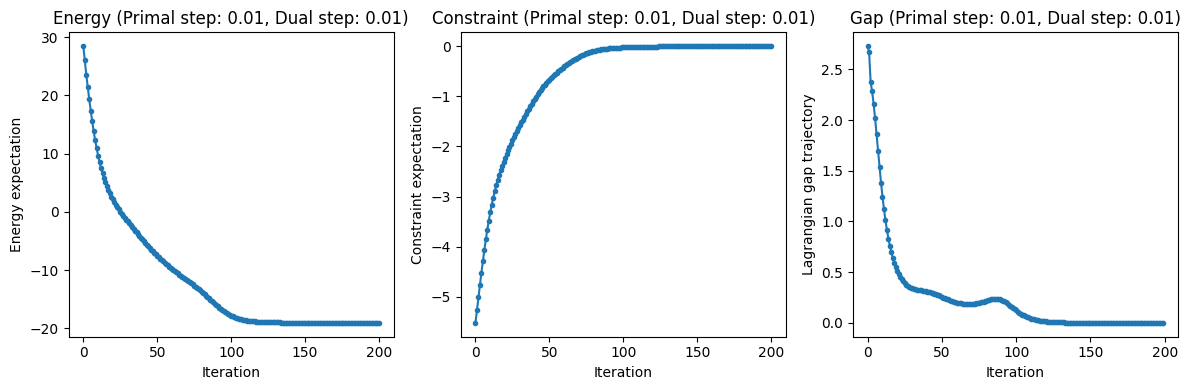

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_5500\3461761279.py:51: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Sample 0: 110110000 with probability 0.5091 and energy -19.05999999999999
Sample 1: 110111111 with probability 0.4903 and energy -19.059999999999988
Sample 2: 110110001 with probability 0.0003 and energy -14.54
Sample 3: 011011001 with probability 0.0001 and energy 58.510000000000005
Sample 4: 110111110 with probability 0.0001 and energy -14.54
Testing primal_perturb_step=0.01, dual_perturb_step=0.12


100%|██████████| 200/200 [04:35<00:00,  1.38s/it]


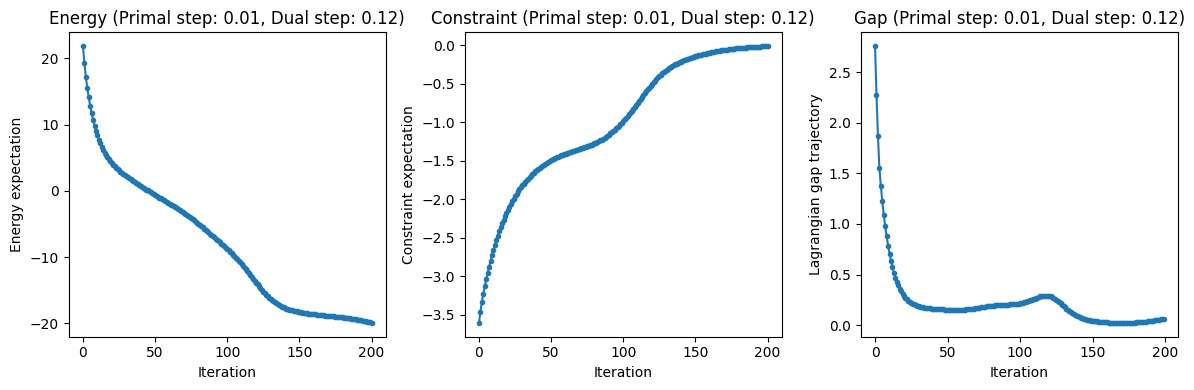

Sample 0: 101000110 with probability 0.8554 and energy -19.150000000000006
Sample 1: 111000110 with probability 0.1249 and energy -26.430000000000014
Sample 2: 101100110 with probability 0.0056 and energy -14.63
Sample 3: 101011010 with probability 0.0037 and energy -14.629999999999994
Sample 4: 101010010 with probability 0.0021 and energy -4.629999999999994
Testing primal_perturb_step=0.01, dual_perturb_step=0.23


100%|██████████| 200/200 [03:51<00:00,  1.16s/it]


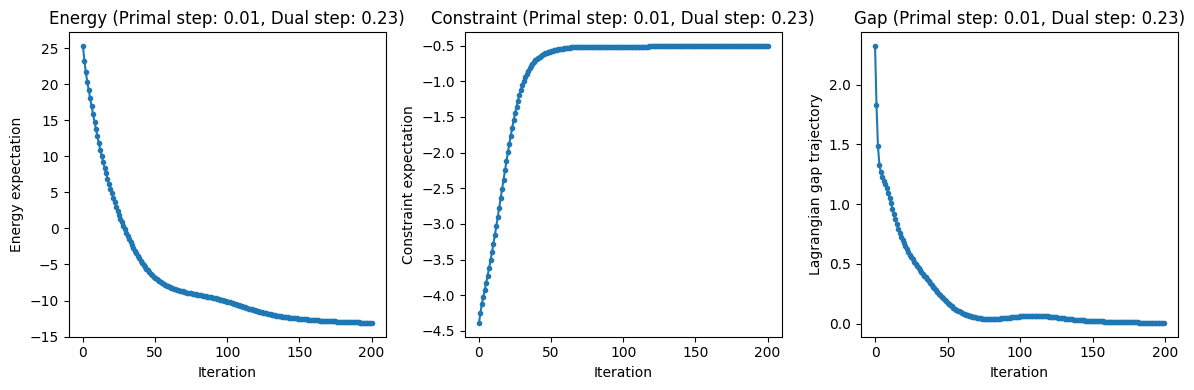

Sample 0: 110000110 with probability 0.1627 and energy -19.060000000000016
Sample 1: 101011110 with probability 0.1567 and energy -4.629999999999998
Sample 2: 101100110 with probability 0.1557 and energy -14.63
Sample 3: 110111110 with probability 0.1488 and energy -14.54
Sample 4: 111111110 with probability 0.0814 and energy -21.90999999999999
Found '111111110' with energy -21.9 and probability 0.0814
Testing primal_perturb_step=0.01, dual_perturb_step=0.34


100%|██████████| 200/200 [03:37<00:00,  1.09s/it]


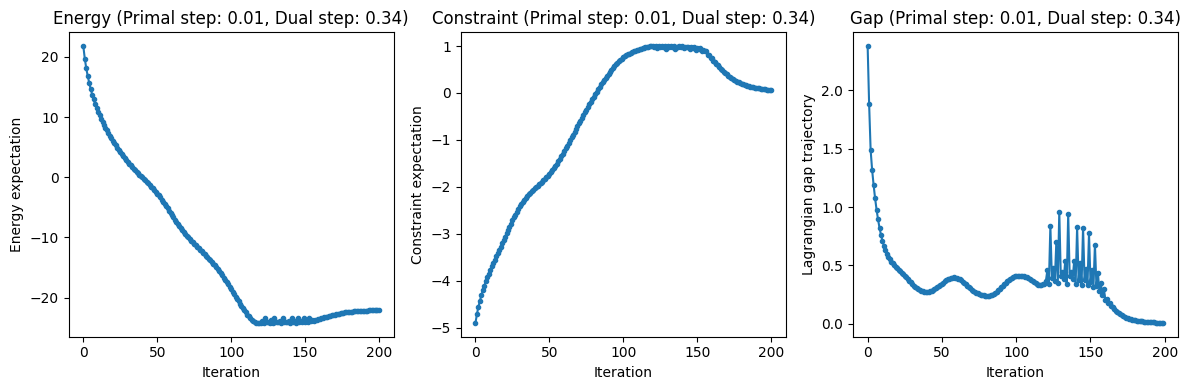

Sample 0: 111011010 with probability 0.5007 and energy -36.46999999999999
Sample 1: 111100110 with probability 0.4699 and energy -7.350000000000003
Sample 2: 111100010 with probability 0.0294 and energy -11.909999999999998
Testing primal_perturb_step=0.01, dual_perturb_step=0.45


100%|██████████| 200/200 [03:58<00:00,  1.19s/it]


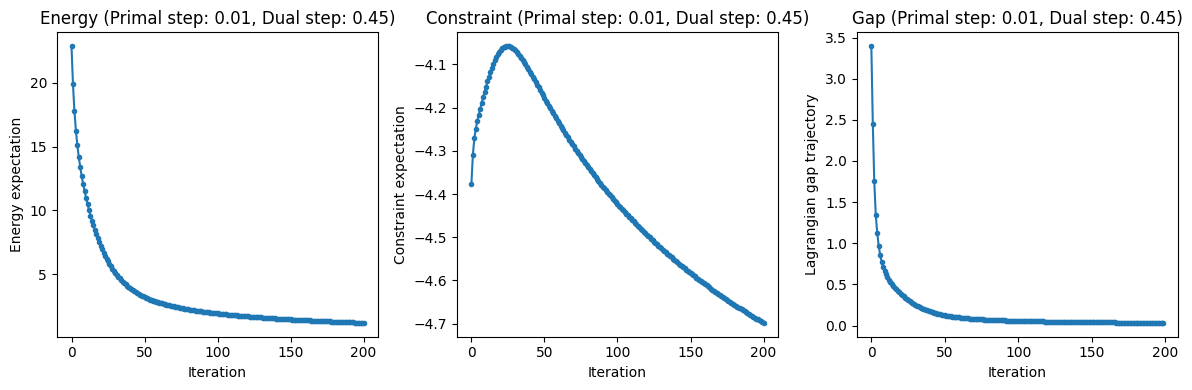

Sample 0: 000111000 with probability 0.1391 and energy 8.881784197001252e-16
Sample 1: 000111110 with probability 0.1177 and energy 7.105427357601002e-15
Sample 2: 000001111 with probability 0.0565 and energy 0.0
Sample 3: 000000101 with probability 0.0563 and energy -3.552713678800501e-15
Sample 4: 000000001 with probability 0.0386 and energy 0.0
Testing primal_perturb_step=0.01, dual_perturb_step=0.56


100%|██████████| 200/200 [03:46<00:00,  1.13s/it]


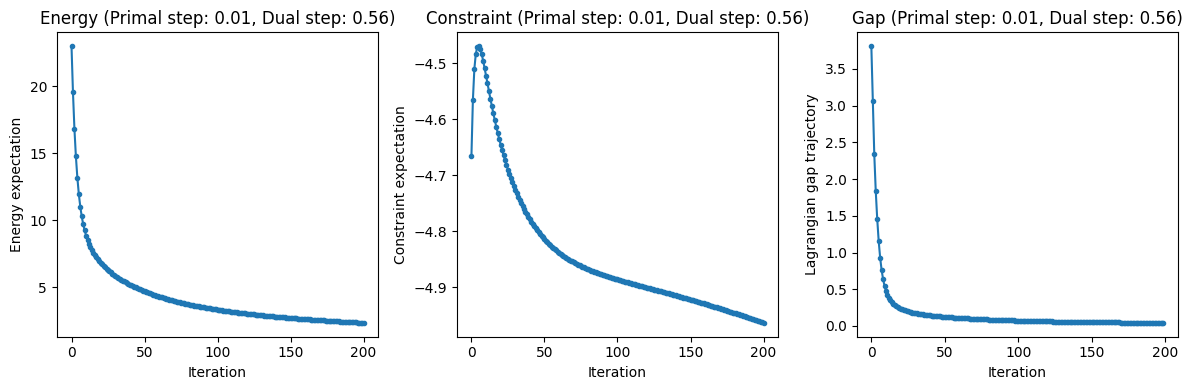

Sample 0: 000000111 with probability 0.2129 and energy 1.7763568394002505e-15
Sample 1: 000001111 with probability 0.1446 and energy 0.0
Sample 2: 000001101 with probability 0.0628 and energy -5.329070518200751e-15
Sample 3: 000000011 with probability 0.0562 and energy -7.105427357601002e-15
Sample 4: 000001000 with probability 0.0524 and energy -1.7763568394002505e-15
Testing primal_perturb_step=0.01, dual_perturb_step=0.67


100%|██████████| 200/200 [04:16<00:00,  1.28s/it]


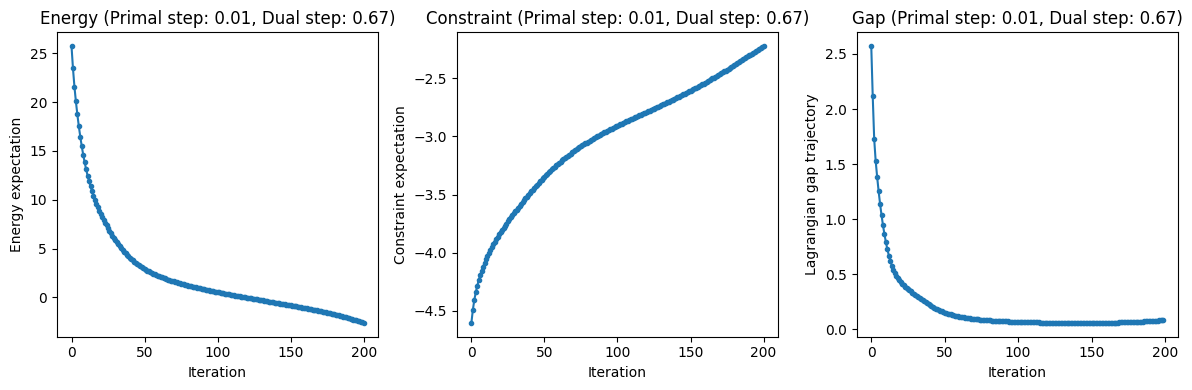

Sample 0: 001000010 with probability 0.1272 and energy -7.370000000000003
Sample 1: 001111110 with probability 0.105 and energy -7.369999999999976
Sample 2: 001101010 with probability 0.086 and energy -7.3700000000000045
Sample 3: 000000010 with probability 0.0601 and energy -5.329070518200751e-15
Sample 4: 000111110 with probability 0.05 and energy 7.105427357601002e-15
Testing primal_perturb_step=0.01, dual_perturb_step=0.78


100%|██████████| 200/200 [03:37<00:00,  1.09s/it]


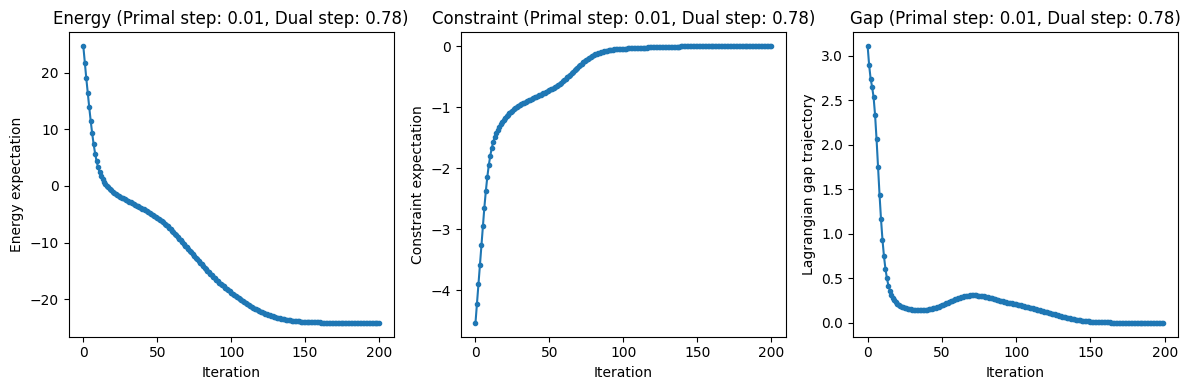

Sample 0: 111000110 with probability 0.5019 and energy -26.430000000000014
Sample 1: 111111110 with probability 0.4978 and energy -21.90999999999999
Found '111111110' with energy -21.9 and probability 0.4978
Testing primal_perturb_step=0.01, dual_perturb_step=0.89


100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


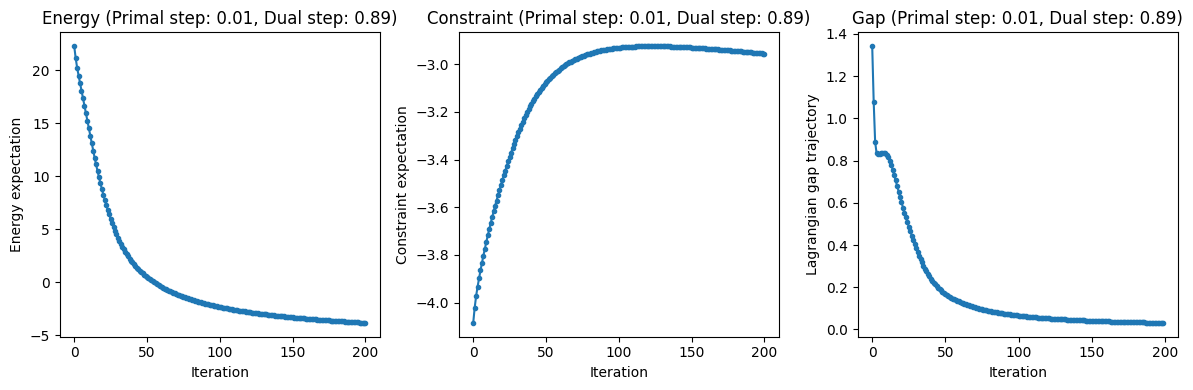

Sample 0: 100001000 with probability 0.187 and energy -7.260000000000002
Sample 1: 100011111 with probability 0.1588 and energy 2.7399999999999967
Sample 2: 100001101 with probability 0.1288 and energy -7.260000000000007
Sample 3: 100011010 with probability 0.0905 and energy -7.2600000000000104
Sample 4: 100010101 with probability 0.0773 and energy -7.2600000000000104
Testing primal_perturb_step=0.01, dual_perturb_step=1.0


100%|██████████| 200/200 [03:59<00:00,  1.20s/it]


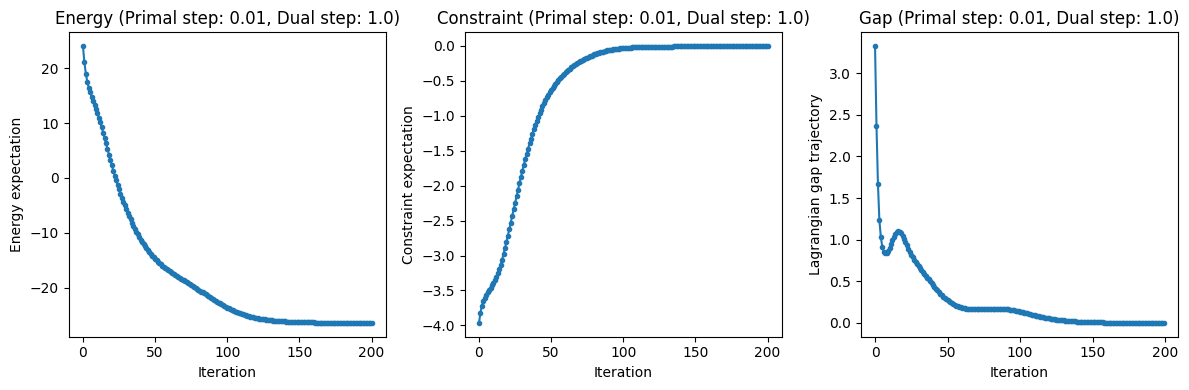

Sample 0: 111000110 with probability 0.9987 and energy -26.430000000000014
Sample 1: 101000110 with probability 0.0005 and energy -19.150000000000006
Sample 2: 111010000 with probability 0.0003 and energy 75.99
Sample 3: 111000010 with probability 0.0001 and energy 7.210000000000004
Sample 4: 111010010 with probability 0.0001 and energy -11.910000000000002
Testing primal_perturb_step=0.12, dual_perturb_step=0.01


 23%|██▎       | 46/200 [00:56<03:08,  1.23s/it]

Gap closed after 47 iterations; VQEC converged.


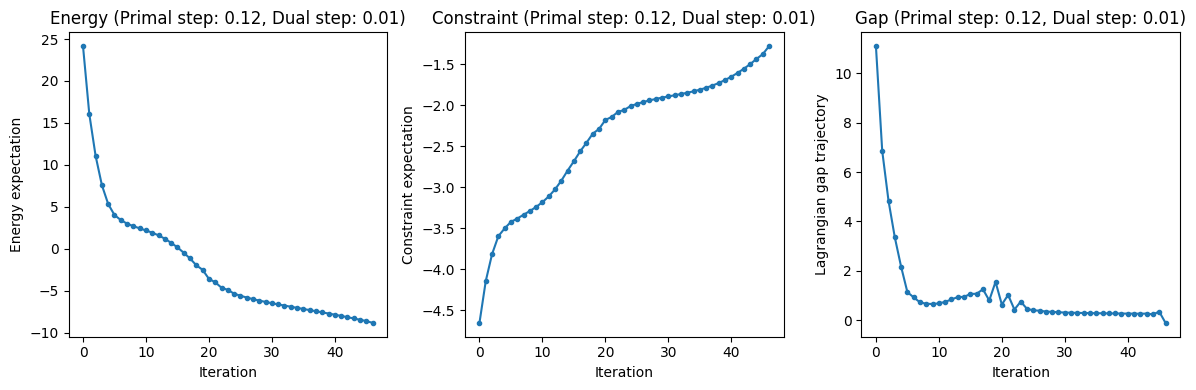

Sample 0: 100100110 with probability 0.2748 and energy -7.259999999999993
Sample 1: 100101001 with probability 0.2319 and energy -7.259999999999991
Sample 2: 100001001 with probability 0.2057 and energy -11.780000000000001
Sample 3: 100000110 with probability 0.1988 and energy -11.780000000000006
Sample 4: 100101000 with probability 0.0239 and energy -7.259999999999996
Testing primal_perturb_step=0.12, dual_perturb_step=0.12


 45%|████▌     | 90/200 [01:50<02:15,  1.23s/it]

Gap closed after 91 iterations; VQEC converged.


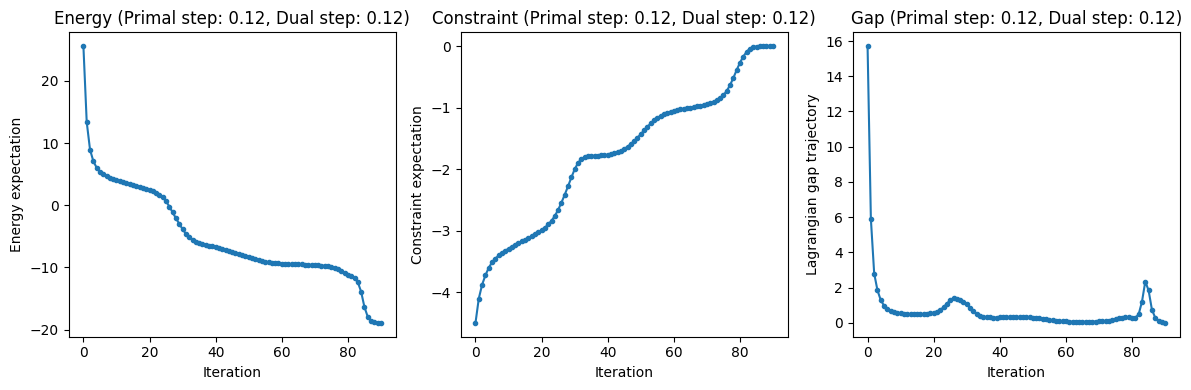

Sample 0: 110111111 with probability 0.2489 and energy -19.059999999999988
Sample 1: 110110000 with probability 0.2482 and energy -19.05999999999999
Sample 2: 110001001 with probability 0.2468 and energy -19.059999999999995
Sample 3: 110000110 with probability 0.2434 and energy -19.060000000000016
Sample 4: 100001001 with probability 0.0025 and energy -11.780000000000001
Testing primal_perturb_step=0.12, dual_perturb_step=0.23


100%|██████████| 200/200 [03:46<00:00,  1.13s/it]


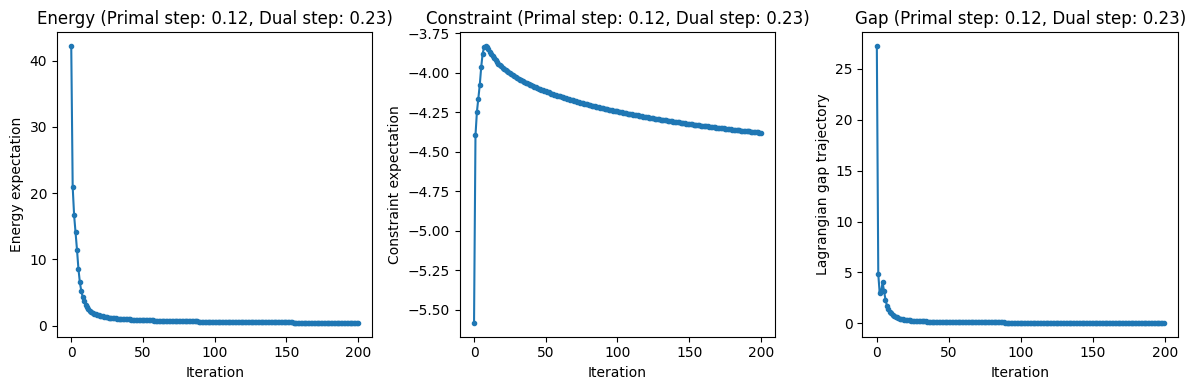

Sample 0: 000001101 with probability 0.2202 and energy -5.329070518200751e-15
Sample 1: 000001011 with probability 0.1507 and energy 0.0
Sample 2: 000001110 with probability 0.0719 and energy 0.0
Sample 3: 000011001 with probability 0.0566 and energy -7.105427357601002e-15
Sample 4: 000000111 with probability 0.0421 and energy 1.7763568394002505e-15
Testing primal_perturb_step=0.12, dual_perturb_step=0.34


  6%|▌         | 11/200 [00:13<03:45,  1.19s/it]

Gap closed after 12 iterations; VQEC converged.


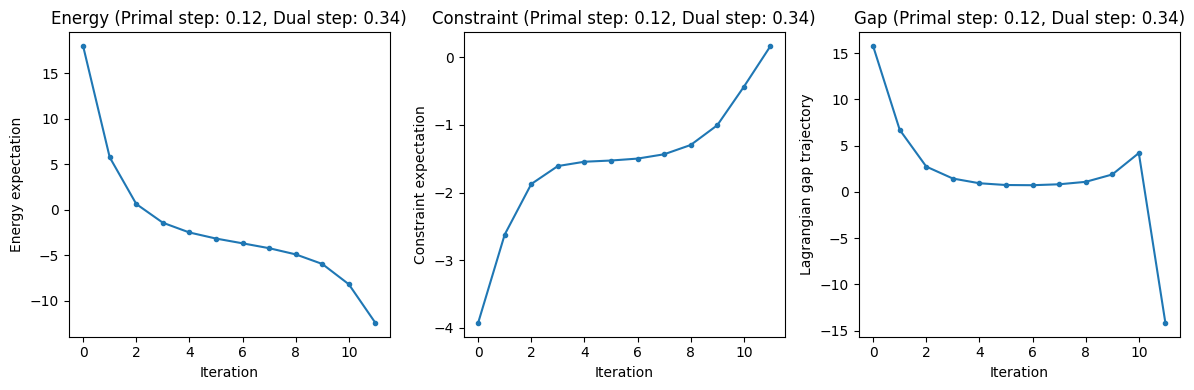

Sample 0: 011110010 with probability 0.3121 and energy -14.65
Sample 1: 011011010 with probability 0.2161 and energy -29.209999999999994
Sample 2: 001110010 with probability 0.0998 and energy -7.369999999999994
Sample 3: 001011010 with probability 0.0866 and energy -7.369999999999997
Sample 4: 011101010 with probability 0.0338 and energy -0.09000000000000075
Testing primal_perturb_step=0.12, dual_perturb_step=0.45


  3%|▎         | 6/200 [00:07<04:13,  1.31s/it]

Converged after 7 iterations


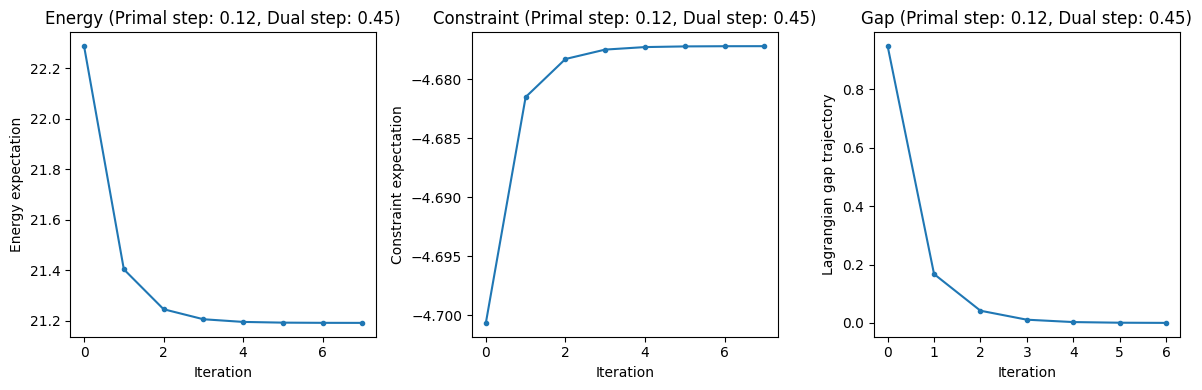

Sample 0: 101010100 with probability 0.0265 and energy 58.62999999999999
Sample 1: 000000010 with probability 0.0243 and energy -5.329070518200751e-15
Sample 2: 000101001 with probability 0.0232 and energy 1.0658141036401503e-14
Sample 3: 100000010 with probability 0.0219 and energy -7.260000000000005
Sample 4: 101111111 with probability 0.017 and energy -4.410000000000002
Testing primal_perturb_step=0.12, dual_perturb_step=0.56


100%|██████████| 200/200 [03:46<00:00,  1.13s/it]


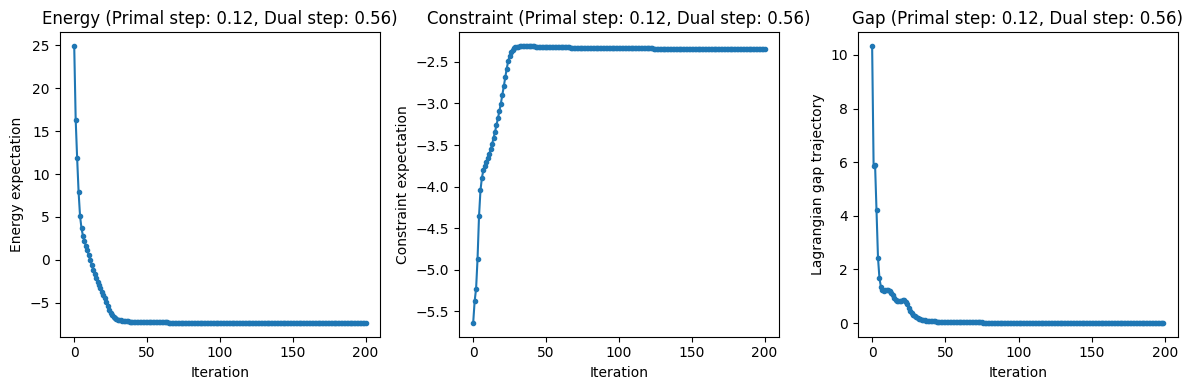

Sample 0: 001000010 with probability 0.2315 and energy -7.370000000000003
Sample 1: 001001110 with probability 0.1905 and energy -7.36999999999999
Sample 2: 001011010 with probability 0.1351 and energy -7.369999999999997
Sample 3: 001110010 with probability 0.1029 and energy -7.369999999999994
Sample 4: 001010110 with probability 0.0972 and energy -7.370000000000006
Testing primal_perturb_step=0.12, dual_perturb_step=0.67


  4%|▍         | 8/200 [00:09<03:56,  1.23s/it]

Gap closed after 9 iterations; VQEC converged.


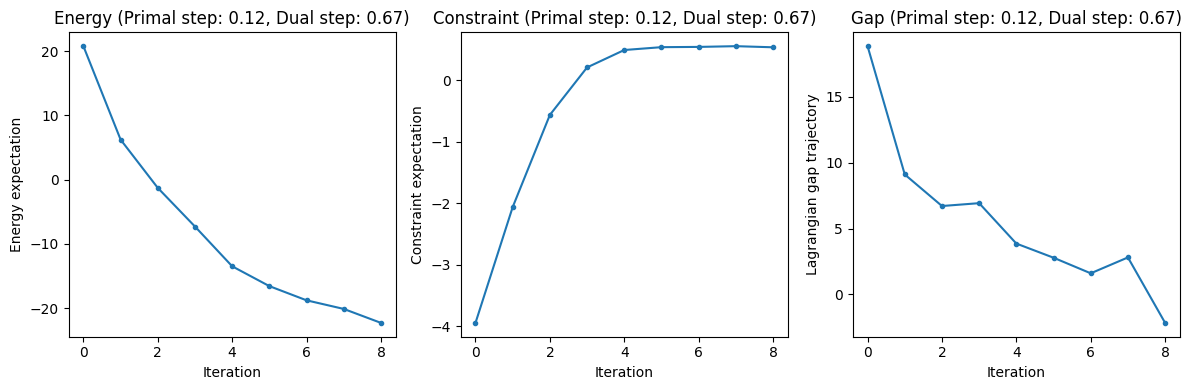

Sample 0: 111011010 with probability 0.306 and energy -36.46999999999999
Sample 1: 111111110 with probability 0.1824 and energy -21.90999999999999
Found '111111110' with energy -21.9 and probability 0.1824
Testing primal_perturb_step=0.12, dual_perturb_step=0.78


  4%|▎         | 7/200 [00:08<04:04,  1.27s/it]

Gap closed after 8 iterations; VQEC converged.


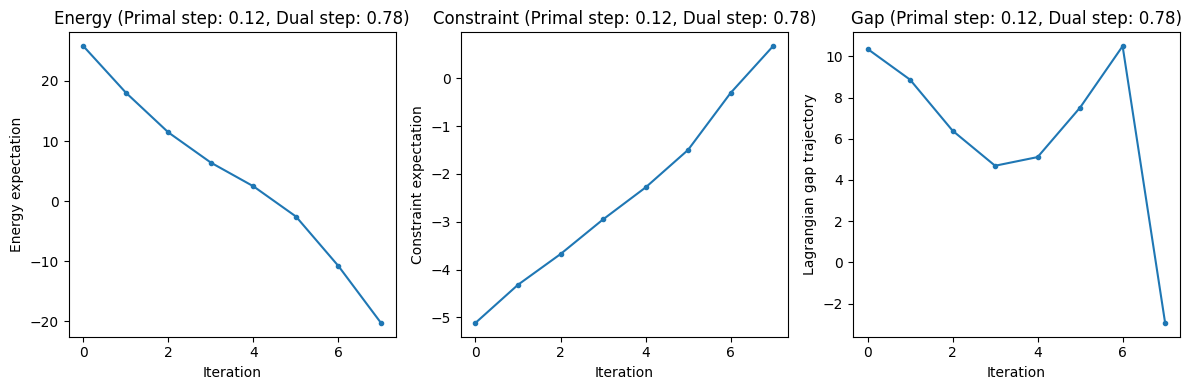

Sample 0: 110011010 with probability 0.3972 and energy -29.100000000000012
Sample 1: 111011010 with probability 0.0845 and energy -36.46999999999999
Sample 2: 010011010 with probability 0.0634 and energy -21.840000000000014
Sample 3: 110111110 with probability 0.0471 and energy -14.54
Sample 4: 101111110 with probability 0.0434 and energy -14.62999999999998
Testing primal_perturb_step=0.12, dual_perturb_step=0.89


  8%|▊         | 16/200 [00:19<03:39,  1.19s/it]

Gap closed after 17 iterations; VQEC converged.


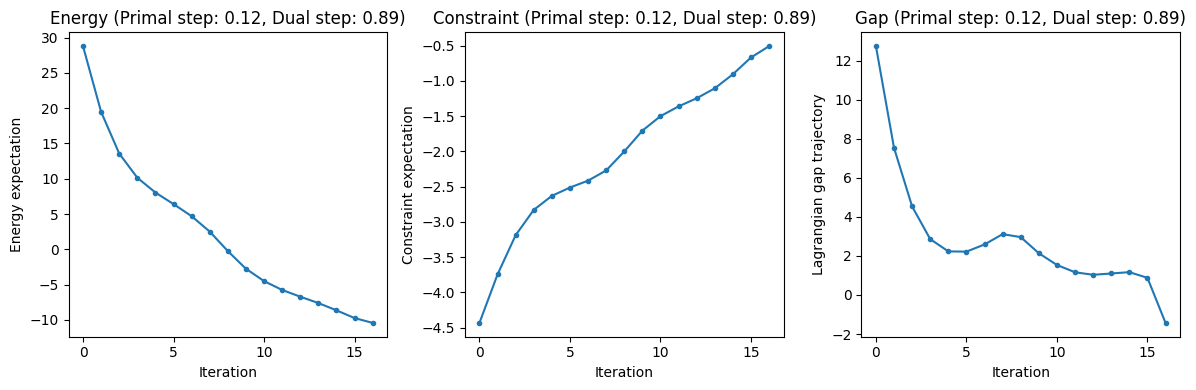

Sample 0: 100000110 with probability 0.3427 and energy -11.780000000000006
Sample 1: 100001001 with probability 0.3128 and energy -11.780000000000001
Sample 2: 100100110 with probability 0.1037 and energy -7.259999999999993
Sample 3: 100101001 with probability 0.0956 and energy -7.259999999999991
Sample 4: 110000110 with probability 0.0313 and energy -19.060000000000016
Testing primal_perturb_step=0.12, dual_perturb_step=1.0


  4%|▎         | 7/200 [00:09<04:26,  1.38s/it]

Gap closed after 8 iterations; VQEC converged.


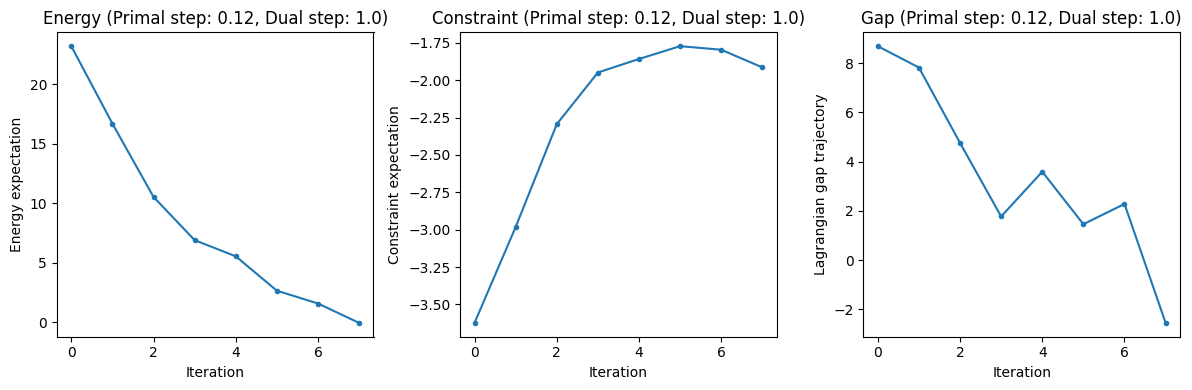

Sample 0: 000101000 with probability 0.0994 and energy 6.661338147750939e-15
Sample 1: 110011011 with probability 0.0622 and energy -14.540000000000004
Sample 2: 110011010 with probability 0.061 and energy -29.100000000000012
Sample 3: 000000000 with probability 0.0428 and energy 0.0
Sample 4: 000101001 with probability 0.0321 and energy 1.0658141036401503e-14
Testing primal_perturb_step=0.23, dual_perturb_step=0.01


  9%|▉         | 18/200 [00:23<03:58,  1.31s/it]

Converged after 19 iterations


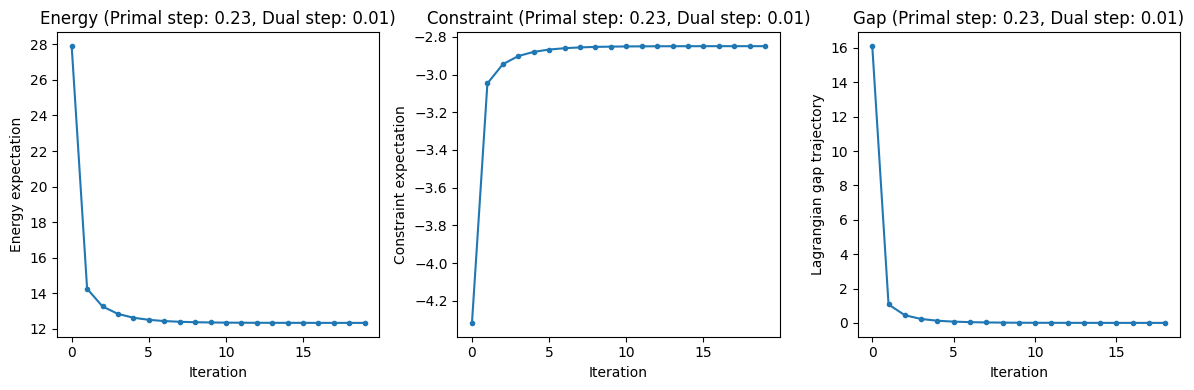

Sample 0: 101101111 with probability 0.032 and energy 10.10999999999999
Sample 1: 110011110 with probability 0.0222 and energy -4.539999999999999
Sample 2: 010011110 with probability 0.0166 and energy 2.7199999999999998
Sample 3: 100101111 with probability 0.0154 and energy 2.739999999999997
Sample 4: 111011110 with probability 0.0154 and energy -11.909999999999998
Testing primal_perturb_step=0.23, dual_perturb_step=0.12


  4%|▍         | 8/200 [00:11<04:40,  1.46s/it]

Gap closed after 9 iterations; VQEC converged.


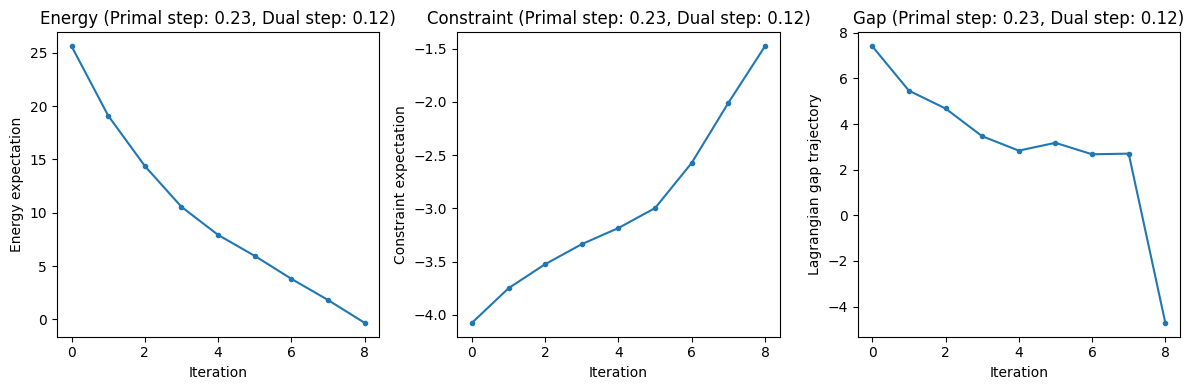

Sample 0: 011111110 with probability 0.0796 and energy -14.649999999999986
Sample 1: 001111110 with probability 0.0698 and energy -7.369999999999976
Sample 2: 000111110 with probability 0.0588 and energy 7.105427357601002e-15
Sample 3: 011110010 with probability 0.0436 and energy -14.65
Sample 4: 001110010 with probability 0.033 and energy -7.369999999999994
Testing primal_perturb_step=0.23, dual_perturb_step=0.23


 10%|█         | 20/200 [00:24<03:38,  1.21s/it]

Gap closed after 21 iterations; VQEC converged.


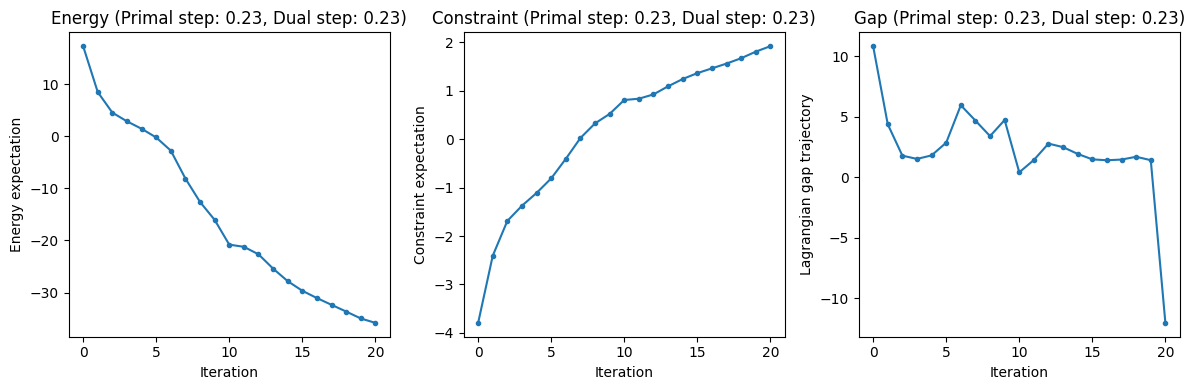

Sample 0: 111011010 with probability 0.9424 and energy -36.46999999999999
Sample 1: 111000110 with probability 0.0318 and energy -26.430000000000014
Sample 2: 011011010 with probability 0.0176 and energy -29.209999999999994
Sample 3: 111010010 with probability 0.0033 and energy -11.910000000000002
Sample 4: 110011010 with probability 0.0016 and energy -29.100000000000012
Testing primal_perturb_step=0.23, dual_perturb_step=0.34


  3%|▎         | 6/200 [00:08<04:19,  1.34s/it]

Gap closed after 7 iterations; VQEC converged.


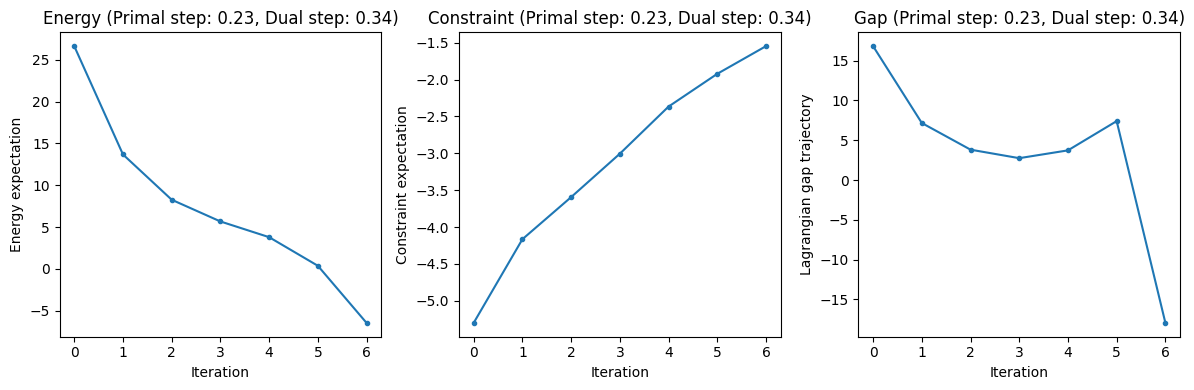

Sample 0: 101100110 with probability 0.2645 and energy -14.63
Sample 1: 101111110 with probability 0.1277 and energy -14.62999999999998
Sample 2: 001100110 with probability 0.1163 and energy -7.370000000000003
Sample 3: 001111110 with probability 0.0523 and energy -7.369999999999976
Sample 4: 100000110 with probability 0.0344 and energy -11.780000000000006
Testing primal_perturb_step=0.23, dual_perturb_step=0.45


  4%|▍         | 9/200 [00:11<04:10,  1.31s/it]

Gap closed after 10 iterations; VQEC converged.


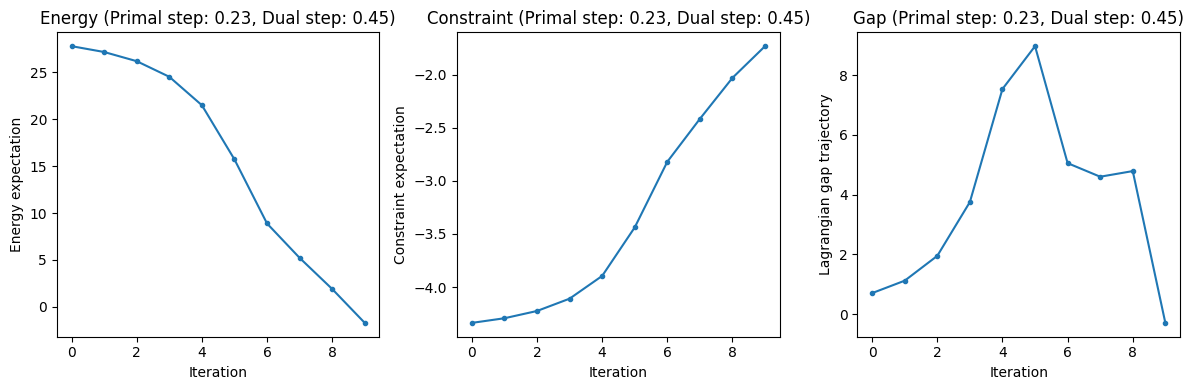

Sample 0: 100100110 with probability 0.1652 and energy -7.259999999999993
Sample 1: 100101001 with probability 0.1195 and energy -7.259999999999991
Sample 2: 110110001 with probability 0.0699 and energy -14.54
Sample 3: 110111110 with probability 0.0628 and energy -14.54
Sample 4: 100010001 with probability 0.0344 and energy 2.7400000000000038
Testing primal_perturb_step=0.23, dual_perturb_step=0.56


  8%|▊         | 15/200 [00:17<03:41,  1.20s/it]

Gap closed after 16 iterations; VQEC converged.


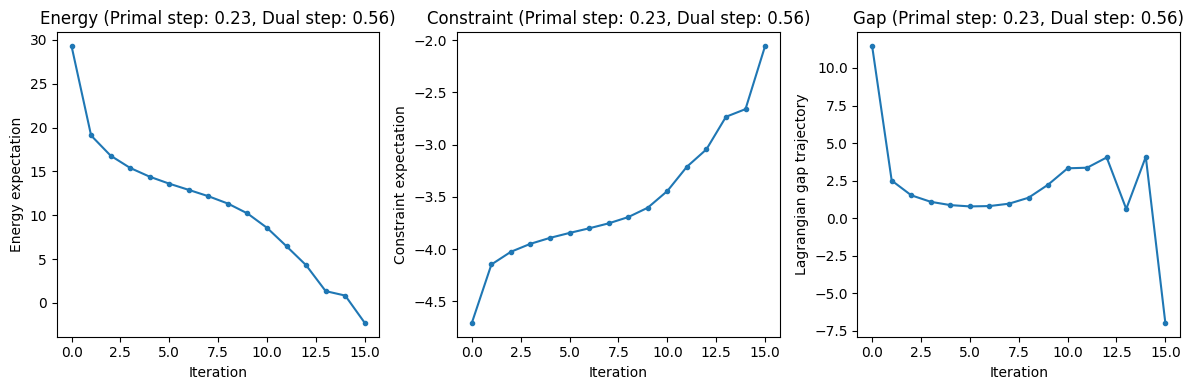

Sample 0: 101010010 with probability 0.0983 and energy -4.629999999999994
Sample 1: 101011110 with probability 0.0978 and energy -4.629999999999998
Sample 2: 101000110 with probability 0.0962 and energy -19.150000000000006
Sample 3: 101011010 with probability 0.0568 and energy -14.629999999999994
Sample 4: 000101101 with probability 0.0419 and energy 9.999999999999996
Testing primal_perturb_step=0.23, dual_perturb_step=0.67


  6%|▌         | 11/200 [00:13<03:55,  1.25s/it]

Gap closed after 12 iterations; VQEC converged.


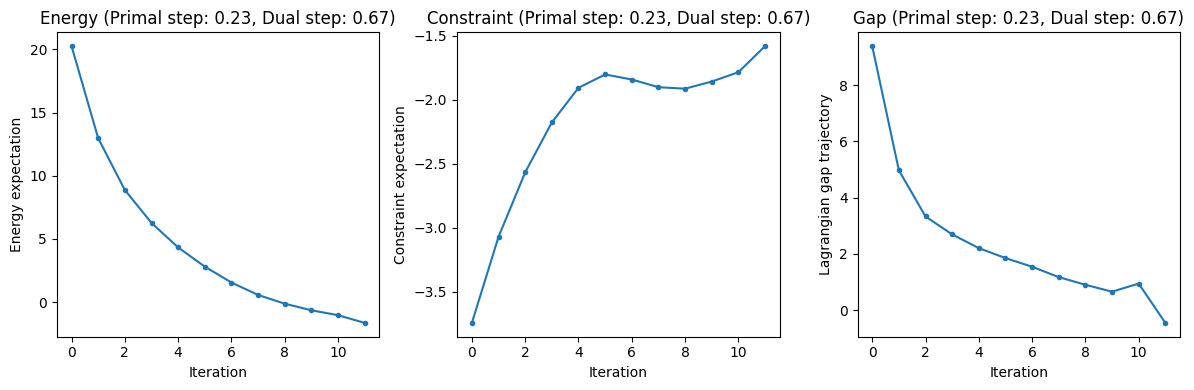

Sample 0: 010101011 with probability 0.1276 and energy -7.279999999999999
Sample 1: 010110010 with probability 0.0767 and energy -7.280000000000014
Sample 2: 010111110 with probability 0.059 and energy -7.279999999999996
Sample 3: 000010111 with probability 0.0568 and energy -7.105427357601002e-15
Sample 4: 010111111 with probability 0.0536 and energy 2.720000000000006
Testing primal_perturb_step=0.23, dual_perturb_step=0.78


  4%|▍         | 8/200 [00:10<04:01,  1.26s/it]

Gap closed after 9 iterations; VQEC converged.


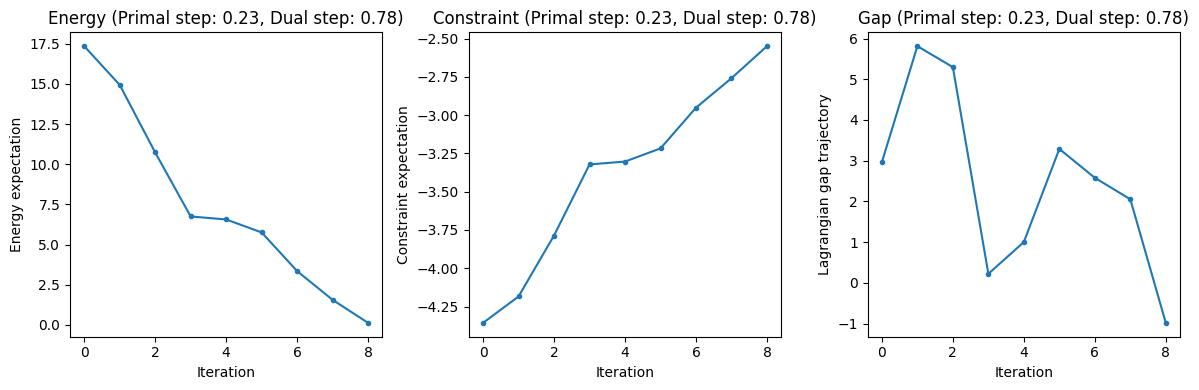

Sample 0: 100001001 with probability 0.1272 and energy -11.780000000000001
Sample 1: 100101001 with probability 0.1202 and energy -7.259999999999991
Sample 2: 100000110 with probability 0.0548 and energy -11.780000000000006
Sample 3: 100111110 with probability 0.046 and energy -7.259999999999996
Sample 4: 100000010 with probability 0.041 and energy -7.260000000000005
Testing primal_perturb_step=0.23, dual_perturb_step=0.89


  3%|▎         | 6/200 [00:08<04:19,  1.34s/it]

Converged after 7 iterations


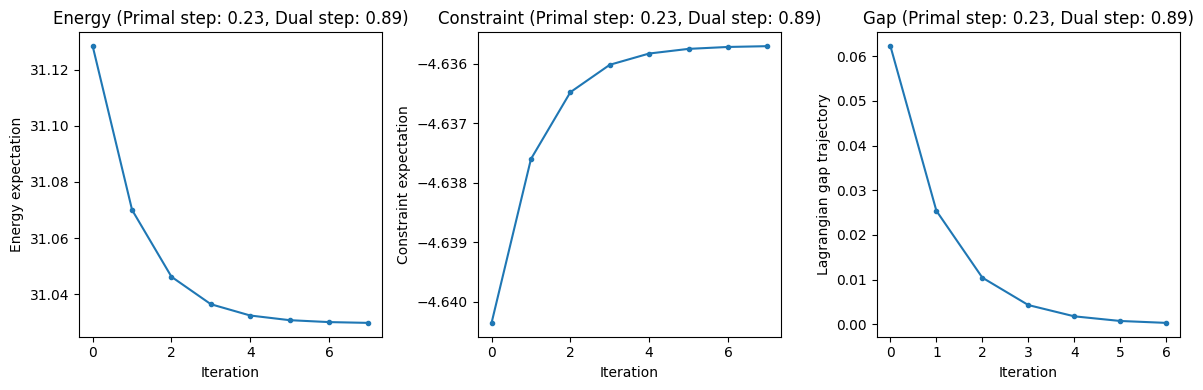

Sample 0: 001111001 with probability 0.0647 and energy 22.11
Sample 1: 001001001 with probability 0.0351 and energy 32.11
Sample 2: 111001001 with probability 0.0349 and energy 3.0500000000000043
Sample 3: 111111001 with probability 0.0296 and energy 51.21
Sample 4: 101111001 with probability 0.0222 and energy 29.369999999999997
Testing primal_perturb_step=0.23, dual_perturb_step=1.0


  3%|▎         | 6/200 [00:07<04:11,  1.30s/it]

Gap closed after 7 iterations; VQEC converged.


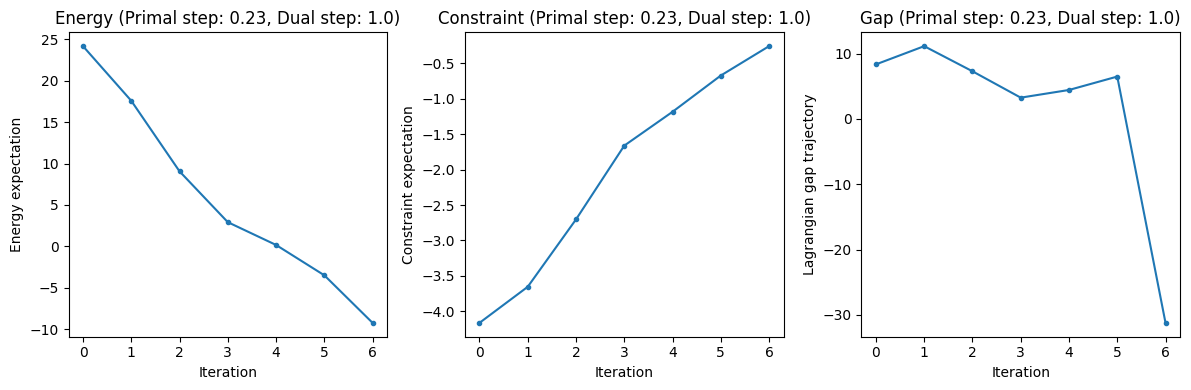

Sample 0: 111000110 with probability 0.1076 and energy -26.430000000000014
Sample 1: 101000110 with probability 0.1017 and energy -19.150000000000006
Sample 2: 111101110 with probability 0.0802 and energy -11.909999999999998
Sample 3: 100000110 with probability 0.0465 and energy -11.780000000000006
Sample 4: 111010010 with probability 0.0459 and energy -11.910000000000002
Testing primal_perturb_step=0.34, dual_perturb_step=0.01


  2%|▏         | 3/200 [00:04<05:03,  1.54s/it]

Gap closed after 4 iterations; VQEC converged.


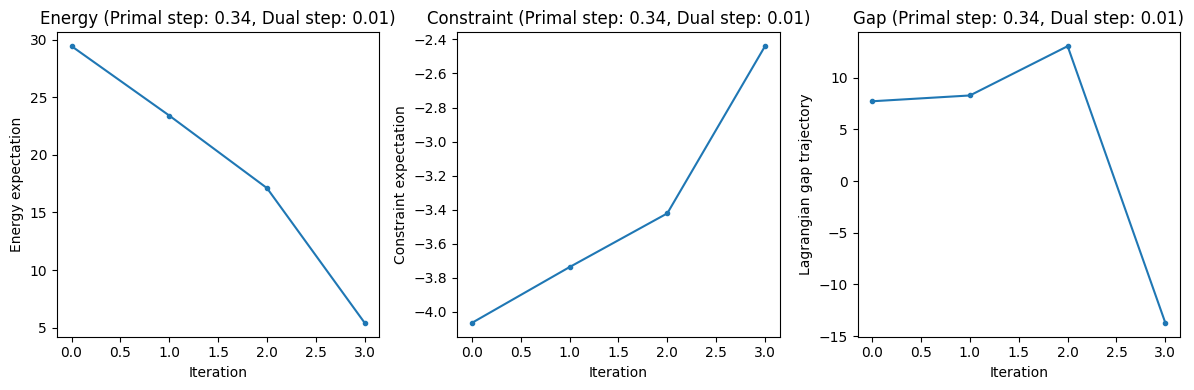

Sample 0: 101000010 with probability 0.1013 and energy -14.630000000000003
Sample 1: 101000110 with probability 0.0641 and energy -19.150000000000006
Sample 2: 100111010 with probability 0.0285 and energy 7.259999999999991
Sample 3: 100110001 with probability 0.0184 and energy -7.259999999999998
Sample 4: 110110001 with probability 0.017 and energy -14.54
Testing primal_perturb_step=0.34, dual_perturb_step=0.12


  0%|          | 1/200 [00:02<07:04,  2.13s/it]

Gap closed after 2 iterations; VQEC converged.


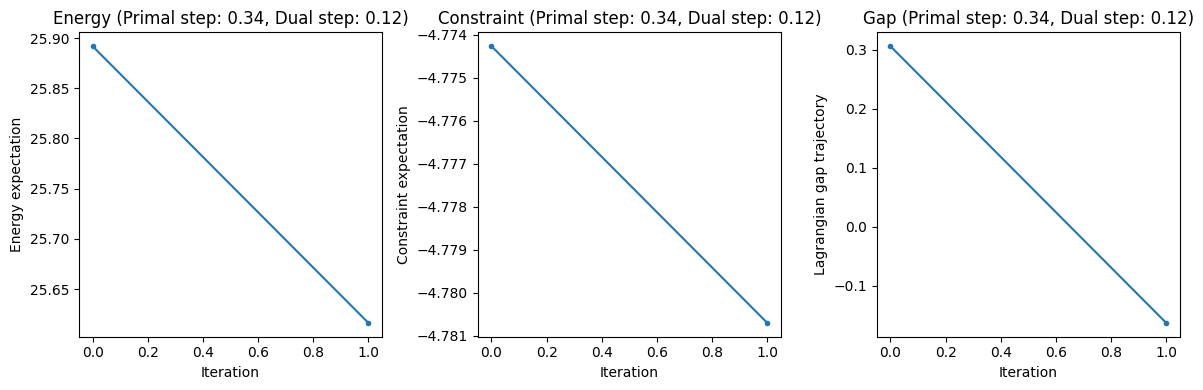

Sample 0: 100000101 with probability 0.0204 and energy 36.29999999999999
Sample 1: 110101101 with probability 0.0162 and energy 24.580000000000005
Sample 2: 100000010 with probability 0.0155 and energy -7.260000000000005
Sample 3: 110101100 with probability 0.0153 and energy 39.14000000000001
Sample 4: 100001100 with probability 0.0136 and energy 7.2599999999999945
Testing primal_perturb_step=0.34, dual_perturb_step=0.23


  1%|          | 2/200 [00:03<05:39,  1.71s/it]

Gap closed after 3 iterations; VQEC converged.


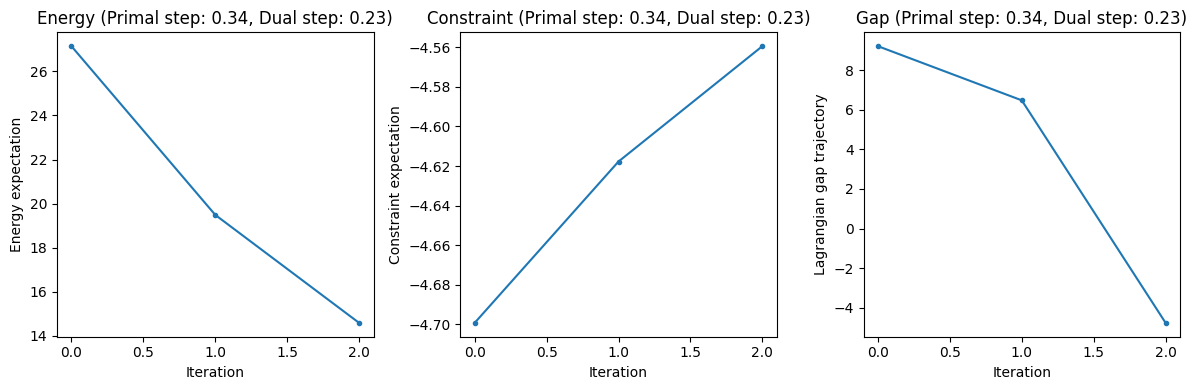

Sample 0: 000000011 with probability 0.0255 and energy -7.105427357601002e-15
Sample 1: 000001110 with probability 0.0233 and energy 0.0
Sample 2: 000000101 with probability 0.0185 and energy -3.552713678800501e-15
Sample 3: 101110011 with probability 0.0154 and energy 14.629999999999999
Sample 4: 000100011 with probability 0.015 and energy 10.000000000000009
Testing primal_perturb_step=0.34, dual_perturb_step=0.34


  2%|▏         | 4/200 [00:05<04:49,  1.48s/it]

Converged after 5 iterations


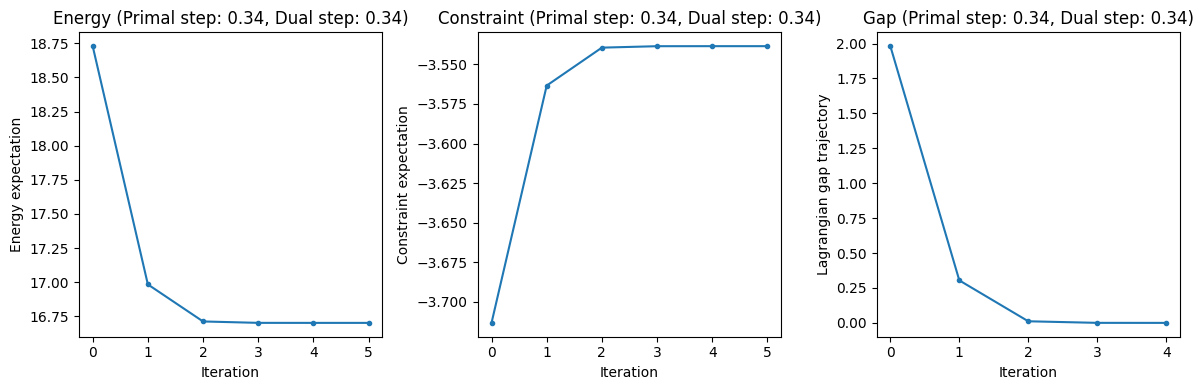

Sample 0: 001000110 with probability 0.0213 and energy 2.6300000000000026
Sample 1: 001110110 with probability 0.0183 and energy -7.370000000000001
Sample 2: 100000110 with probability 0.0166 and energy -11.780000000000006
Sample 3: 001110010 with probability 0.0155 and energy -7.369999999999994
Sample 4: 000000110 with probability 0.0143 and energy 10.0
Testing primal_perturb_step=0.34, dual_perturb_step=0.45


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


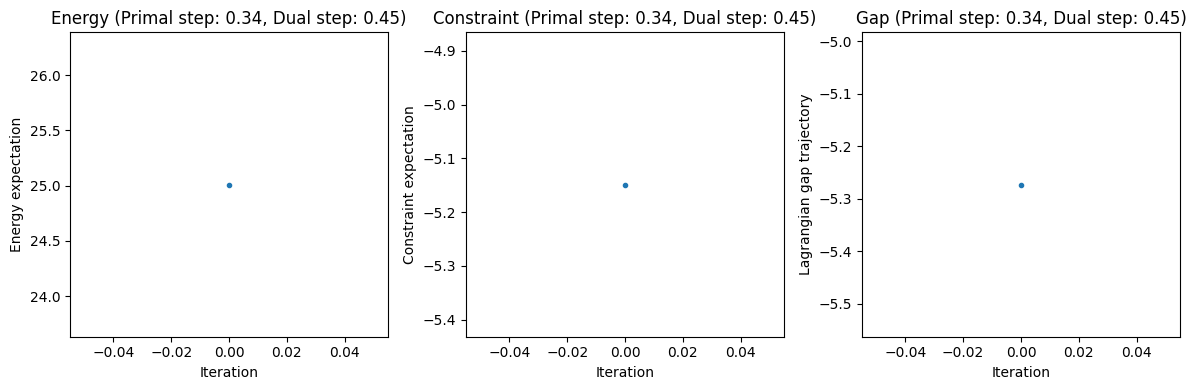

Sample 0: 100001111 with probability 0.0329 and energy 36.29999999999999
Sample 1: 101001111 with probability 0.0295 and energy 43.67000000000001
Sample 2: 100111111 with probability 0.0249 and energy -11.779999999999992
Sample 3: 100101001 with probability 0.0218 and energy -7.259999999999991
Sample 4: 111100101 with probability 0.0213 and energy 109.41
Testing primal_perturb_step=0.34, dual_perturb_step=0.56


  0%|          | 1/200 [00:02<07:33,  2.28s/it]

Gap closed after 2 iterations; VQEC converged.


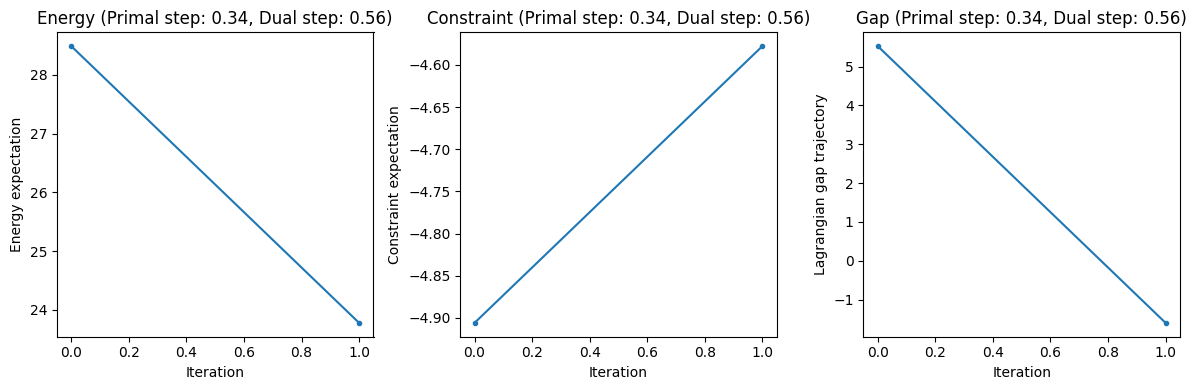

Sample 0: 000101001 with probability 0.0197 and energy 1.0658141036401503e-14
Sample 1: 110001100 with probability 0.0197 and energy 58.21999999999999
Sample 2: 100000110 with probability 0.0186 and energy -11.780000000000006
Sample 3: 100101001 with probability 0.0182 and energy -7.259999999999991
Sample 4: 110011100 with probability 0.0147 and energy 39.13999999999999
Testing primal_perturb_step=0.34, dual_perturb_step=0.67


  6%|▌         | 11/200 [00:13<03:59,  1.27s/it]

Gap closed after 12 iterations; VQEC converged.


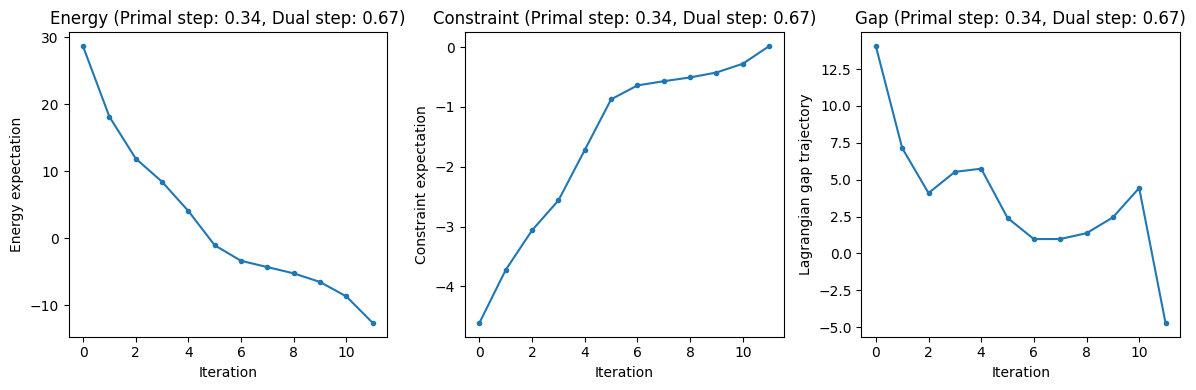

Sample 0: 100000110 with probability 0.1932 and energy -11.780000000000006
Sample 1: 101100110 with probability 0.1206 and energy -14.63
Sample 2: 101011010 with probability 0.0949 and energy -14.629999999999994
Sample 3: 101000110 with probability 0.0794 and energy -19.150000000000006
Sample 4: 101111010 with probability 0.0621 and energy -0.10999999999999943
Testing primal_perturb_step=0.34, dual_perturb_step=0.78


  6%|▌         | 11/200 [00:13<03:53,  1.24s/it]

Converged after 12 iterations


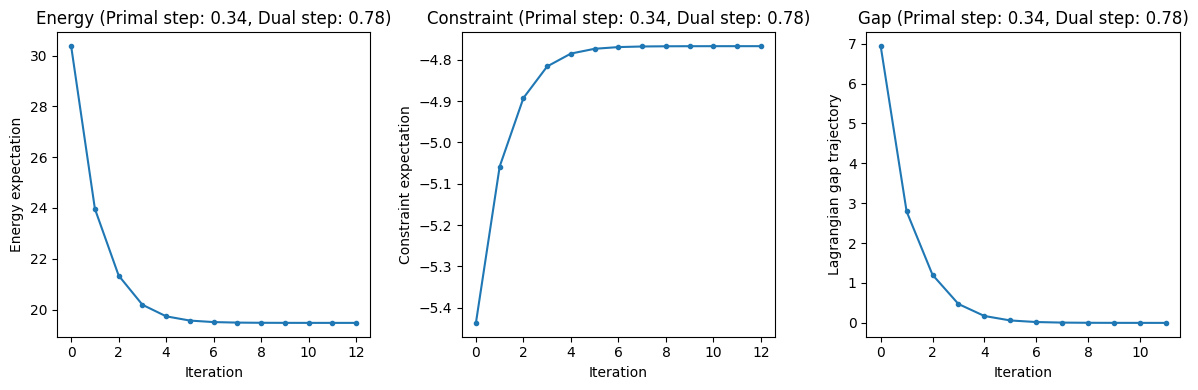

Sample 0: 001010100 with probability 0.021 and energy 36.849999999999994
Sample 1: 000100001 with probability 0.0208 and energy 10.000000000000002
Sample 2: 100100001 with probability 0.0198 and energy 2.740000000000002
Sample 3: 101110001 with probability 0.0179 and energy 14.850000000000005
Sample 4: 100110100 with probability 0.0178 and energy 21.779999999999994
Testing primal_perturb_step=0.34, dual_perturb_step=0.89


  2%|▏         | 4/200 [00:05<04:45,  1.45s/it]

Gap closed after 5 iterations; VQEC converged.


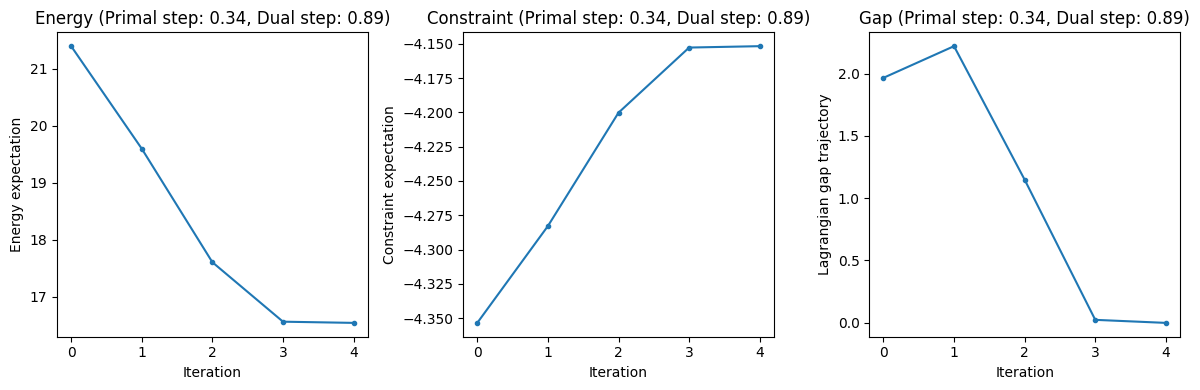

Sample 0: 000111001 with probability 0.0309 and energy 0.0
Sample 1: 001111001 with probability 0.0181 and energy 22.11
Sample 2: 100111001 with probability 0.0144 and energy 7.259999999999998
Sample 3: 010011001 with probability 0.014 and energy 36.400000000000006
Sample 4: 000111110 with probability 0.0124 and energy 7.105427357601002e-15
Testing primal_perturb_step=0.34, dual_perturb_step=1.0


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


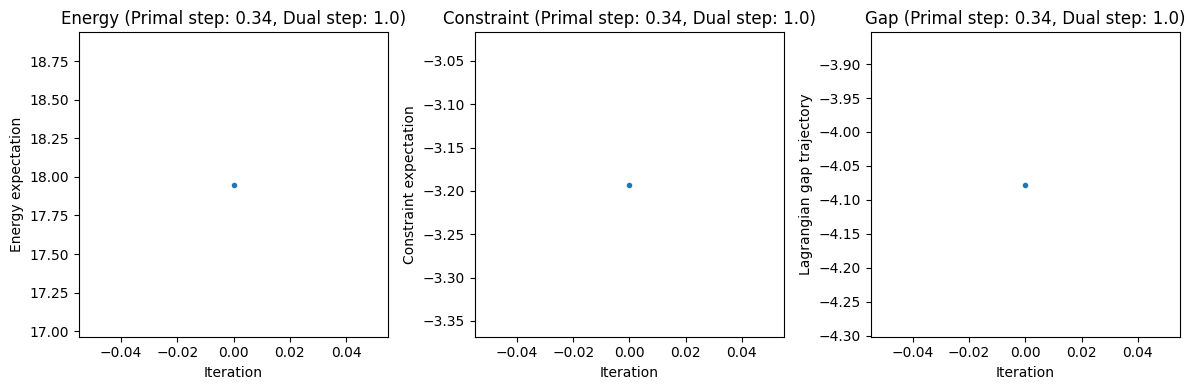

Sample 0: 001110110 with probability 0.0259 and energy -7.370000000000001
Sample 1: 001011110 with probability 0.0255 and energy 2.630000000000001
Sample 2: 010111110 with probability 0.0187 and energy -7.279999999999996
Sample 3: 010110110 with probability 0.0162 and energy 21.839999999999996
Sample 4: 110110110 with probability 0.0149 and energy 29.099999999999994
Testing primal_perturb_step=0.45, dual_perturb_step=0.01


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


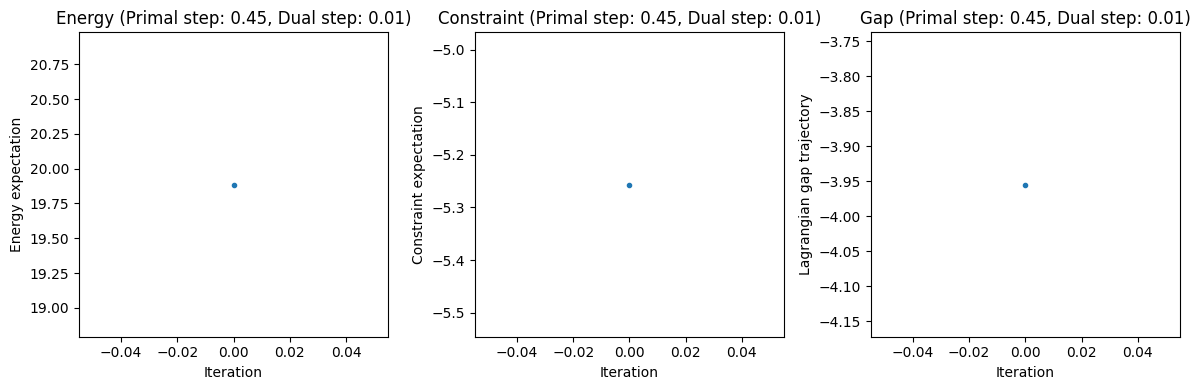

Sample 0: 101001011 with probability 0.048 and energy 29.14999999999999
Sample 1: 101001100 with probability 0.0359 and energy 44.11
Sample 2: 100110100 with probability 0.029 and energy 21.779999999999994
Sample 3: 101000011 with probability 0.0256 and energy 14.630000000000008
Sample 4: 101001110 with probability 0.0251 and energy 14.410000000000009
Testing primal_perturb_step=0.45, dual_perturb_step=0.12


  2%|▎         | 5/200 [00:06<04:27,  1.37s/it]

Gap closed after 6 iterations; VQEC converged.


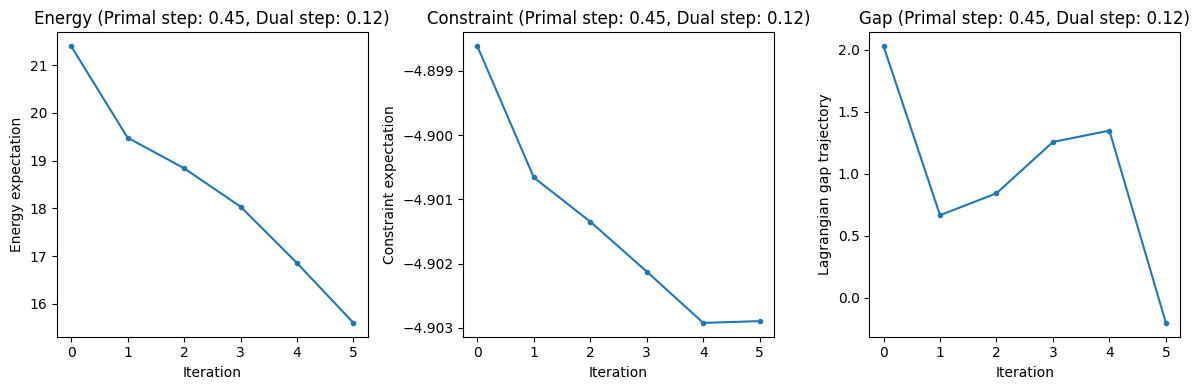

Sample 0: 000100101 with probability 0.0396 and energy -3.552713678800501e-15
Sample 1: 001101101 with probability 0.0232 and energy 32.11
Sample 2: 000100000 with probability 0.0194 and energy 10.000000000000004
Sample 3: 001001010 with probability 0.0182 and energy -7.370000000000001
Sample 4: 000100111 with probability 0.0177 and energy -7.105427357601002e-15
Testing primal_perturb_step=0.45, dual_perturb_step=0.23


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


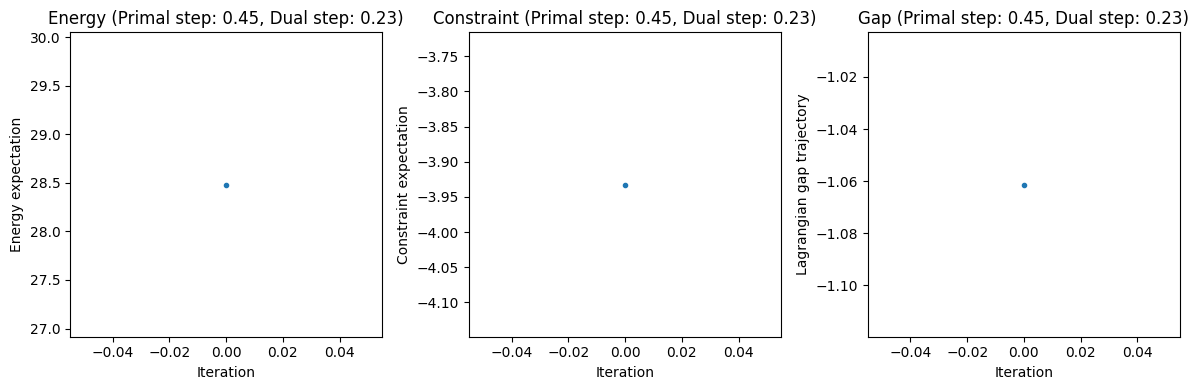

Sample 0: 111011110 with probability 0.0211 and energy -11.909999999999998
Sample 1: 111011010 with probability 0.0199 and energy -36.46999999999999
Sample 2: 111010100 with probability 0.0198 and energy 138.71
Sample 3: 111101000 with probability 0.0189 and energy 51.43000000000001
Sample 4: 111011101 with probability 0.0164 and energy 46.690000000000005
Testing primal_perturb_step=0.45, dual_perturb_step=0.34


  2%|▏         | 4/200 [00:05<04:41,  1.44s/it]

Gap closed after 5 iterations; VQEC converged.


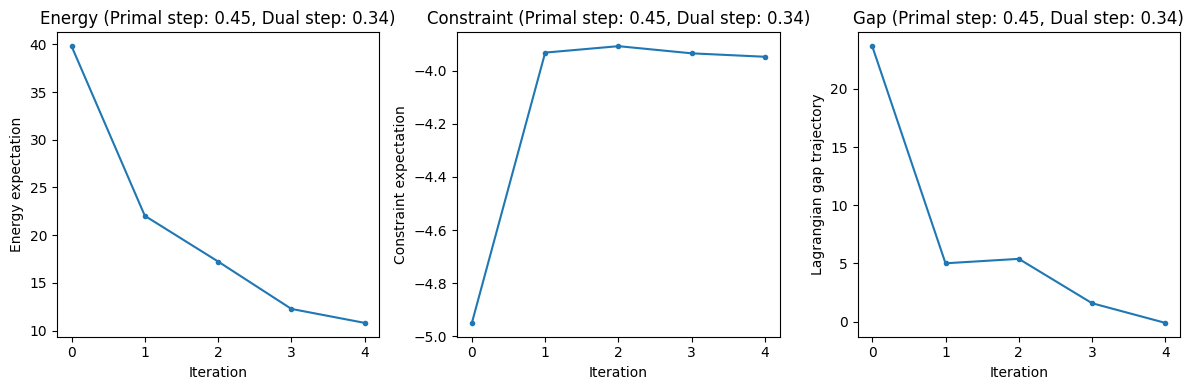

Sample 0: 000100110 with probability 0.0258 and energy 5.329070518200751e-15
Sample 1: 000101101 with probability 0.0179 and energy 9.999999999999996
Sample 2: 100100110 with probability 0.0169 and energy -7.259999999999993
Sample 3: 000111110 with probability 0.0164 and energy 7.105427357601002e-15
Sample 4: 000101000 with probability 0.0148 and energy 6.661338147750939e-15
Testing primal_perturb_step=0.45, dual_perturb_step=0.45


  0%|          | 1/200 [00:02<07:32,  2.27s/it]


Gap closed after 2 iterations; VQEC converged.


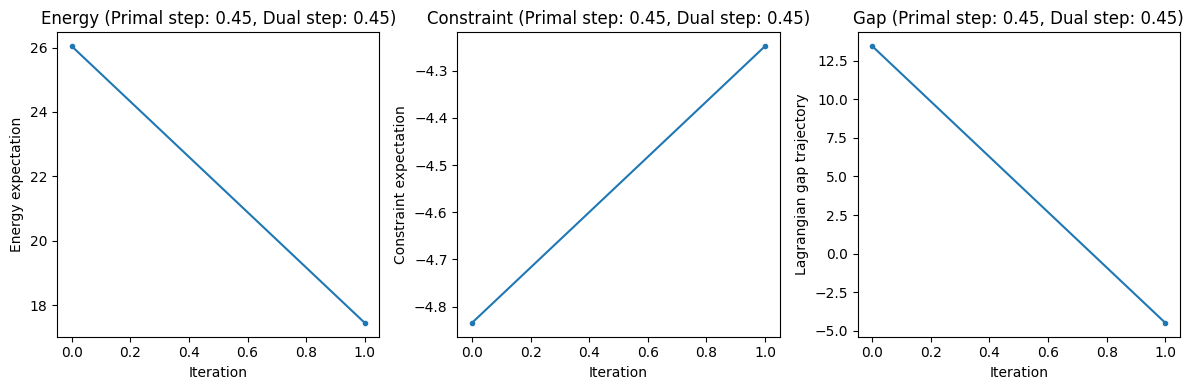

Sample 0: 000101110 with probability 0.0228 and energy 9.999999999999998
Sample 1: 000101100 with probability 0.0165 and energy 10.0
Sample 2: 000101000 with probability 0.0158 and energy 6.661338147750939e-15
Sample 3: 100101110 with probability 0.014 and energy 2.740000000000002
Sample 4: 100101000 with probability 0.0139 and energy -7.259999999999996
Testing primal_perturb_step=0.45, dual_perturb_step=0.56


  0%|          | 1/200 [00:02<07:24,  2.23s/it]

Gap closed after 2 iterations; VQEC converged.


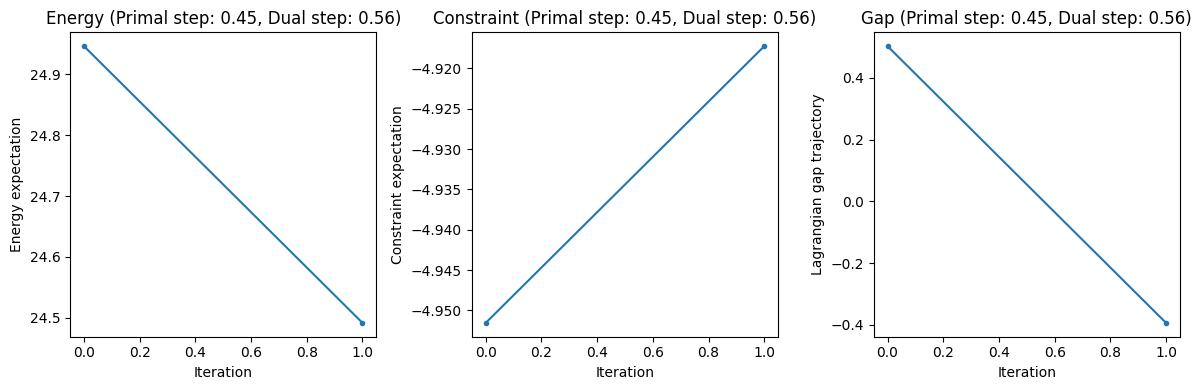

Sample 0: 001010101 with probability 0.0182 and energy 22.11
Sample 1: 110010110 with probability 0.0168 and energy 58.17999999999999
Sample 2: 001001110 with probability 0.0167 and energy -7.36999999999999
Sample 3: 001100110 with probability 0.0156 and energy -7.370000000000003
Sample 4: 110000000 with probability 0.0146 and energy 145.5
Testing primal_perturb_step=0.45, dual_perturb_step=0.67


  2%|▏         | 3/200 [00:04<05:20,  1.63s/it]

Gap closed after 4 iterations; VQEC converged.


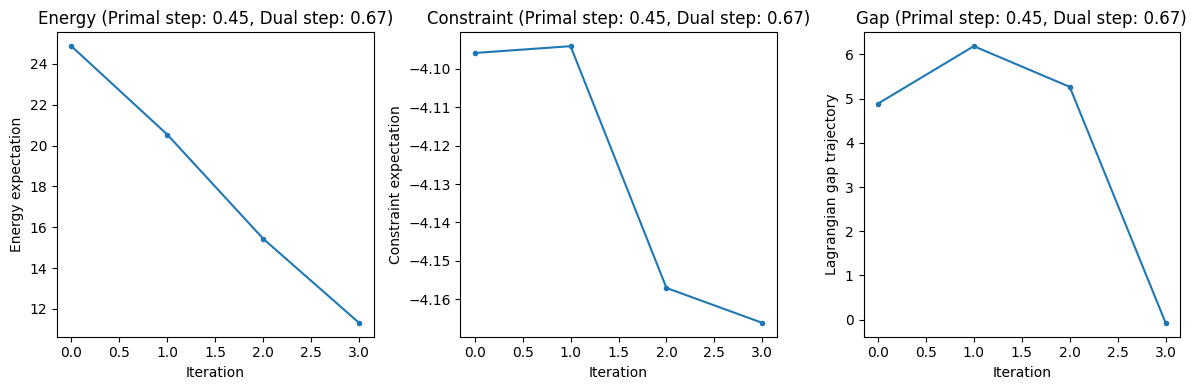

Sample 0: 001101111 with probability 0.039 and energy 17.36999999999999
Sample 1: 001100110 with probability 0.0332 and energy -7.370000000000003
Sample 2: 001101101 with probability 0.032 and energy 32.11
Sample 3: 000000010 with probability 0.0285 and energy -5.329070518200751e-15
Sample 4: 000001111 with probability 0.0267 and energy 0.0
Testing primal_perturb_step=0.45, dual_perturb_step=0.78


  5%|▌         | 10/200 [00:12<04:05,  1.29s/it]

Gap closed after 11 iterations; VQEC converged.


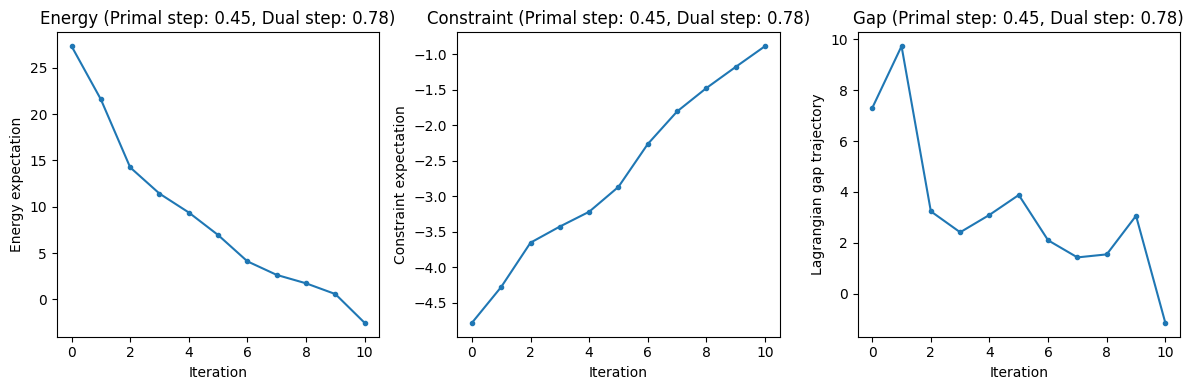

Sample 0: 100101011 with probability 0.1714 and energy -7.26
Sample 1: 100100110 with probability 0.1562 and energy -7.259999999999993
Sample 2: 000101011 with probability 0.1204 and energy 2.6645352591003757e-15
Sample 3: 000100110 with probability 0.1131 and energy 5.329070518200751e-15
Sample 4: 101111110 with probability 0.0418 and energy -14.62999999999998
Testing primal_perturb_step=0.45, dual_perturb_step=0.89


 10%|█         | 20/200 [00:24<03:41,  1.23s/it]

Gap closed after 21 iterations; VQEC converged.


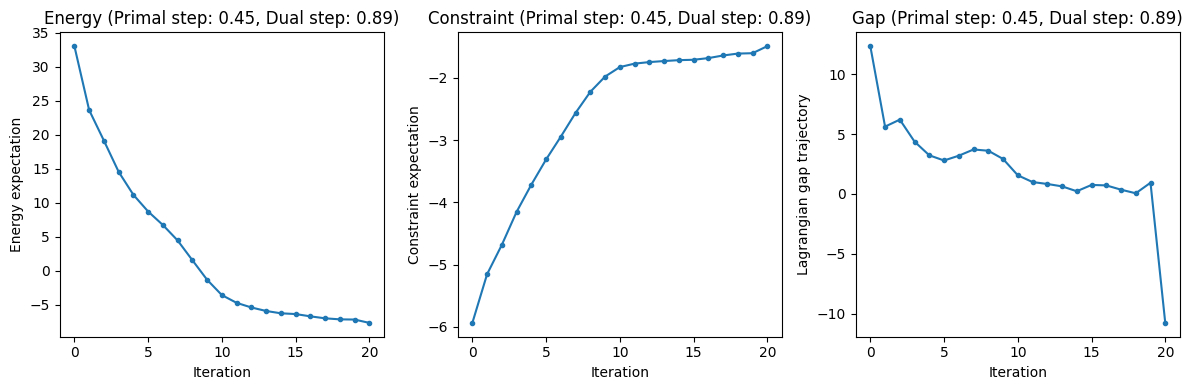

Sample 0: 001001110 with probability 0.2594 and energy -7.36999999999999
Sample 1: 001100110 with probability 0.2208 and energy -7.370000000000003
Sample 2: 010011011 with probability 0.1379 and energy -7.280000000000005
Sample 3: 010110011 with probability 0.1206 and energy -7.280000000000004
Sample 4: 010011010 with probability 0.0584 and energy -21.840000000000014
Testing primal_perturb_step=0.45, dual_perturb_step=1.0


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


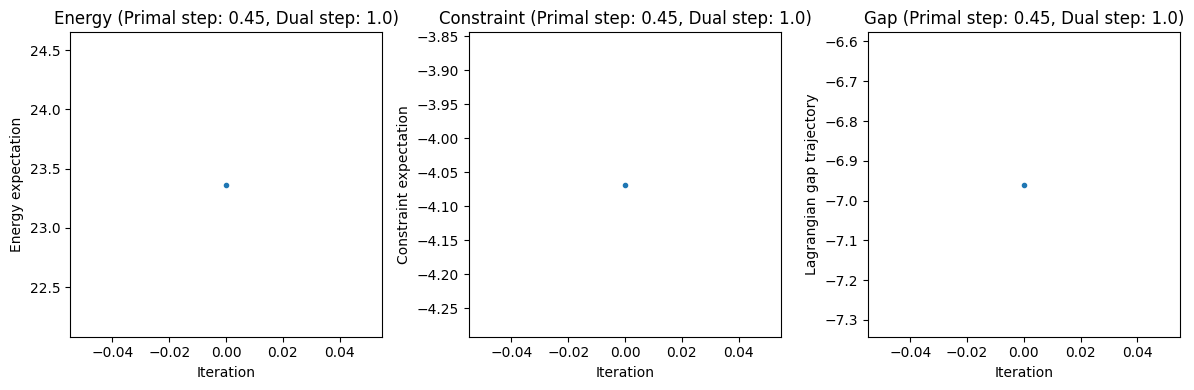

Sample 0: 111100001 with probability 0.0136 and energy 46.69
Sample 1: 111110111 with probability 0.0136 and energy 21.949999999999996
Sample 2: 001010001 with probability 0.0135 and energy 32.11000000000001
Sample 3: 111101011 with probability 0.0126 and energy -7.169999999999997
Sample 4: 010111111 with probability 0.0125 and energy 2.720000000000006
Testing primal_perturb_step=0.56, dual_perturb_step=0.01


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


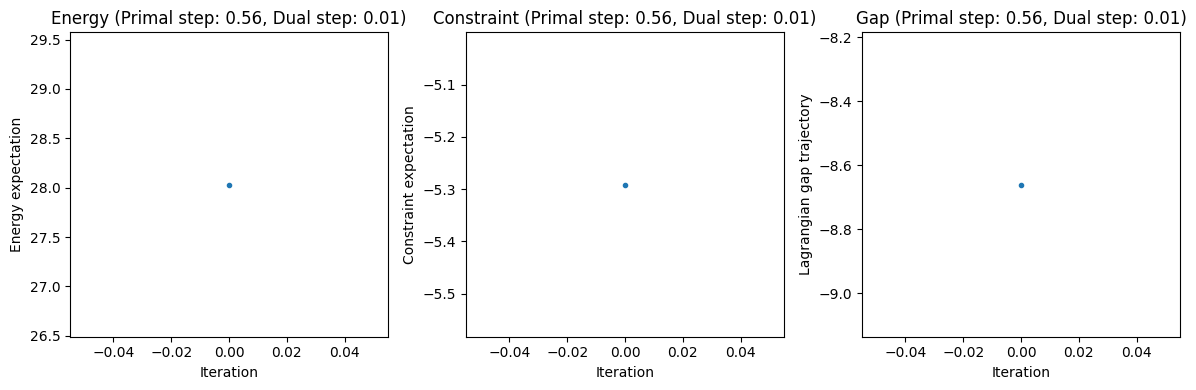

Sample 0: 100011111 with probability 0.0156 and energy 2.7399999999999967
Sample 1: 111101101 with probability 0.0122 and energy 46.69000000000001
Sample 2: 101011101 with probability 0.0121 and energy 24.85
Sample 3: 100011101 with probability 0.0103 and energy 2.74
Sample 4: 101000001 with probability 0.0102 and energy 43.89
Testing primal_perturb_step=0.56, dual_perturb_step=0.12


 21%|██        | 42/200 [00:50<03:09,  1.20s/it]

Converged after 43 iterations


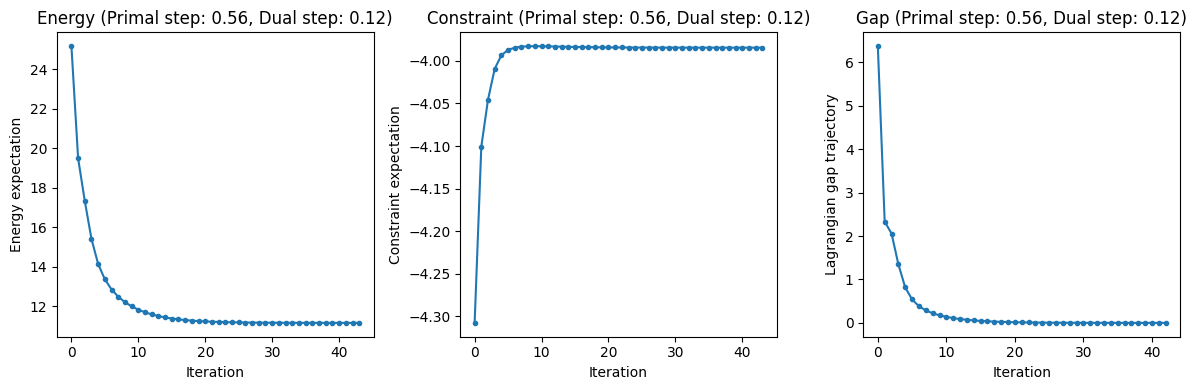

Sample 0: 000001011 with probability 0.0994 and energy 0.0
Sample 1: 000001001 with probability 0.0731 and energy 9.999999999999996
Sample 2: 000010101 with probability 0.05 and energy -8.881784197001252e-15
Sample 3: 000010111 with probability 0.0447 and energy -7.105427357601002e-15
Sample 4: 000011001 with probability 0.0447 and energy -7.105427357601002e-15
Testing primal_perturb_step=0.56, dual_perturb_step=0.23


  6%|▌         | 12/200 [00:16<04:22,  1.40s/it]

Converged after 13 iterations


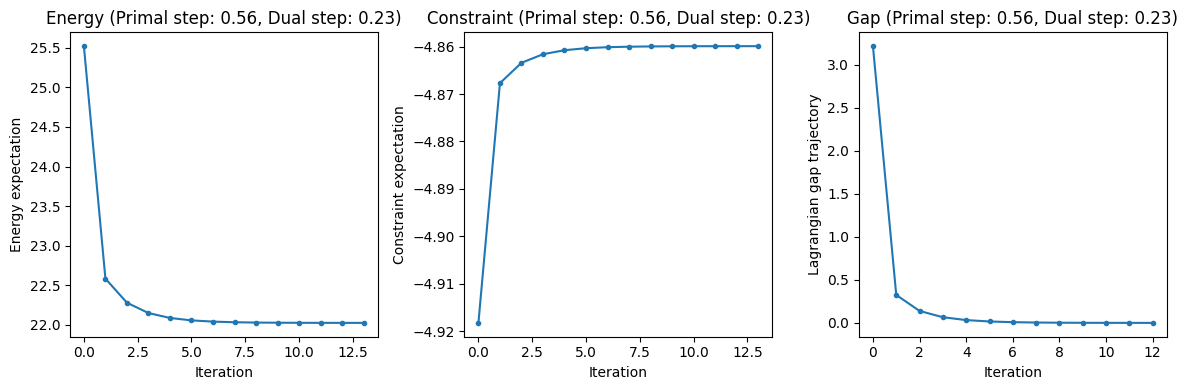

Sample 0: 100110000 with probability 0.0174 and energy -11.779999999999998
Sample 1: 100101101 with probability 0.0151 and energy 2.7399999999999984
Sample 2: 100100000 with probability 0.0138 and energy 2.740000000000004
Sample 3: 100110110 with probability 0.0134 and energy 7.2599999999999945
Sample 4: 100000101 with probability 0.0132 and energy 36.29999999999999
Testing primal_perturb_step=0.56, dual_perturb_step=0.34


  0%|          | 1/200 [00:02<07:53,  2.38s/it]

Gap closed after 2 iterations; VQEC converged.


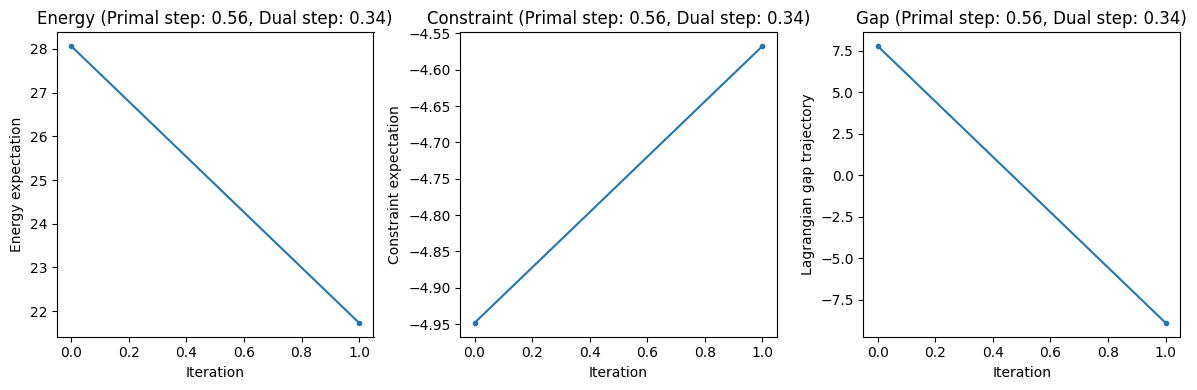

Sample 0: 000110000 with probability 0.0375 and energy 9.999999999999993
Sample 1: 000101100 with probability 0.0275 and energy 10.0
Sample 2: 000110010 with probability 0.0273 and energy -3.552713678800501e-15
Sample 3: 000101101 with probability 0.0255 and energy 9.999999999999996
Sample 4: 010100101 with probability 0.0156 and energy 65.52
Testing primal_perturb_step=0.56, dual_perturb_step=0.45


  0%|          | 1/200 [00:02<07:41,  2.32s/it]

Gap closed after 2 iterations; VQEC converged.


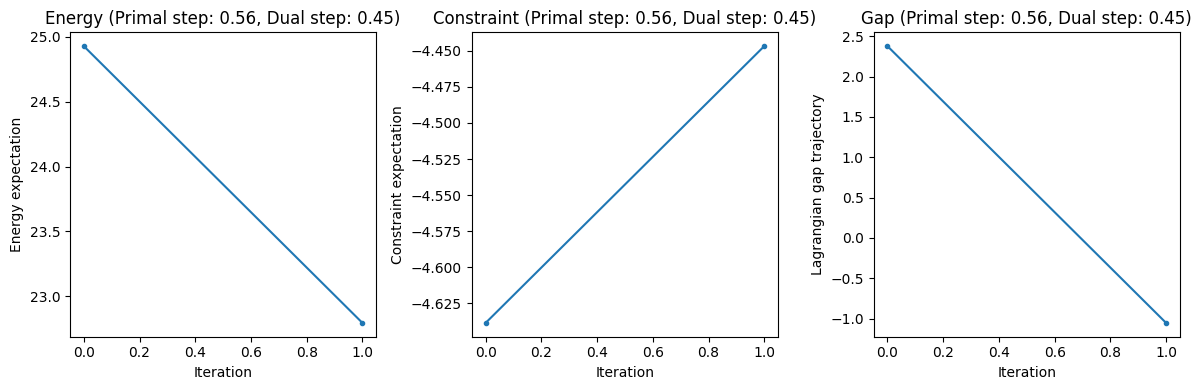

Sample 0: 110010111 with probability 0.0212 and energy 72.73999999999998
Sample 1: 110011101 with probability 0.0154 and energy 24.58
Sample 2: 010101111 with probability 0.0152 and energy 17.279999999999998
Sample 3: 110011100 with probability 0.0134 and energy 39.13999999999999
Sample 4: 100010111 with probability 0.0133 and energy 21.779999999999994
Testing primal_perturb_step=0.56, dual_perturb_step=0.56


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


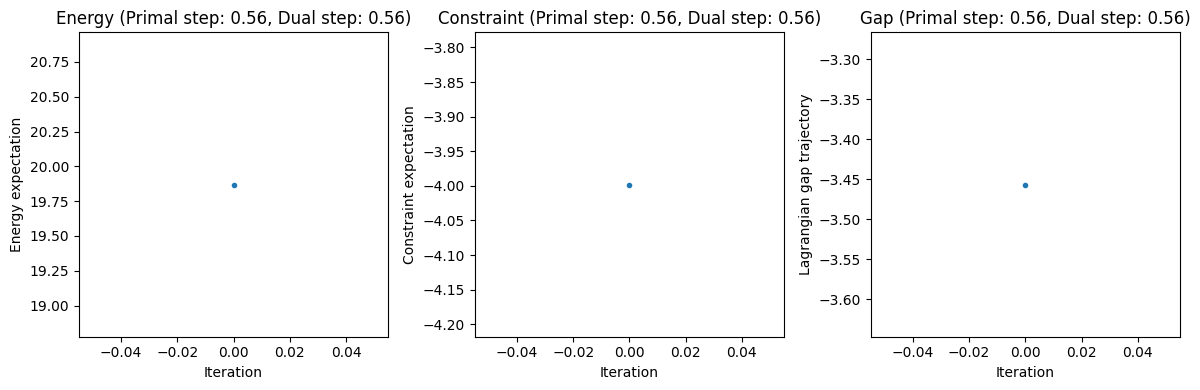

Sample 0: 110110000 with probability 0.03 and energy -19.05999999999999
Sample 1: 110010010 with probability 0.0261 and energy -4.539999999999997
Sample 2: 110110101 with probability 0.024 and energy 58.21999999999999
Sample 3: 110010101 with probability 0.017 and energy 29.139999999999993
Sample 4: 010110000 with probability 0.015 and energy 2.719999999999999
Testing primal_perturb_step=0.56, dual_perturb_step=0.67


  1%|          | 2/200 [00:04<06:47,  2.06s/it]

Gap closed after 3 iterations; VQEC converged.


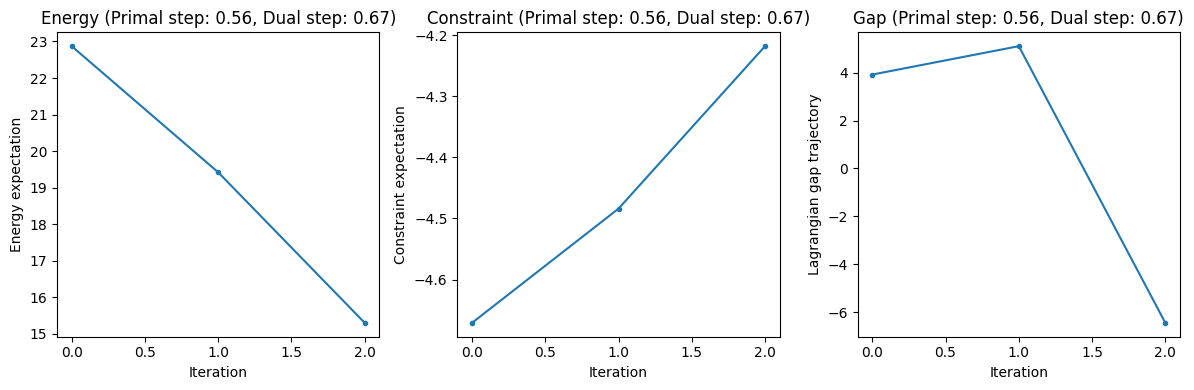

Sample 0: 100110011 with probability 0.0219 and energy 7.259999999999997
Sample 1: 100000011 with probability 0.0158 and energy 7.259999999999996
Sample 2: 100011100 with probability 0.0158 and energy 2.7399999999999918
Sample 3: 100011110 with probability 0.0149 and energy 2.7400000000000064
Sample 4: 101001011 with probability 0.014 and energy 29.14999999999999
Testing primal_perturb_step=0.56, dual_perturb_step=0.78


  0%|          | 1/200 [00:02<08:06,  2.44s/it]

Gap closed after 2 iterations; VQEC converged.


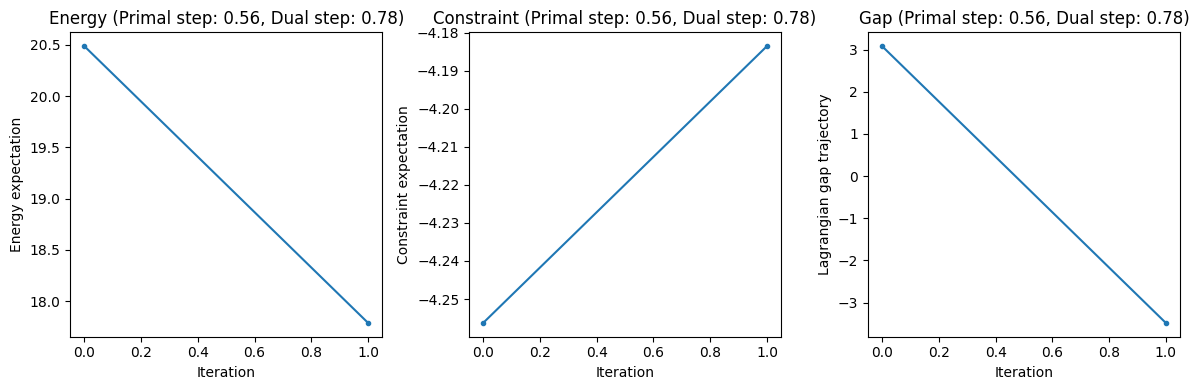

Sample 0: 001101110 with probability 0.0211 and energy 2.6299999999999972
Sample 1: 000000110 with probability 0.0192 and energy 10.0
Sample 2: 100000110 with probability 0.017 and energy -11.780000000000006
Sample 3: 101101010 with probability 0.0164 and energy 14.41
Sample 4: 001101001 with probability 0.0152 and energy 22.110000000000007
Testing primal_perturb_step=0.56, dual_perturb_step=0.89


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


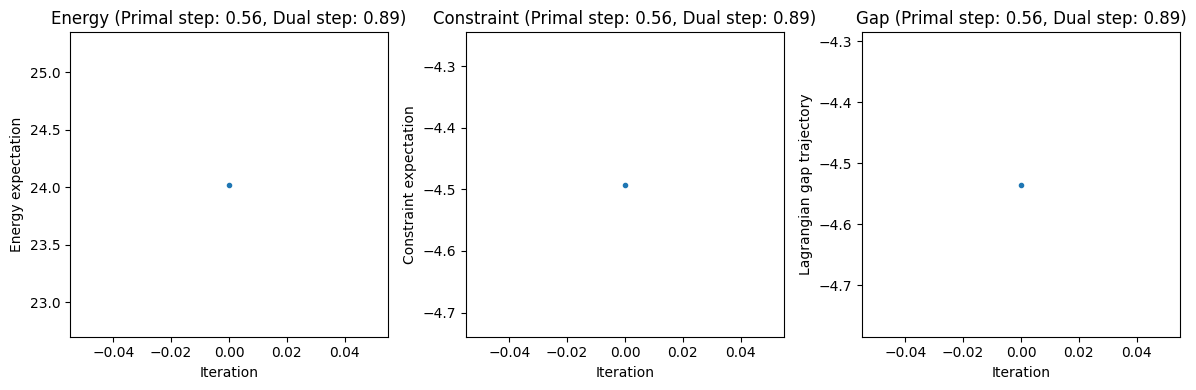

Sample 0: 010101011 with probability 0.0211 and energy -7.279999999999999
Sample 1: 110010101 with probability 0.0196 and energy 29.139999999999993
Sample 2: 100010011 with probability 0.0191 and energy 2.7400000000000078
Sample 3: 010100001 with probability 0.0184 and energy 31.839999999999996
Sample 4: 110101011 with probability 0.0178 and energy -14.540000000000003
Testing primal_perturb_step=0.56, dual_perturb_step=1.0


  4%|▎         | 7/200 [00:09<04:25,  1.37s/it]

Converged after 8 iterations


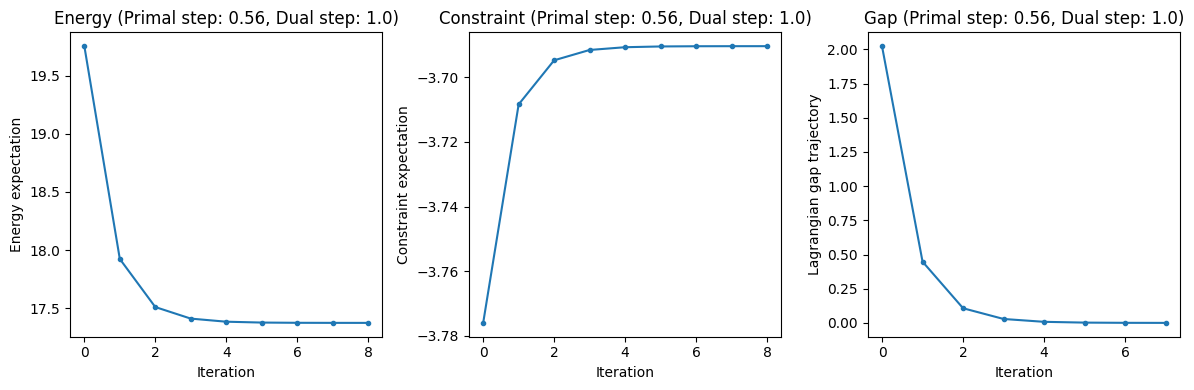

Sample 0: 000100001 with probability 0.0217 and energy 10.000000000000002
Sample 1: 000110001 with probability 0.0182 and energy 0.0
Sample 2: 000111101 with probability 0.0175 and energy -1.5987211554602254e-14
Sample 3: 010011110 with probability 0.0164 and energy 2.7199999999999998
Sample 4: 111011011 with probability 0.0163 and energy -7.17
Testing primal_perturb_step=0.67, dual_perturb_step=0.01


  0%|          | 1/200 [00:02<07:54,  2.38s/it]

Gap closed after 2 iterations; VQEC converged.


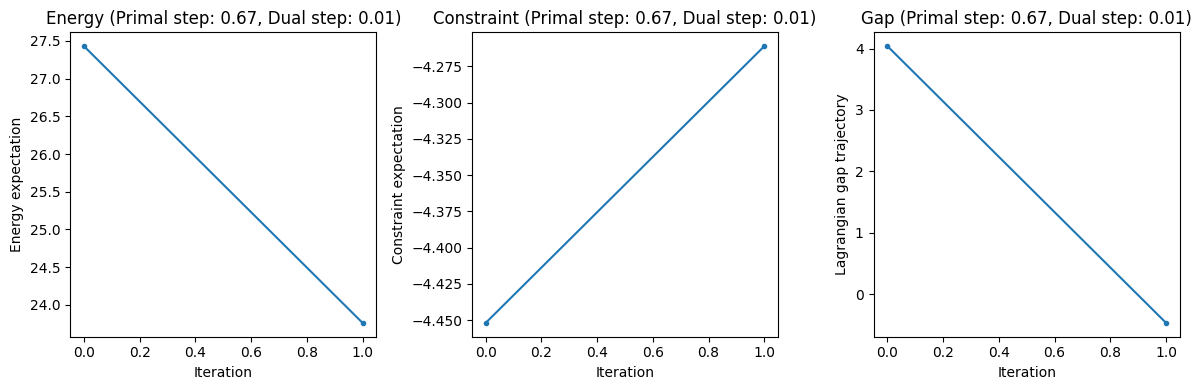

Sample 0: 111101011 with probability 0.0148 and energy -7.169999999999997
Sample 1: 001100110 with probability 0.0138 and energy -7.370000000000003
Sample 2: 111111011 with probability 0.0136 and energy 50.989999999999995
Sample 3: 110011100 with probability 0.0132 and energy 39.13999999999999
Sample 4: 110011110 with probability 0.0116 and energy -4.539999999999999
Testing primal_perturb_step=0.67, dual_perturb_step=0.12


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


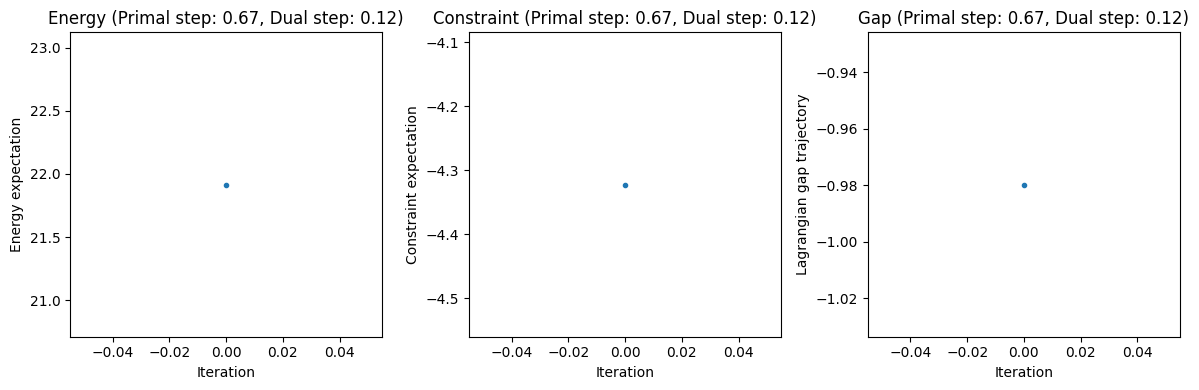

Sample 0: 010100010 with probability 0.0211 and energy 2.7199999999999918
Sample 1: 001010010 with probability 0.0196 and energy 2.630000000000001
Sample 2: 001010001 with probability 0.0139 and energy 32.11000000000001
Sample 3: 011010010 with probability 0.0131 and energy -4.6500000000000075
Sample 4: 001010101 with probability 0.0127 and energy 22.11
Testing primal_perturb_step=0.67, dual_perturb_step=0.23


  1%|          | 2/200 [00:03<06:04,  1.84s/it]

Gap closed after 3 iterations; VQEC converged.


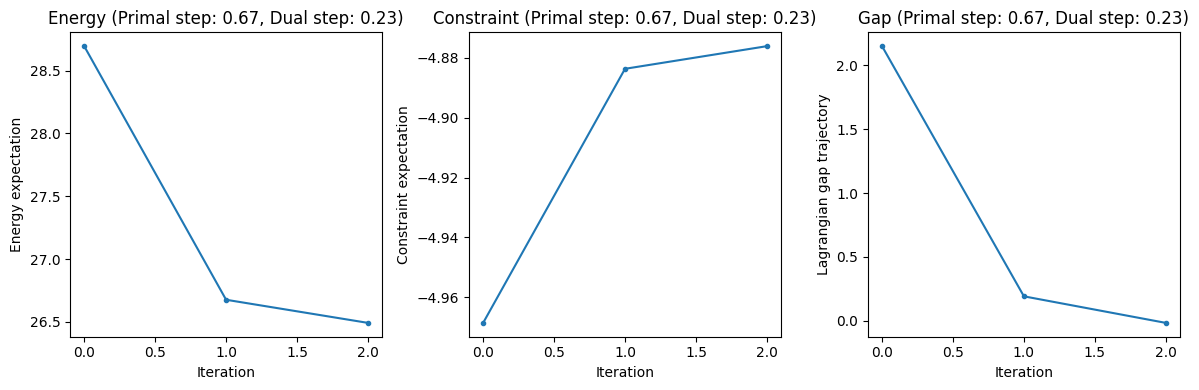

Sample 0: 111001101 with probability 0.0236 and energy 36.690000000000005
Sample 1: 111001110 with probability 0.021 and energy 36.25
Sample 2: 101111010 with probability 0.0167 and energy -0.10999999999999943
Sample 3: 100110010 with probability 0.0164 and energy 21.78
Sample 4: 111001001 with probability 0.0162 and energy 3.0500000000000043
Testing primal_perturb_step=0.67, dual_perturb_step=0.34


  0%|          | 1/200 [00:02<07:33,  2.28s/it]

Gap closed after 2 iterations; VQEC converged.


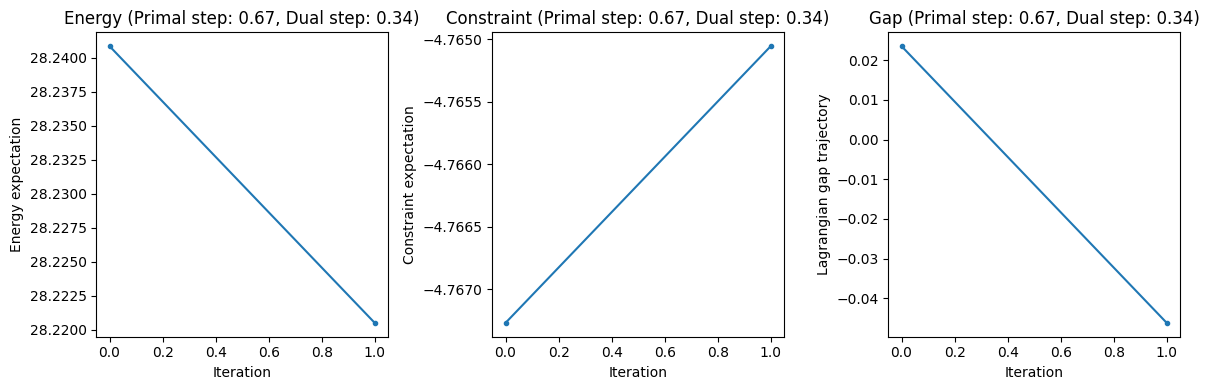

Sample 0: 100010000 with probability 0.0233 and energy 2.7400000000000073
Sample 1: 100010101 with probability 0.017 and energy -7.2600000000000104
Sample 2: 100111001 with probability 0.0145 and energy 7.259999999999998
Sample 3: 100111100 with probability 0.0131 and energy 7.259999999999986
Sample 4: 100111010 with probability 0.0124 and energy 7.259999999999991
Testing primal_perturb_step=0.67, dual_perturb_step=0.45


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


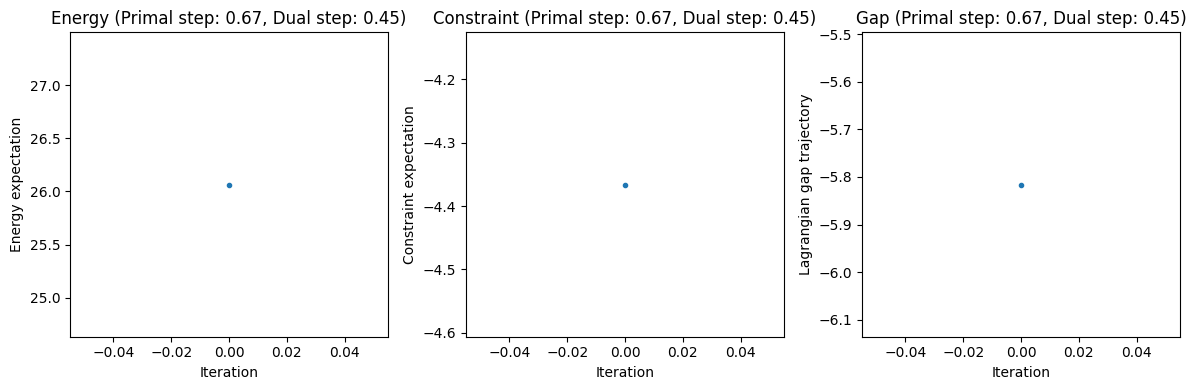

Sample 0: 110000011 with probability 0.0278 and energy 58.21999999999999
Sample 1: 010000011 with probability 0.0232 and energy 50.95999999999999
Sample 2: 011001011 with probability 0.0227 and energy 29.20999999999999
Sample 3: 001111011 with probability 0.0204 and energy 7.370000000000001
Sample 4: 100100011 with probability 0.0162 and energy 2.7400000000000073
Testing primal_perturb_step=0.67, dual_perturb_step=0.56


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


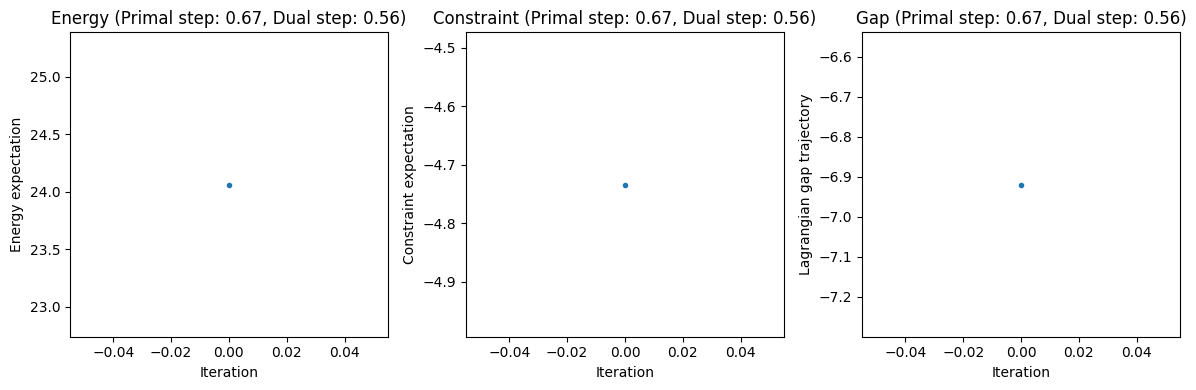

Sample 0: 100111111 with probability 0.0231 and energy -11.779999999999992
Sample 1: 101011001 with probability 0.0203 and energy 43.89
Sample 2: 101011100 with probability 0.0199 and energy 39.58999999999999
Sample 3: 101011000 with probability 0.0188 and energy 29.590000000000007
Sample 4: 100111100 with probability 0.0187 and energy 7.259999999999986
Testing primal_perturb_step=0.67, dual_perturb_step=0.67


  0%|          | 1/200 [00:02<08:13,  2.48s/it]

Gap closed after 2 iterations; VQEC converged.


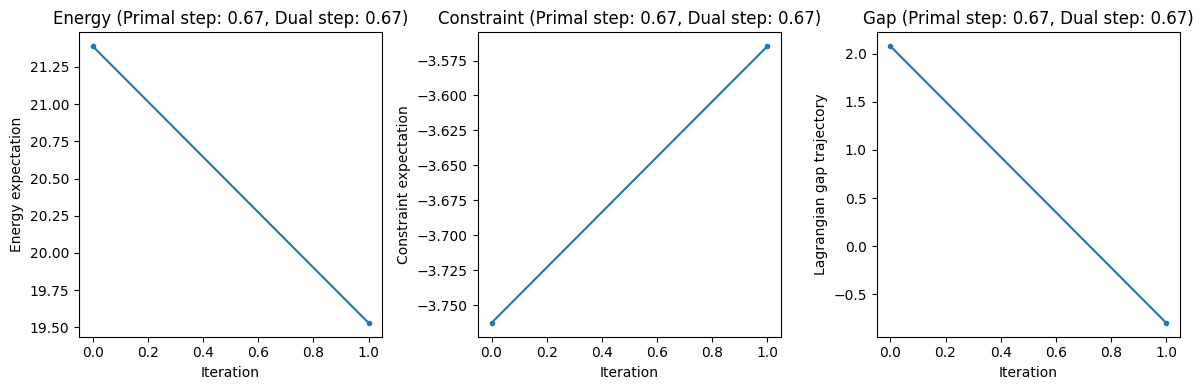

Sample 0: 100100011 with probability 0.0295 and energy 2.7400000000000073
Sample 1: 100101010 with probability 0.0288 and energy 21.779999999999998
Sample 2: 111010011 with probability 0.0211 and energy 17.39
Sample 3: 111000111 with probability 0.0208 and energy 21.949999999999996
Sample 4: 111011010 with probability 0.0197 and energy -36.46999999999999
Testing primal_perturb_step=0.67, dual_perturb_step=0.78


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


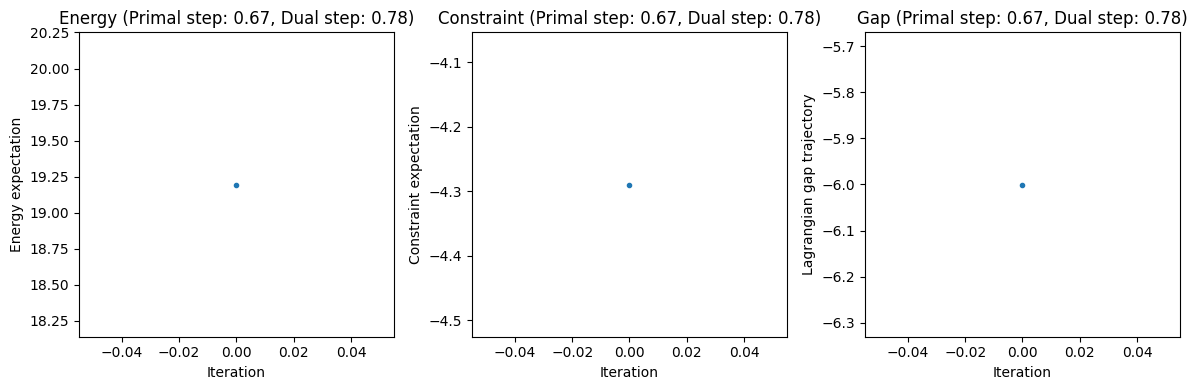

Sample 0: 001000111 with probability 0.0251 and energy 7.369999999999996
Sample 1: 001101111 with probability 0.0178 and energy 17.36999999999999
Sample 2: 001111111 with probability 0.0172 and energy 17.36999999999999
Sample 3: 001101001 with probability 0.0168 and energy 22.110000000000007
Sample 4: 001110100 with probability 0.0164 and energy 36.849999999999994
Testing primal_perturb_step=0.67, dual_perturb_step=0.89


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


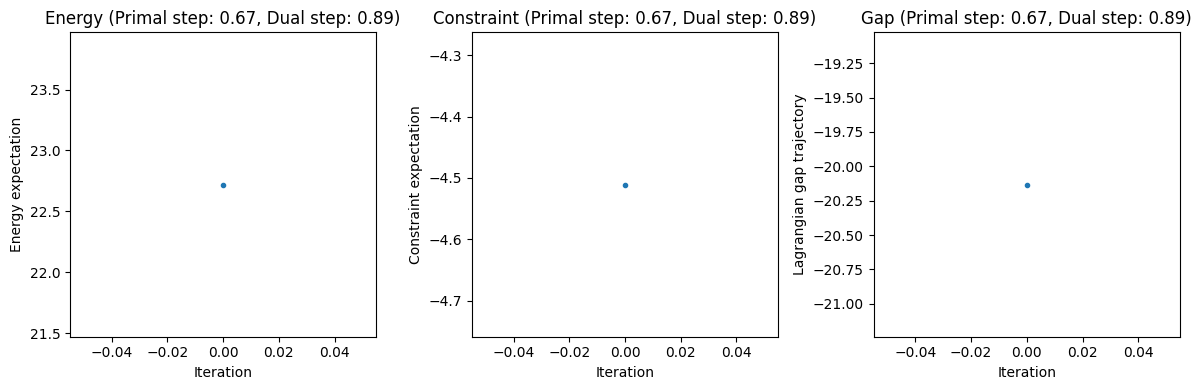

Sample 0: 101100101 with probability 0.0171 and energy 43.88999999999999
Sample 1: 101101000 with probability 0.0134 and energy 29.59
Sample 2: 010100101 with probability 0.0116 and energy 65.52
Sample 3: 101100011 with probability 0.0107 and energy 10.110000000000005
Sample 4: 101110011 with probability 0.0106 and energy 14.629999999999999
Testing primal_perturb_step=0.67, dual_perturb_step=1.0


  0%|          | 1/200 [00:02<07:56,  2.39s/it]

Gap closed after 2 iterations; VQEC converged.


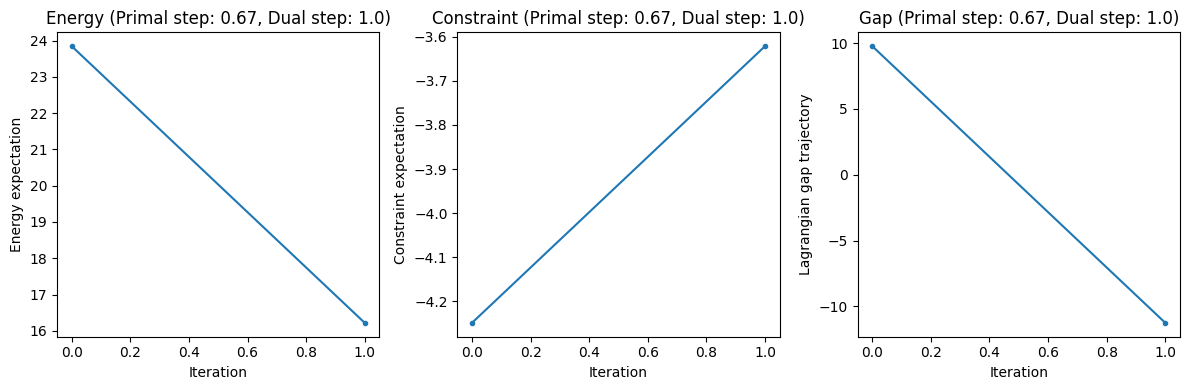

Sample 0: 011011111 with probability 0.0244 and energy 24.65
Sample 1: 000101011 with probability 0.0205 and energy 2.6645352591003757e-15
Sample 2: 000110011 with probability 0.0185 and energy 8.881784197001252e-16
Sample 3: 000100101 with probability 0.018 and energy -3.552713678800501e-15
Sample 4: 000111000 with probability 0.018 and energy 8.881784197001252e-16
Testing primal_perturb_step=0.78, dual_perturb_step=0.01


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


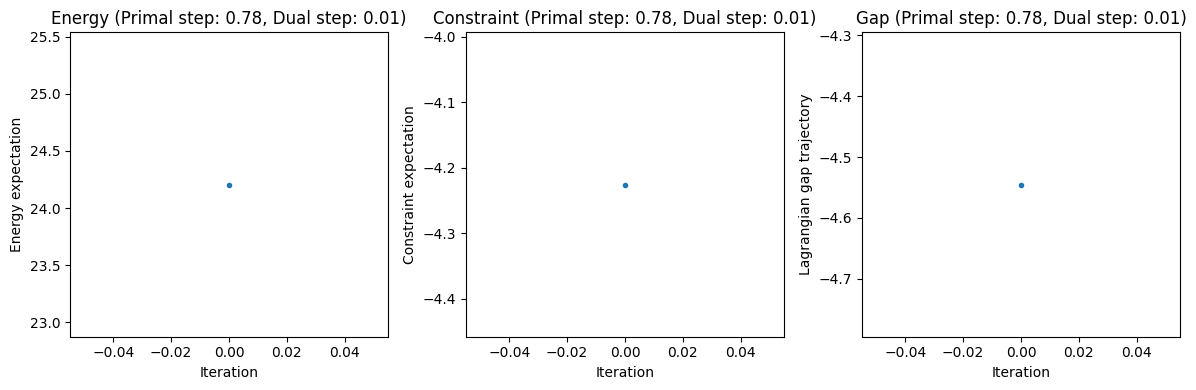

Sample 0: 101110001 with probability 0.0351 and energy 14.850000000000005
Sample 1: 110100100 with probability 0.0306 and energy 101.85999999999999
Sample 2: 101110010 with probability 0.0282 and energy 14.410000000000009
Sample 3: 001011010 with probability 0.0189 and energy -7.369999999999997
Sample 4: 100001010 with probability 0.0183 and energy 36.3
Testing primal_perturb_step=0.78, dual_perturb_step=0.12


  0%|          | 1/200 [00:02<07:23,  2.23s/it]

Gap closed after 2 iterations; VQEC converged.


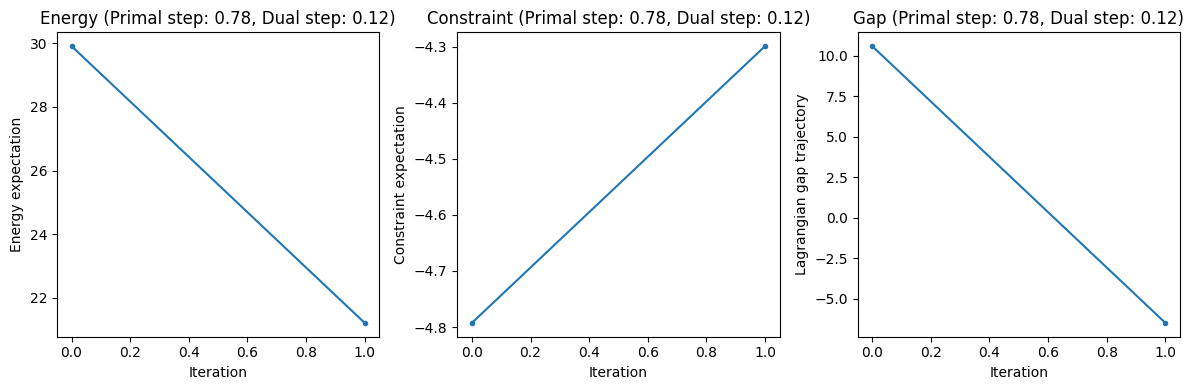

Sample 0: 111111100 with probability 0.0251 and energy 95.07
Sample 1: 100010001 with probability 0.0174 and energy 2.7400000000000038
Sample 2: 100110001 with probability 0.0169 and energy -7.259999999999998
Sample 3: 100000011 with probability 0.016 and energy 7.259999999999996
Sample 4: 100110010 with probability 0.0135 and energy 21.78
Testing primal_perturb_step=0.78, dual_perturb_step=0.23


  2%|▏         | 3/200 [00:04<05:23,  1.64s/it]

Gap closed after 4 iterations; VQEC converged.


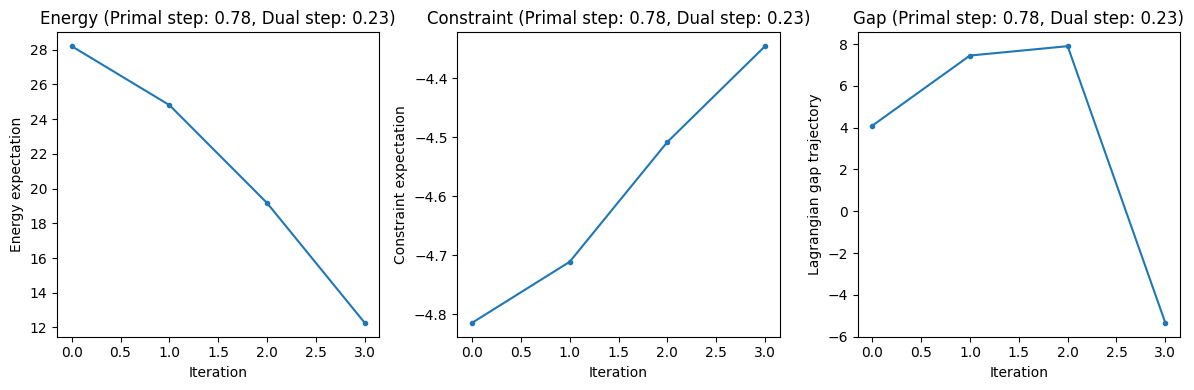

Sample 0: 000000011 with probability 0.0341 and energy -7.105427357601002e-15
Sample 1: 000000010 with probability 0.0278 and energy -5.329070518200751e-15
Sample 2: 000001010 with probability 0.0241 and energy -3.552713678800501e-15
Sample 3: 001001010 with probability 0.0209 and energy -7.370000000000001
Sample 4: 001000011 with probability 0.0189 and energy 7.3700000000000045
Testing primal_perturb_step=0.78, dual_perturb_step=0.34


  0%|          | 1/200 [00:02<07:23,  2.23s/it]

Gap closed after 2 iterations; VQEC converged.


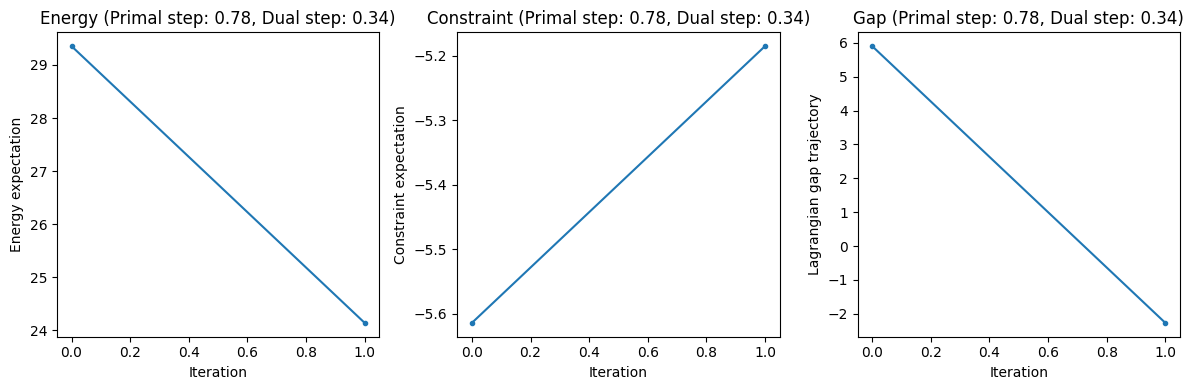

Sample 0: 110000001 with probability 0.0229 and energy 101.86000000000001
Sample 1: 100010001 with probability 0.0192 and energy 2.7400000000000038
Sample 2: 000100110 with probability 0.0147 and energy 5.329070518200751e-15
Sample 3: 100001100 with probability 0.0131 and energy 7.2599999999999945
Sample 4: 101101100 with probability 0.013 and energy 39.58999999999999
Testing primal_perturb_step=0.78, dual_perturb_step=0.45


  1%|          | 2/200 [00:03<05:55,  1.80s/it]

Gap closed after 3 iterations; VQEC converged.


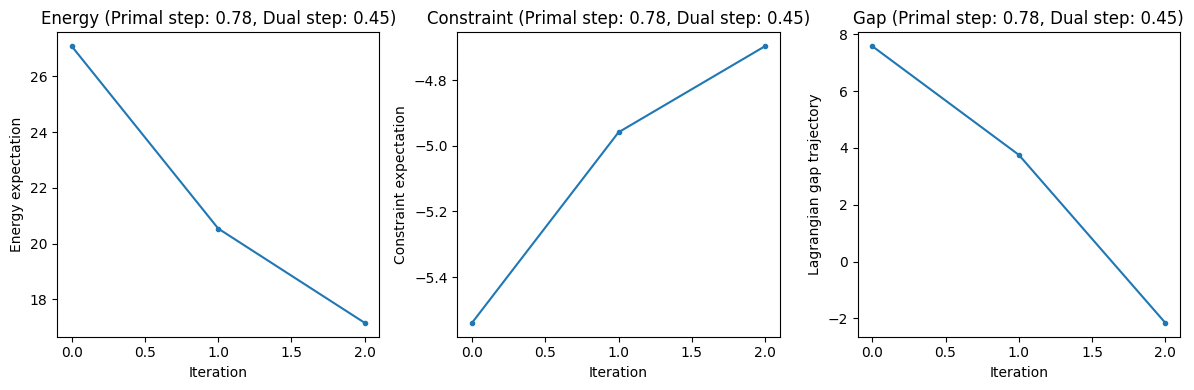

Sample 0: 000001100 with probability 0.0353 and energy -8.881784197001252e-15
Sample 1: 000001111 with probability 0.0238 and energy 0.0
Sample 2: 000001010 with probability 0.0207 and energy -3.552713678800501e-15
Sample 3: 000000111 with probability 0.0189 and energy 1.7763568394002505e-15
Sample 4: 000000110 with probability 0.0178 and energy 10.0
Testing primal_perturb_step=0.78, dual_perturb_step=0.56


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


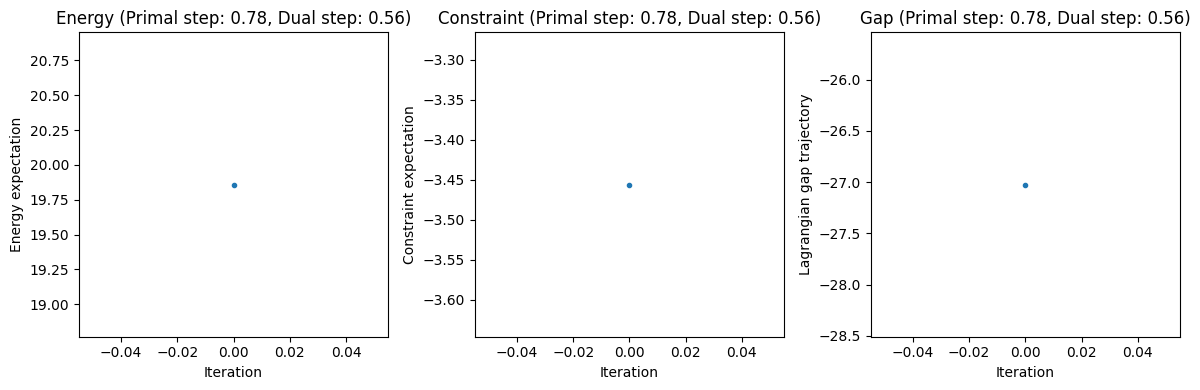

Sample 0: 001101000 with probability 0.0125 and energy 36.85
Sample 1: 110011001 with probability 0.0125 and energy 58.18000000000001
Sample 2: 100111011 with probability 0.0122 and energy 21.779999999999998
Sample 3: 110101001 with probability 0.0122 and energy 0.020000000000010232
Sample 4: 100111010 with probability 0.0117 and energy 7.259999999999991
Testing primal_perturb_step=0.78, dual_perturb_step=0.67


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


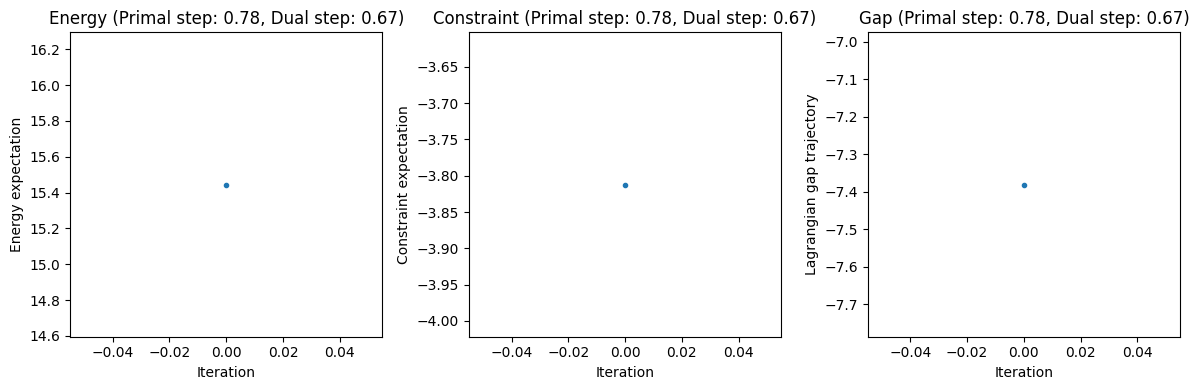

Sample 0: 101100011 with probability 0.0317 and energy 10.110000000000005
Sample 1: 101110111 with probability 0.0287 and energy 0.109999999999987
Sample 2: 101100110 with probability 0.0273 and energy -14.63
Sample 3: 101101001 with probability 0.0227 and energy 14.850000000000005
Sample 4: 101110001 with probability 0.0198 and energy 14.850000000000005
Testing primal_perturb_step=0.78, dual_perturb_step=0.78


  1%|          | 2/200 [00:03<05:35,  1.69s/it]

Gap closed after 3 iterations; VQEC converged.


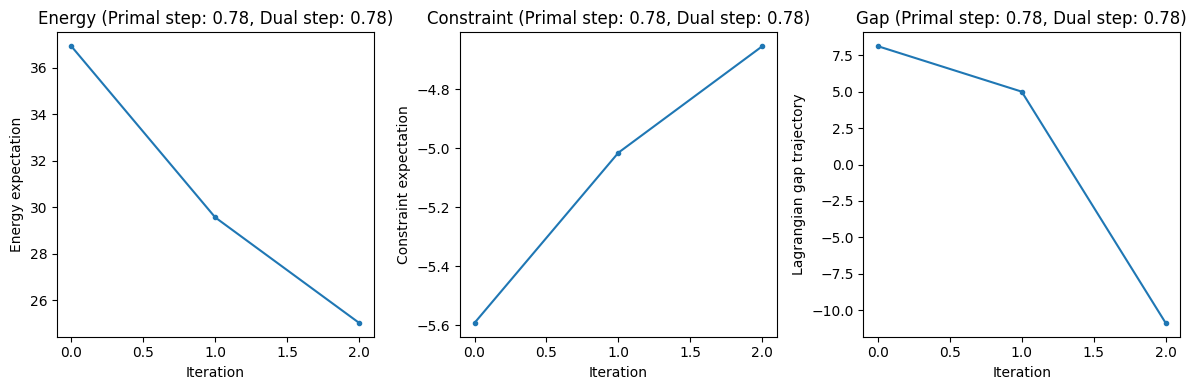

Sample 0: 100011000 with probability 0.0535 and energy -7.259999999999998
Sample 1: 111001100 with probability 0.0259 and energy 95.07000000000001
Sample 2: 111000100 with probability 0.0243 and energy 138.71
Sample 3: 100011010 with probability 0.0234 and energy -7.2600000000000104
Sample 4: 100010000 with probability 0.0232 and energy 2.7400000000000073
Testing primal_perturb_step=0.78, dual_perturb_step=0.89


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


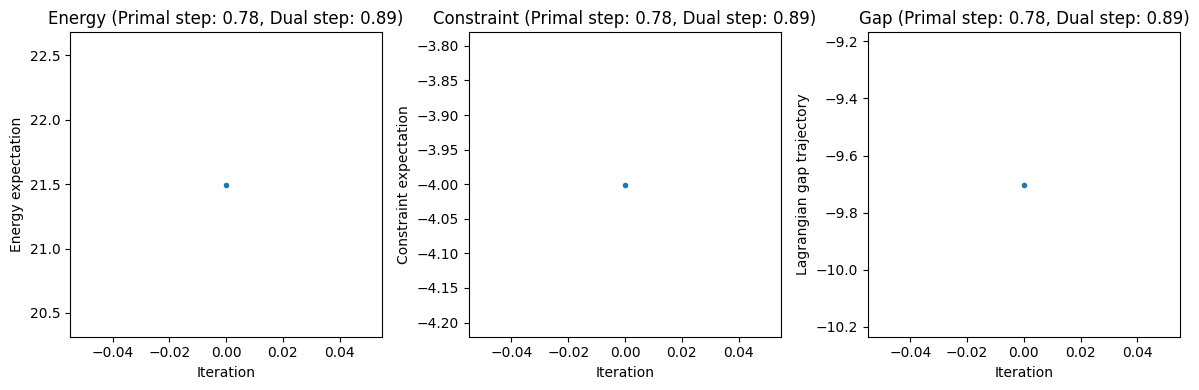

Sample 0: 000011001 with probability 0.0226 and energy -7.105427357601002e-15
Sample 1: 110111110 with probability 0.0187 and energy -14.54
Sample 2: 000101001 with probability 0.0172 and energy 1.0658141036401503e-14
Sample 3: 010111110 with probability 0.0128 and energy -7.279999999999996
Sample 4: 000010010 with probability 0.0125 and energy 10.000000000000005
Testing primal_perturb_step=0.78, dual_perturb_step=1.0


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


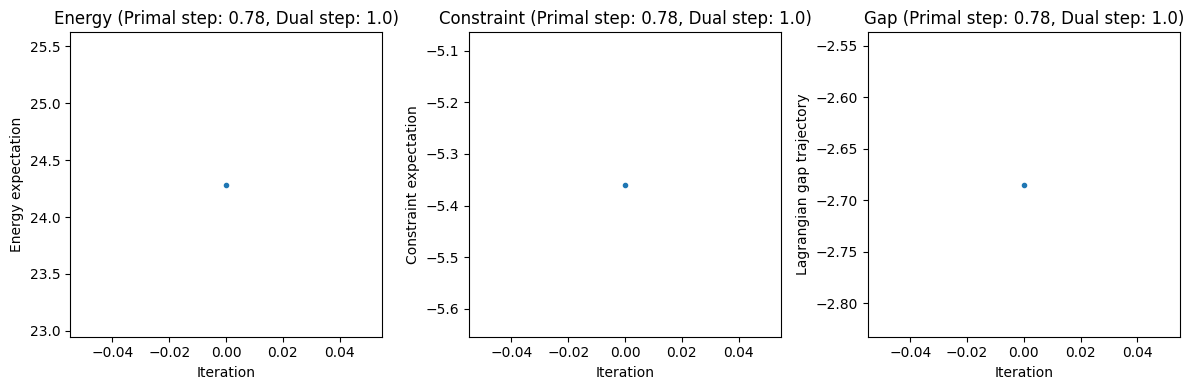

Sample 0: 001010111 with probability 0.0194 and energy 7.369999999999997
Sample 1: 111110111 with probability 0.0183 and energy 21.949999999999996
Sample 2: 111110100 with probability 0.0157 and energy 138.71
Sample 3: 100000111 with probability 0.015 and energy -7.260000000000001
Sample 4: 110010111 with probability 0.0142 and energy 72.73999999999998
Testing primal_perturb_step=0.89, dual_perturb_step=0.01


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


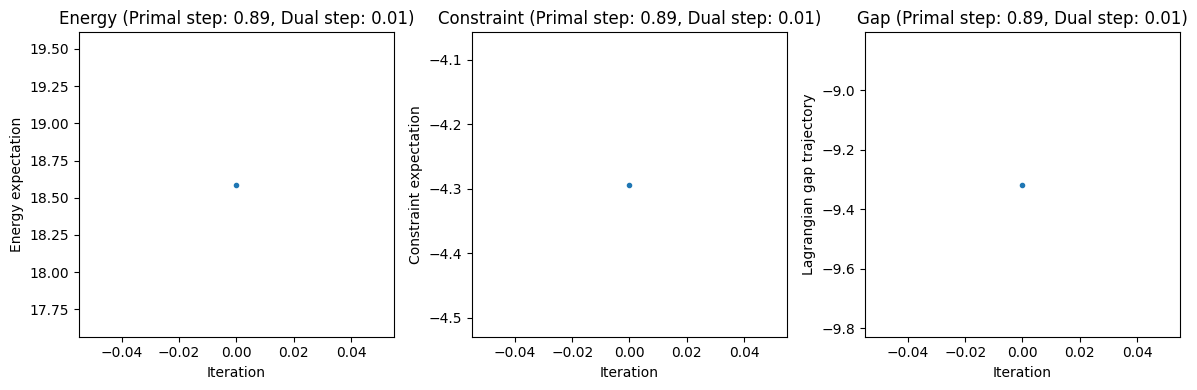

Sample 0: 101110111 with probability 0.0215 and energy 0.109999999999987
Sample 1: 100010001 with probability 0.0152 and energy 2.7400000000000038
Sample 2: 100011111 with probability 0.013 and energy 2.7399999999999967
Sample 3: 100010011 with probability 0.0122 and energy 2.7400000000000078
Sample 4: 100011000 with probability 0.0122 and energy -7.259999999999998
Testing primal_perturb_step=0.89, dual_perturb_step=0.12


  0%|          | 1/200 [00:02<08:15,  2.49s/it]

Gap closed after 2 iterations; VQEC converged.


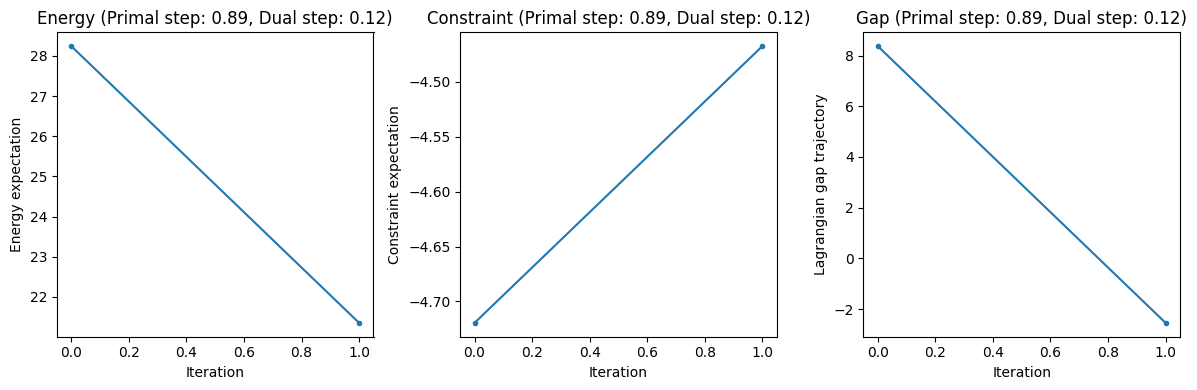

Sample 0: 001001000 with probability 0.0136 and energy 36.85
Sample 1: 100111000 with probability 0.0136 and energy -7.260000000000001
Sample 2: 100101000 with probability 0.0119 and energy -7.259999999999996
Sample 3: 100111011 with probability 0.0118 and energy 21.779999999999998
Sample 4: 101000110 with probability 0.011 and energy -19.150000000000006
Testing primal_perturb_step=0.89, dual_perturb_step=0.23


  2%|▎         | 5/200 [00:07<04:36,  1.42s/it]

Gap closed after 6 iterations; VQEC converged.


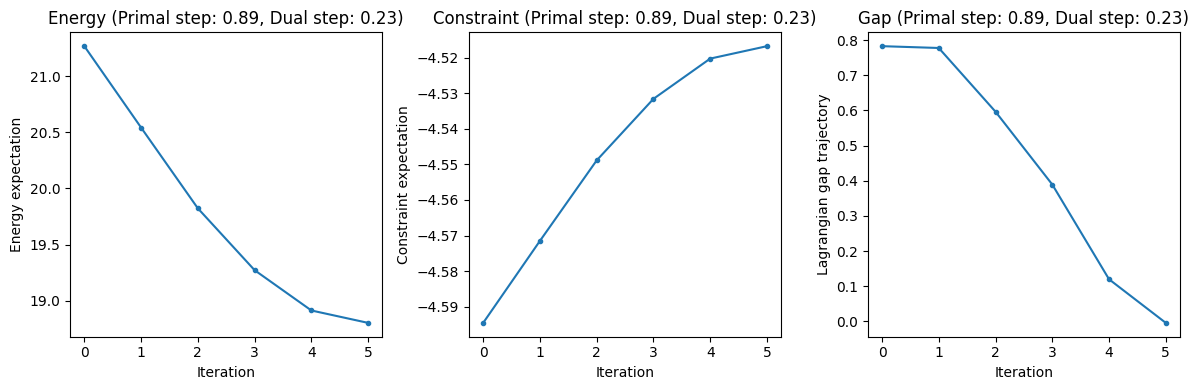

Sample 0: 001000111 with probability 0.0261 and energy 7.369999999999996
Sample 1: 001010111 with probability 0.0163 and energy 7.369999999999997
Sample 2: 001110101 with probability 0.0144 and energy 22.109999999999992
Sample 3: 100001111 with probability 0.0138 and energy 36.29999999999999
Sample 4: 000011010 with probability 0.0117 and energy -1.4210854715202004e-14
Testing primal_perturb_step=0.89, dual_perturb_step=0.34


  0%|          | 1/200 [00:02<08:07,  2.45s/it]

Gap closed after 2 iterations; VQEC converged.


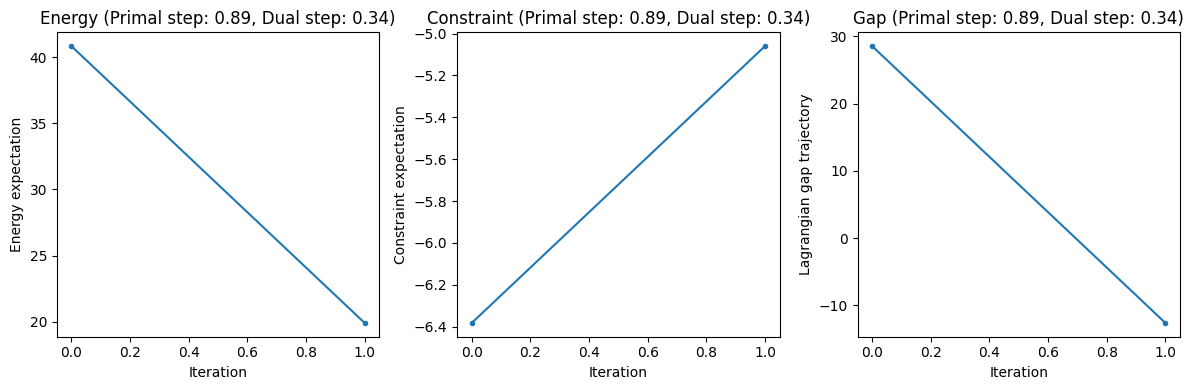

Sample 0: 000011000 with probability 0.0219 and energy -2.6645352591003757e-15
Sample 1: 000010100 with probability 0.0191 and energy -1.4210854715202004e-14
Sample 2: 001011010 with probability 0.0156 and energy -7.369999999999997
Sample 3: 001100101 with probability 0.0132 and energy 22.11
Sample 4: 000100111 with probability 0.0122 and energy -7.105427357601002e-15
Testing primal_perturb_step=0.89, dual_perturb_step=0.45


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


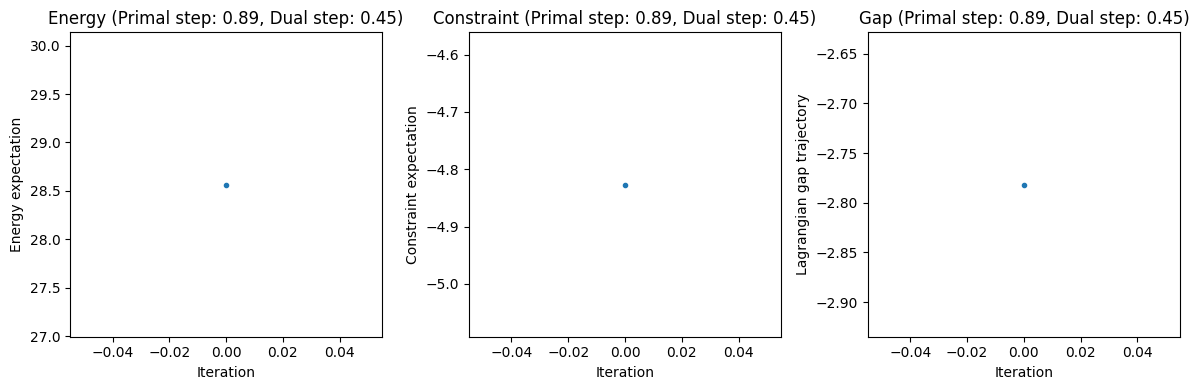

Sample 0: 110011110 with probability 0.0194 and energy -4.539999999999999
Sample 1: 010011110 with probability 0.0157 and energy 2.7199999999999998
Sample 2: 110000001 with probability 0.0125 and energy 101.86000000000001
Sample 3: 110010101 with probability 0.0123 and energy 29.139999999999993
Sample 4: 001100000 with probability 0.0122 and energy 46.85000000000001
Testing primal_perturb_step=0.89, dual_perturb_step=0.56


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


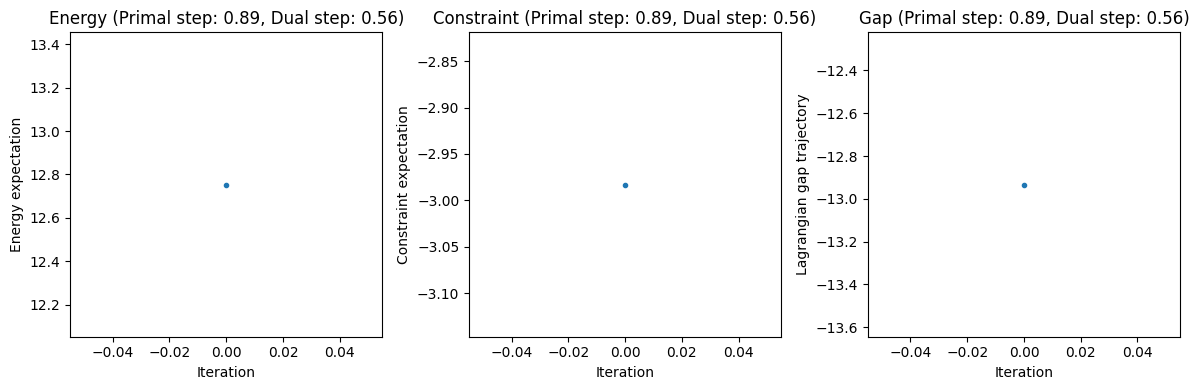

Sample 0: 000110011 with probability 0.0261 and energy 8.881784197001252e-16
Sample 1: 000000010 with probability 0.0259 and energy -5.329070518200751e-15
Sample 2: 001011010 with probability 0.024 and energy -7.369999999999997
Sample 3: 110101111 with probability 0.0231 and energy 10.02
Sample 4: 001110011 with probability 0.02 and energy 7.370000000000002
Testing primal_perturb_step=0.89, dual_perturb_step=0.67


  1%|          | 2/200 [00:03<05:32,  1.68s/it]

Gap closed after 3 iterations; VQEC converged.


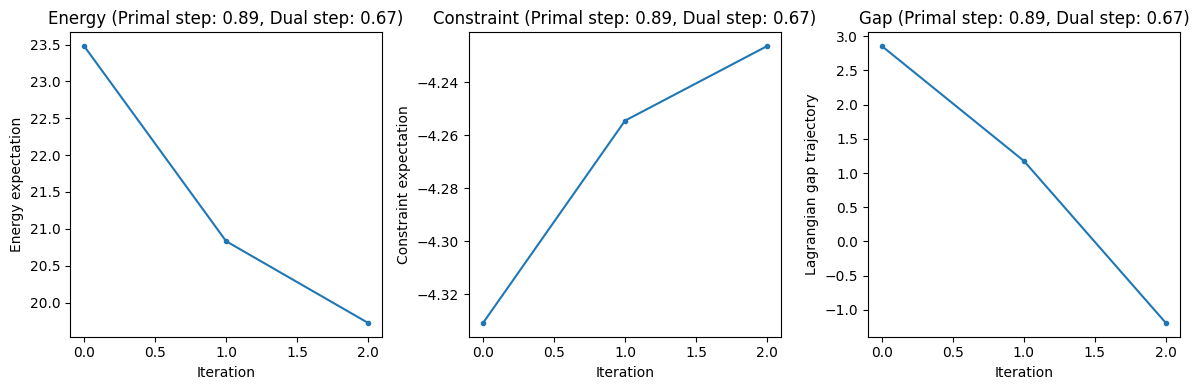

Sample 0: 001111111 with probability 0.0206 and energy 17.36999999999999
Sample 1: 000010011 with probability 0.0198 and energy 10.000000000000005
Sample 2: 100100011 with probability 0.0191 and energy 2.7400000000000073
Sample 3: 000100011 with probability 0.0173 and energy 10.000000000000009
Sample 4: 100010011 with probability 0.016 and energy 2.7400000000000078
Testing primal_perturb_step=0.89, dual_perturb_step=0.78


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


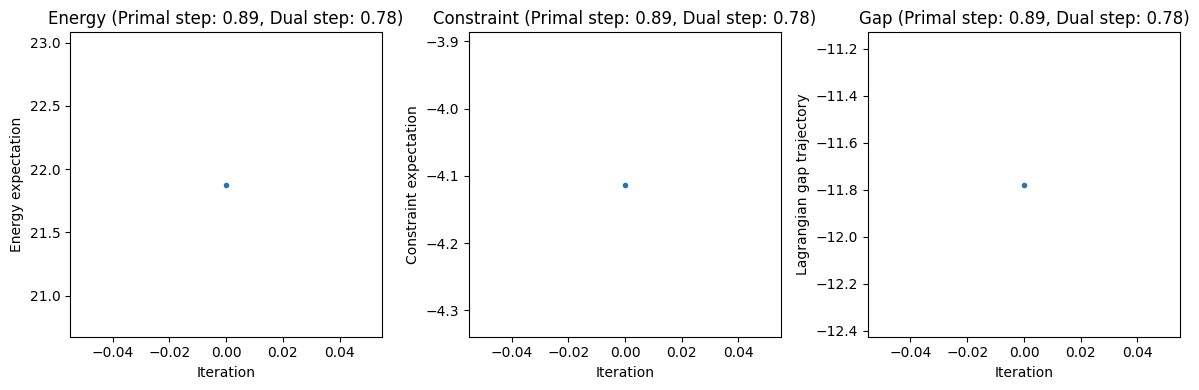

Sample 0: 100110110 with probability 0.0145 and energy 7.2599999999999945
Sample 1: 111110110 with probability 0.013 and energy 21.730000000000004
Sample 2: 100010010 with probability 0.0123 and energy 2.740000000000011
Sample 3: 100010101 with probability 0.0119 and energy -7.2600000000000104
Sample 4: 101111001 with probability 0.0107 and energy 29.369999999999997
Testing primal_perturb_step=0.89, dual_perturb_step=0.89


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


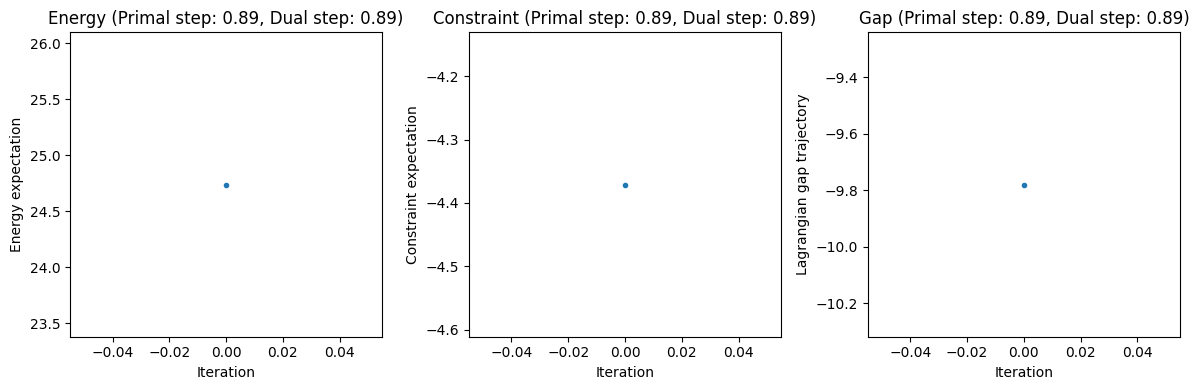

Sample 0: 000100010 with probability 0.0353 and energy 9.999999999999998
Sample 1: 000101110 with probability 0.0232 and energy 9.999999999999998
Sample 2: 000111110 with probability 0.021 and energy 7.105427357601002e-15
Sample 3: 000110010 with probability 0.0193 and energy -3.552713678800501e-15
Sample 4: 000101111 with probability 0.0142 and energy 9.999999999999996
Testing primal_perturb_step=0.89, dual_perturb_step=1.0


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


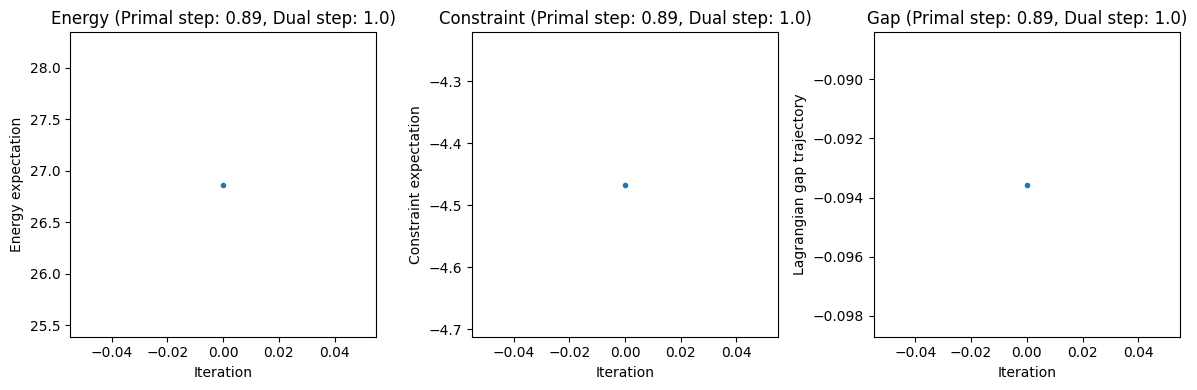

Sample 0: 101100001 with probability 0.055 and energy 24.85
Sample 1: 101011001 with probability 0.0358 and energy 43.89
Sample 2: 101010001 with probability 0.0259 and energy 24.85000000000001
Sample 3: 101100010 with probability 0.0237 and energy -4.629999999999987
Sample 4: 101001100 with probability 0.0219 and energy 44.11
Testing primal_perturb_step=1.0, dual_perturb_step=0.01


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


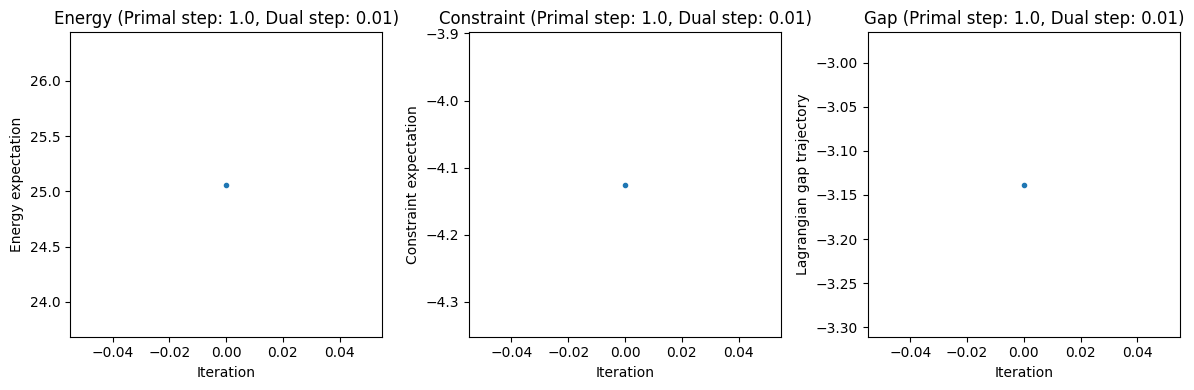

Sample 0: 110101001 with probability 0.0483 and energy 0.020000000000010232
Sample 1: 110011110 with probability 0.0257 and energy -4.539999999999999
Sample 2: 110111110 with probability 0.0214 and energy -14.54
Sample 3: 110100110 with probability 0.0193 and energy 0.02000000000000135
Sample 4: 110100000 with probability 0.0173 and energy 39.14
Testing primal_perturb_step=1.0, dual_perturb_step=0.12


  0%|          | 1/200 [00:02<08:02,  2.42s/it]

Gap closed after 2 iterations; VQEC converged.


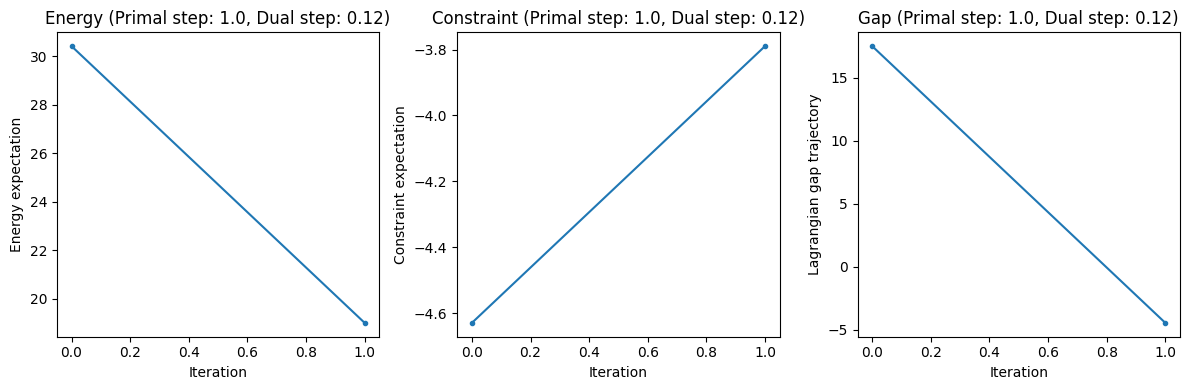

Sample 0: 101011101 with probability 0.0159 and energy 24.85
Sample 1: 001111011 with probability 0.0156 and energy 7.370000000000001
Sample 2: 101111011 with probability 0.0153 and energy 29.150000000000002
Sample 3: 101101011 with probability 0.0138 and energy 0.10999999999999766
Sample 4: 101001011 with probability 0.0132 and energy 29.14999999999999
Testing primal_perturb_step=1.0, dual_perturb_step=0.23


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


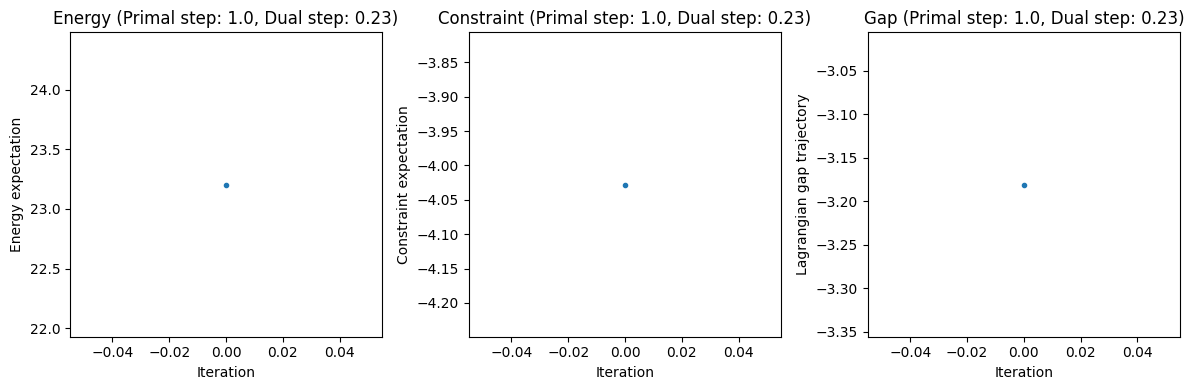

Sample 0: 111101000 with probability 0.0295 and energy 51.43000000000001
Sample 1: 100010110 with probability 0.0282 and energy 21.779999999999987
Sample 2: 111101011 with probability 0.0254 and energy -7.169999999999997
Sample 3: 111011110 with probability 0.0242 and energy -11.909999999999998
Sample 4: 100101000 with probability 0.0184 and energy -7.259999999999996
Testing primal_perturb_step=1.0, dual_perturb_step=0.34


  1%|          | 2/200 [00:03<06:08,  1.86s/it]

Gap closed after 3 iterations; VQEC converged.


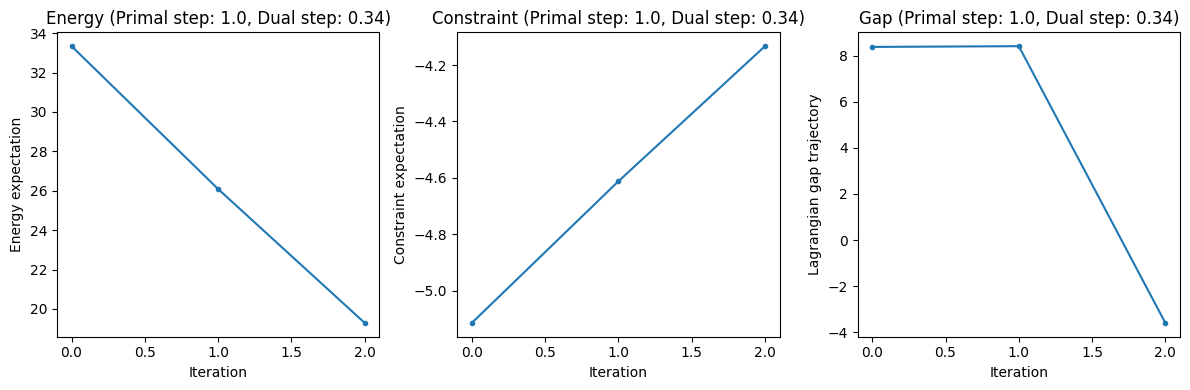

Sample 0: 000011011 with probability 0.0303 and energy -5.773159728050814e-15
Sample 1: 000011100 with probability 0.03 and energy 9.999999999999991
Sample 2: 000000010 with probability 0.0272 and energy -5.329070518200751e-15
Sample 3: 110011100 with probability 0.0241 and energy 39.13999999999999
Sample 4: 000001001 with probability 0.0227 and energy 9.999999999999996
Testing primal_perturb_step=1.0, dual_perturb_step=0.45


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


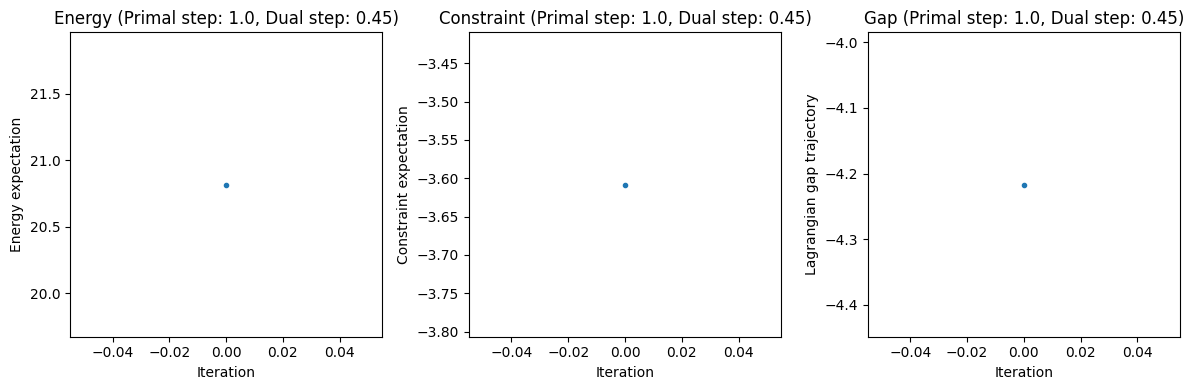

Sample 0: 110001001 with probability 0.0242 and energy -19.059999999999995
Sample 1: 101101000 with probability 0.0221 and energy 29.59
Sample 2: 101101010 with probability 0.0198 and energy 14.41
Sample 3: 110110010 with probability 0.0167 and energy 14.49999999999999
Sample 4: 110010010 with probability 0.0149 and energy -4.539999999999997
Testing primal_perturb_step=1.0, dual_perturb_step=0.56


  0%|          | 1/200 [00:02<07:23,  2.23s/it]

Gap closed after 2 iterations; VQEC converged.


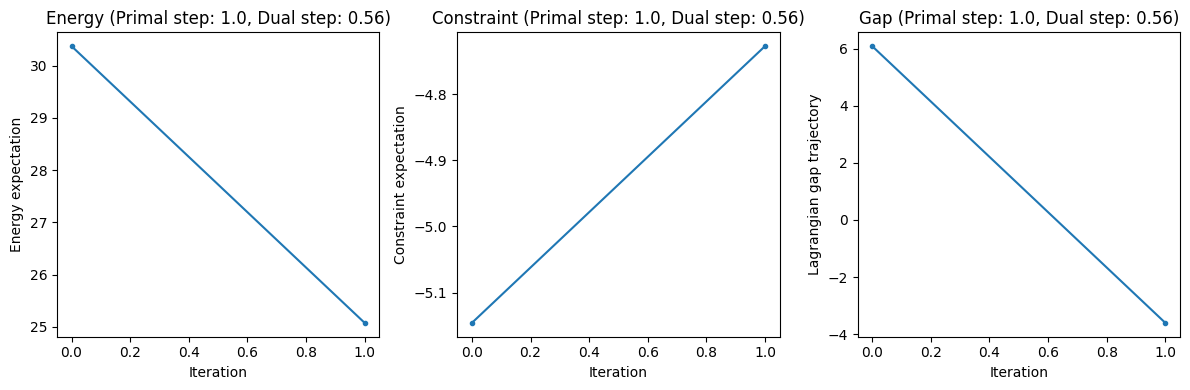

Sample 0: 110100011 with probability 0.0216 and energy 10.020000000000001
Sample 1: 110100001 with probability 0.0189 and energy 24.58
Sample 2: 101100011 with probability 0.0174 and energy 10.110000000000005
Sample 3: 111000001 with probability 0.0171 and energy 123.97
Sample 4: 101110001 with probability 0.0163 and energy 14.850000000000005
Testing primal_perturb_step=1.0, dual_perturb_step=0.67


  1%|          | 2/200 [00:03<06:06,  1.85s/it]

Gap closed after 3 iterations; VQEC converged.


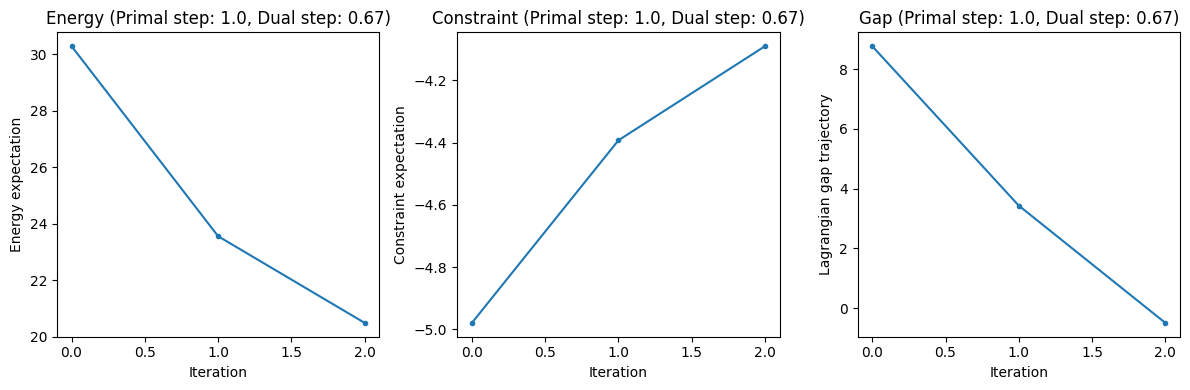

Sample 0: 101001101 with probability 0.0274 and energy 14.850000000000001
Sample 1: 101001111 with probability 0.0245 and energy 43.67000000000001
Sample 2: 101011011 with probability 0.0232 and energy 0.10999999999999943
Sample 3: 100011011 with probability 0.0198 and energy -7.260000000000005
Sample 4: 101000110 with probability 0.0197 and energy -19.150000000000006
Testing primal_perturb_step=1.0, dual_perturb_step=0.78


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


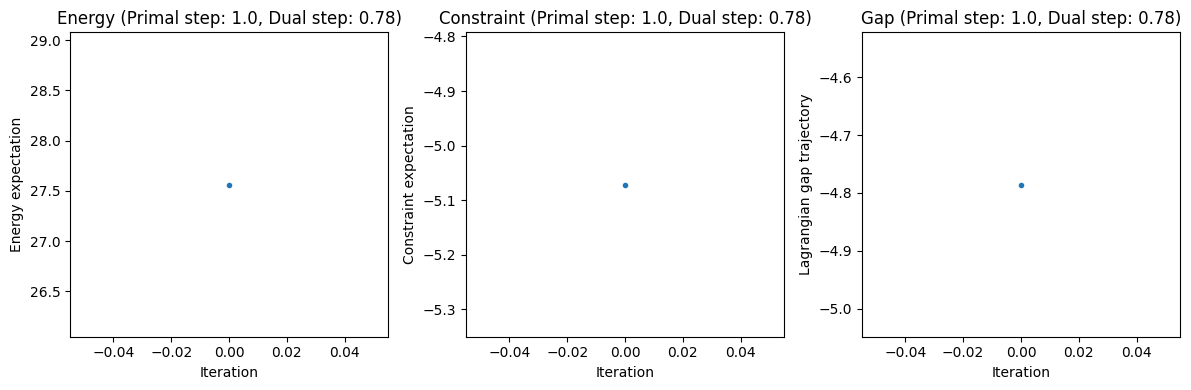

Sample 0: 101011100 with probability 0.0246 and energy 39.58999999999999
Sample 1: 101001111 with probability 0.0173 and energy 43.67000000000001
Sample 2: 101011111 with probability 0.0154 and energy 10.110000000000001
Sample 3: 011111010 with probability 0.0145 and energy -14.650000000000006
Sample 4: 101001100 with probability 0.0135 and energy 44.11
Testing primal_perturb_step=1.0, dual_perturb_step=0.89


  2%|▏         | 4/200 [00:05<04:47,  1.47s/it]

Gap closed after 5 iterations; VQEC converged.


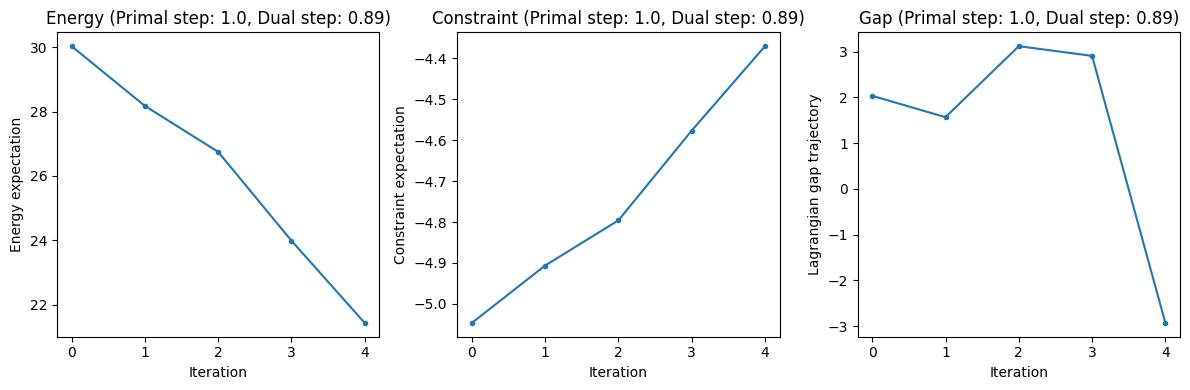

Sample 0: 110100010 with probability 0.0192 and energy -4.540000000000003
Sample 1: 110110000 with probability 0.0157 and energy -19.05999999999999
Sample 2: 000011111 with probability 0.0143 and energy 9.999999999999996
Sample 3: 110100000 with probability 0.0132 and energy 39.14
Sample 4: 110101010 with probability 0.0125 and energy 29.059999999999995
Testing primal_perturb_step=1.0, dual_perturb_step=1.0


  0%|          | 0/200 [00:01<?, ?it/s]

Gap closed after 1 iterations; VQEC converged.


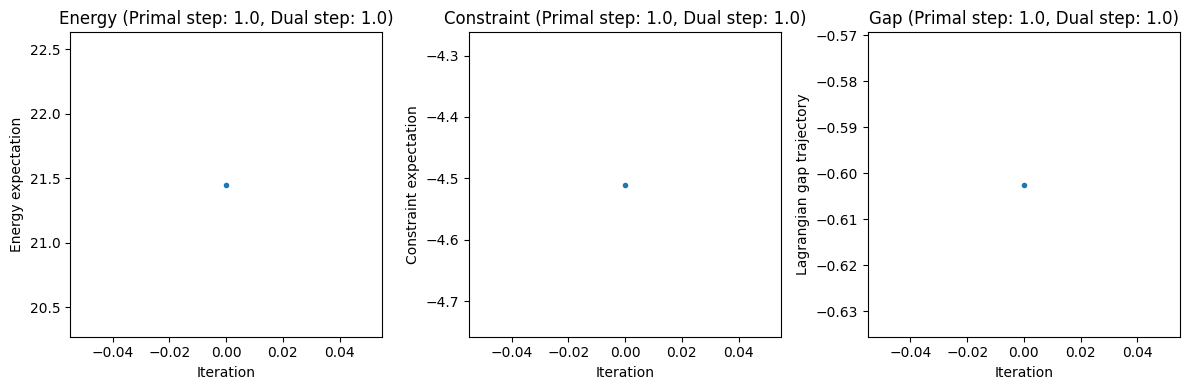

Sample 0: 001001011 with probability 0.0528 and energy 7.370000000000001
Sample 1: 010110011 with probability 0.0319 and energy -7.280000000000004
Sample 2: 101001011 with probability 0.03 and energy 29.14999999999999
Sample 3: 001001100 with probability 0.0279 and energy 36.85
Sample 4: 001001010 with probability 0.0235 and energy -7.370000000000001
Successful perturbation parameters:
Primal Perturb Step: 0.01, Dual Perturb Step: 0.23
Primal Perturb Step: 0.01, Dual Perturb Step: 0.78
Primal Perturb Step: 0.12, Dual Perturb Step: 0.67


In [10]:
# Range of perturbation parameters to test
primal_perturb_range = np.linspace(0.01, 1, 10)  # Example range for primal perturbation steps
dual_perturb_range = np.linspace(0.01, 1, 10)    # Example range for dual perturbation steps

successful_parameters = []

for primal_perturb_step in primal_perturb_range:
    for dual_perturb_step in dual_perturb_range:
        print(f"Testing primal_perturb_step={primal_perturb_step}, dual_perturb_step={dual_perturb_step}")

        # Run VQEC optimization with current perturbation parameters
        vqec_lincomb = VQECOpt(
            primal_perturb_step=primal_perturb_step,
            dual_perturb_step=dual_perturb_step,
            qubit_op=qubit_op,
            constr_ops=olap_constr_ops,
            ansatz=ansatz_su2,
            estimator=estimator,
            gradient=gradient_lincomb,
            max_iter=200
        )
        vqec_lincomb_result = vqec_lincomb.optimize_primal_dual()

        # Plot the results for energy, constraints, and lagrangian gap
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

        # Energy plot
        ax[0].plot(vqec_lincomb_result.energies, label="Energy", marker=".")
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel("Energy expectation")
        ax[0].set_title(f"Energy (Primal step: {primal_perturb_step}, Dual step: {dual_perturb_step})")

        # Constraint plot
        ax[1].plot(vqec_lincomb_result.constraints[:, 0], label="Overlap", marker=".")
        ax[1].set_xlabel("Iteration")
        ax[1].set_ylabel("Constraint expectation")
        ax[1].set_title(f"Constraint (Primal step: {primal_perturb_step}, Dual step: {dual_perturb_step})")

        # Lagrangian gap plot
        ax[2].plot(vqec_lincomb_result.lagrangian_gap_trajectory, label="Dual", marker=".")
        ax[2].set_xlabel("Iteration")
        ax[2].set_ylabel("Lagrangian gap trajectory")
        ax[2].set_title(f"Gap (Primal step: {primal_perturb_step}, Dual step: {dual_perturb_step})")

        plt.tight_layout()
        plt.show()

        # Copy and measure the full circuit
        full_circ = vqec_lincomb_result.ansatz.copy()
        full_circ.measure_all()
        sampler = Sampler(options={"shots": 10000})
        sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_lincomb_result.optimal_primal_vars).result()

        # Extract probabilities and sort
        quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()
        sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))

        # Compute the energies of the top 5 samples and check for "111111110"
        from qufold.execution_utils.measurements import _evaluate_sparsepauli
        bitstring_energies = {}
        found_solution = False

        for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
            if i >= 5:
                break
            energy = _evaluate_sparsepauli(sample, qubit_op)
            bitstring_energies[sample] = energy
            print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")
            
            # Check if "111111110" appears in the top 5 with energy -21.9
            if sample == "111111110" and np.isclose(energy, -21.9, atol=0.1):
                print(f"Found '111111110' with energy -21.9 and probability {prob}")
                found_solution = True
                break

        # If found, record the perturbation parameters
        if found_solution:
            successful_parameters.append((primal_perturb_step, dual_perturb_step))

# Output the successful parameters
print("Successful perturbation parameters:")
for params in successful_parameters:
    print(f"Primal Perturb Step: {params[0]}, Dual Perturb Step: {params[1]}")


In [45]:
# Optimal solution for LFLF
print(_evaluate_sparsepauli("111111110", qubit_op))

print(_evaluate_sparsepauli("001001110", qubit_op))

-21.909999999999993
-7.36999999999999


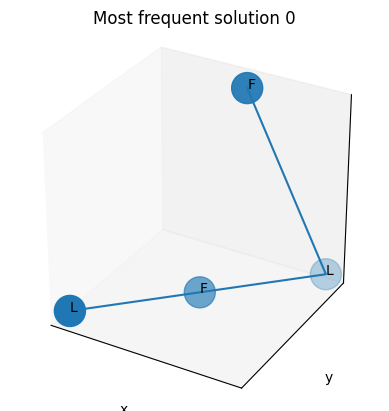

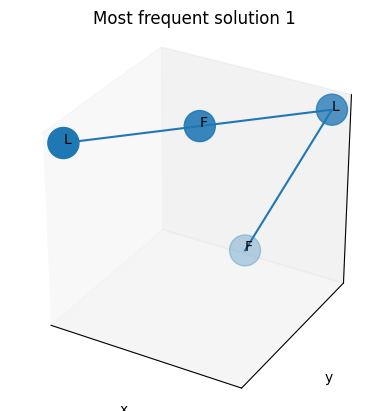

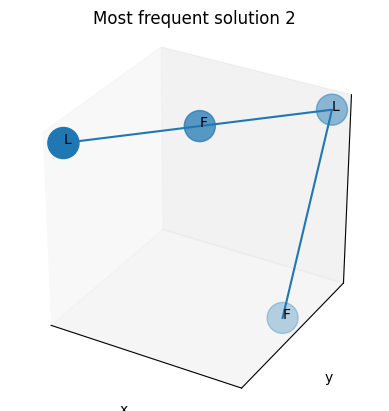

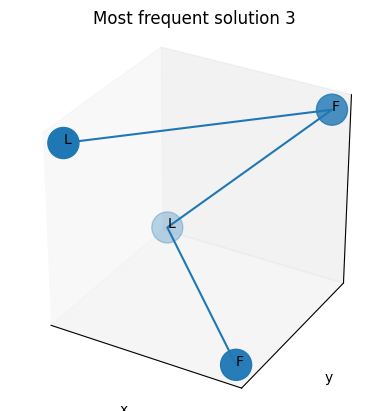

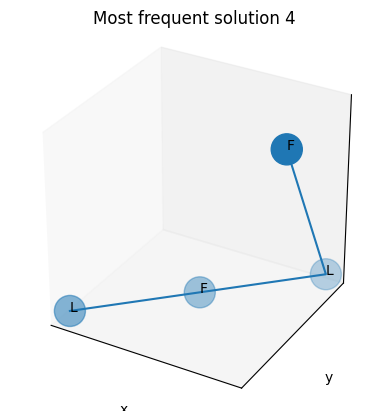

In [30]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

In [11]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    print(f"Turn sequence: {pf_result.turn_sequence}")
    xyz_coords = pf_result.protein_shape_file_gen.get_xyz_data()
    print(xyz_coords)
    distances = []
    xyz_coords = xyz_coords[:, 1::]
    # Convert the coordinates to float
    xyz_coords = xyz_coords.astype(float)
    for i in range(len(xyz_coords)):
        for j in range(i + 2, len(xyz_coords)):
            distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
            distances.append(distance)
    print(distances)

Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0,

In [12]:
test_op = SparsePauliOp.from_list([("ZII", 1)])
print(test_op)
print(_evaluate_sparsepauli("000", test_op))
print(_evaluate_sparsepauli("001", test_op))
print(_evaluate_sparsepauli("100", test_op))

SparsePauliOp(['ZII'],
              coeffs=[1.+0.j])
1.0
1.0
-1.0


## Checking qubit_op

In [13]:
from fcc.fcc_qubit_op_builder import QubitOpBuilder
from fcc.fcc_distance_map import DistanceMap
from fcc.utils import remove_unused_qubits

In [14]:
main_seq_4

'LFLF'

In [15]:
peptide = Peptide(main_seq_4)
mj_interaction = MiyazawaJerniganInteraction("mj_matrix")
pair_energies = mj_interaction.calculate_energy_matrix(main_seq_4)
penalty_params = PenaltyParameters(50, 50)

qubit_op_builder = QubitOpBuilder(peptide, pair_energies, penalty_params)

In [16]:
contact_op = qubit_op_builder._create_h_contact()
print(contact_op.num_qubits)

# "001001110" -> full bitstring: "001001100100000"
print(_evaluate_sparsepauli("001001100100000", contact_op))

full_qubit_op = qubit_op_builder.build_qubit_op()
print(full_qubit_op.num_qubits)
print(_evaluate_sparsepauli("001001100100000", full_qubit_op))

15
-7.369999999999994
15
-7.36999999999999


In [17]:
reduced_qubit_op, unused_qubits = remove_unused_qubits(full_qubit_op)
print(unused_qubits)
print(reduced_qubit_op.num_qubits)
print(_evaluate_sparsepauli("001001110", reduced_qubit_op))

[0, 1, 2, 3, 6, 7]
9
-7.36999999999999


In [18]:
DM = DistanceMap(peptide)
distance_map = DM.distance_map
distance_map

defaultdict(dict,
            {'0': {'1': SparsePauliOp(['IIIIIIIIIIII'],
                            coeffs=[2.+0.j]),
              '2': SparsePauliOp(['IIIIIIIIIIII', 'IIIIIIZIIIII', 'IIIIIIZZIIII'],
                            coeffs=[5.+0.j, 2.+0.j, 1.+0.j]),
              '3': SparsePauliOp(['IIIIIIIIIIII', 'IIIIIIZIIIII', 'IIZIIIIIIIII', 'ZIZIIIIIIIII', 'IZZIIIIIIIII', 'ZZZIIIIIIIII', 'IIIZIIIIIIII', 'ZIIZIIIIIIII', 'IZIZIIIIIIII', 'ZZIZIIIIIIII', 'IIZIIIZIIIII', 'ZIZIIIZIIIII', 'IZZIIIZIIIII', 'ZZZIIIZIIIII', 'IIIZIIZIIIII', 'ZIIZIIZIIIII', 'ZZIZIIZIIIII', 'ZIIIIIIIIIII', 'IZIIIIIIIIII', 'ZZIIIIIIIIII', 'IIZZIIIIIIII', 'ZIZZIIIIIIII', 'IZZZIIIIIIII', 'ZZZZIIIIIIII', 'IIIIIIZZIIII', 'ZIIIIIZZIIII', 'IZIIIIZZIIII', 'IIZIIIZZIIII', 'ZZZIIIZZIIII', 'IIIZIIZZIIII', 'ZZIZIIZZIIII', 'ZIZZIIZZIIII', 'IZZZIIZZIIII', 'IZZIIIIZIIII', 'IZIZIIIZIIII'],
                            coeffs=[ 6.5 +0.j,  2.  +0.j,  1.25+0.j,  0.5 +0.j,  0.5 +0.j, -0.25+0.j,
               -1.25+0.j,  0.5 +0.j,  

In [19]:
print(_evaluate_sparsepauli("001100100000", distance_map['0']['2']))
print(_evaluate_sparsepauli("001100100000", distance_map['0']['3']))
print(_evaluate_sparsepauli("001100100000", distance_map['1']['3']))

2.0
6.0
6.0


In [20]:
bead_idx = 3
print(_evaluate_sparsepauli("001100100000", DM._compute_x_coordinate(bead_idx)))
print(_evaluate_sparsepauli("001100100000", DM._compute_y_coordinate(bead_idx)))
print(_evaluate_sparsepauli("001100100000", DM._compute_z_coordinate(bead_idx)))

-1.0
2.0
-1.0


## Demo of a potential "issue"

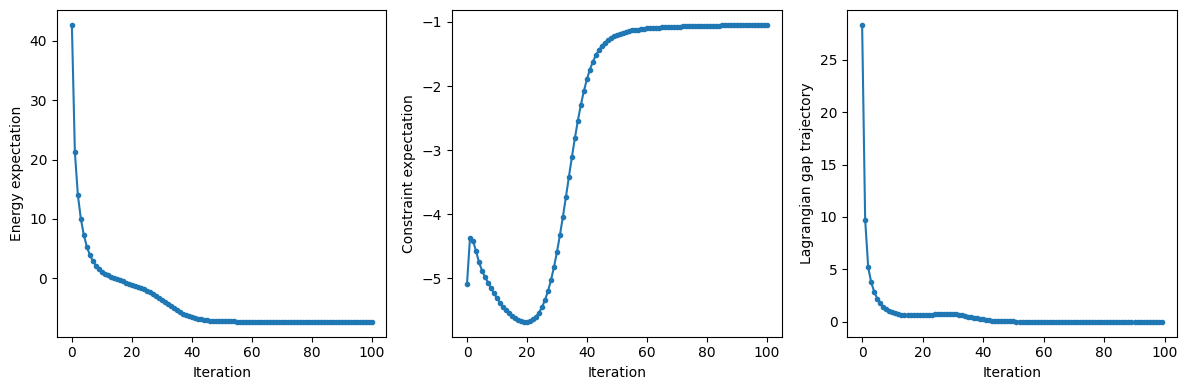

In [21]:
# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

ax[1].plot(vqec_result.constraints[:, 0], label="Overlap", marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

ax[2].plot(vqec_result.lagrangian_gap_trajectory, label="Dual", marker=".")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Lagrangian gap trajectory")



plt.tight_layout()
plt.show()

In [22]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

Sample 0: 001101010 with probability 0.515 and energy -7.3700000000000045
Sample 1: 001111010 with probability 0.469 and energy -7.369999999999996
Sample 2: 011101010 with probability 0.0072 and energy -0.09000000000000075
Sample 3: 011111010 with probability 0.0062 and energy -14.650000000000006
Sample 4: 000010101 with probability 0.0012 and energy -8.881784197001252e-15


C:\Users\8J6010897\AppData\Local\Temp\ipykernel_44376\2213236805.py:3: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Note that the second solution above seems to be a valid solution, but clearly, the interaction qubits are not consistent with the configuration qubits. For a given set of configuration qubits, the interaction qubits can be determined completely. 

How should we eliminate such inconsistent bitstrings?
- By postprocessing.
- Better yet, by eliminating them at the Hamiltonian level, which also reduces the search space. But how?

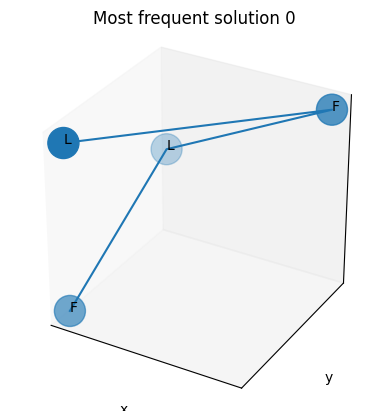

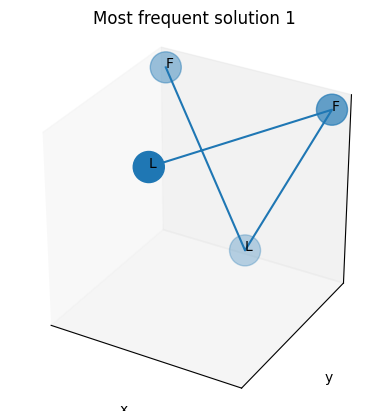

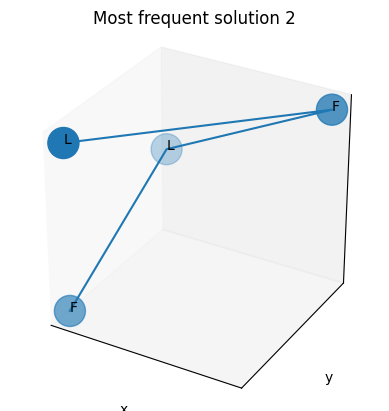

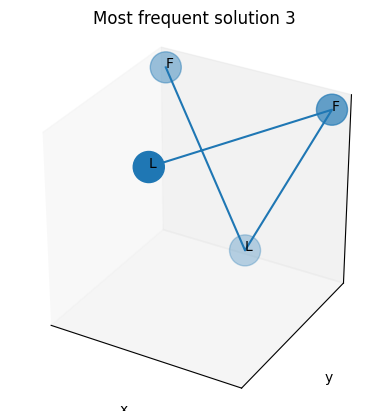

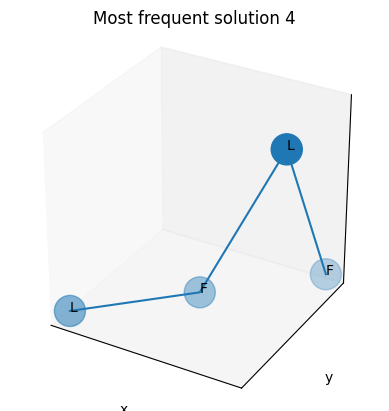

In [23]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()

In [24]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    print(f"Turn sequence: {pf_result.turn_sequence}")
    xyz_coords = pf_result.protein_shape_file_gen.get_xyz_data()
    print(xyz_coords)
    distances = []
    xyz_coords = xyz_coords[:, 1::]
    # Convert the coordinates to float
    xyz_coords = xyz_coords.astype(float)
    for i in range(len(xyz_coords)):
        for j in range(i + 2, len(xyz_coords)):
            distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
            distances.append(distance)
    print(distances)

Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0, 9, 5]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '0.0' '0.0' '-5.37401153701776']]
[1.9999999999999996, 4.0, 5.999999999999999]
Turn sequence: [0, 9, 11]
[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '-2.68700576850888' '2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 4.0]
Turn sequence: [0,